# Notebook 16 — Empirical GC and TDMI dependence structure

> **Contract.** This notebook identifies lagged dependence and history structure for the realised- and implied-variance dynamic equations using conditional Granger causality (GC), TDMI, and training-only history-order selection. RAW IV is a reproducibility benchmark; WEEKDAY_NORM IV is the authoritative primary specification. It is event-unaware: event dates remain in the sample but event indicators and weights are not included. Equation (1) is diagnosed compactly as an observation/distribution equation, without a separate return-mean lag-selection exercise. Linus explicitly instructed us to ignore Equation (5), so it is intentionally excluded from the empirical implementation.

GC is conditional linear predictive content, not structural causality. TDMI is pairwise lagged statistical dependence, not structural causality. History order, an individual distributed-lag coefficient, and a TDMI peak are different statistical objects. Empirical USDJPY data have no simulator-imposed timing, so synthetic +1 timing and prior 1-week-IV findings are not imposed.

## What this notebook does

N16 answers two distinct questions. **Question 1: how much history is required?** TRAIN-only BIC selects each target's history depth, with AIC retained as a secondary diagnostic. **Question 2: which source histories contain incremental predictive information?** Conditional block Granger tests apply the frozen TRAIN/VALIDATION rule. TDMI is a separate pairwise nonlinear delayed-dependence diagnostic.

| Object | Purpose | Selects structure? |
| --- | --- | --- |
| BIC | Select target history depth | Yes |
| Conditional GC | Test incremental linear predictive content of a source-history block | Yes |
| Partial R² | Measure incremental block effect size | Interpretation only |
| HAC Wald | Robustness to residual dependence and heteroskedasticity | No |
| Individual-lag t statistics | Locate fitted signal within a history block | No |
| TDMI | Pairwise nonlinear delayed dependence | Supporting diagnostic |
| TEST | Frozen-specification diagnostic | No |

The final N17 hand-off uses only the authoritative WEEKDAY_NORM branch. No result in this notebook is interpreted as structural economic causality.


## 1. Variables, equations, and units

The candidate realised-variance equation is

$$
\widetilde{\sigma}_t^2
=
c+
\sum_{j=1}^{n}
\left[
a_j\widetilde{\sigma}_{t-j}^2
+
b_jr_{t-j}^2
+
g_j\sigma_{t-j}^2
\right]
+
u_t^R.
$$

The corresponding implied-variance equation is

$$
\sigma_t^2
=
c+
\sum_{j=1}^{m}
\left[
a_j\sigma_{t-j}^2
+
b_jr_{t-j}^2
+
g_j\widetilde{\sigma}_{t-j}^2
\right]
+
u_t^I.
$$

`rv_within` is the complete-model-day sum of squared hourly log returns. The primary realised state annualises that variance by 252; annualised realised volatility is its square root, rather than 252 times daily volatility. `iv_ann_var` is the Bloomberg volatility quote converted to annualised variance. The 252 convention is solely the realised-variance business-time convention.

`within_session_log_return` is the complete-session log return, while `squared_return` is its square. They are not substitutes for realised variance: offsetting intraday moves can leave a small net return but substantial realised variation. All three primary states remain in levels, without log transforms, differencing, winsorisation, standardisation, or silent removal of economically large observations.

## 2. Observable implied variance and chronological discipline

Linus explicitly instructed us to ignore Equation (5) for the empirical implementation. It is therefore intentionally excluded, rather than an unresolved omission. The observed rolling Bloomberg USDJPY overnight/1D ATM implied-variance state is the empirical observable predictor; no volatility-surface interpolation or reconstruction of a conditional forward-implied-variance object is attempted.

The full model-day calendar is split chronologically at the frozen model-day boundaries before any missing-value filtering: TRAIN is 2003-05-05 to 2017-03-27, VALIDATION is 2017-03-28 to 2021-11-12, and TEST is 2021-11-15 to 2026-07-02. Training selects diagnostics, orders, bins, and TDMI peaks; validation evaluates frozen training choices; test evaluates the already frozen specification and never changes orders, transformations, peaks, or retained-driver flags.

The final TDMI inference convention is

$$
I(X_{t-k};Y_t), \qquad k=1,\ldots,20.
$$

X is the named source and Y the named target, so positive k means the source precedes the target. The opposite direction swaps source and target. This direct form keeps target split membership explicit and avoids boundary leakage; Friday-to-Monday remains one model-day lag, and lags are built on the complete calendar before validity masks.

In [62]:

from pathlib import Path
import math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.multitest import multipletests
from IPython.display import display, Markdown

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "Data"
PROCESSED_DIR = DATA_DIR / "processed"
INPUT_PATH = PROCESSED_DIR / "usdjpy_daily_model_panel.csv"
RUN_ID = pd.Timestamp.now(tz="UTC").isoformat()
MAX_LAG, ALPHA, MIN_STATIONARITY_BLOCK = 20, .05, 252
TDMI_SURROGATES, RANDOM_SEED, PRIMARY_BINS = 1000, 16017, 10
STATES = ["squared_return","realised_variance_ann_252","implied_variance_ann"]
if not INPUT_PATH.exists():
    raise FileNotFoundError(f"Required Notebook 15 export missing: {INPUT_PATH}")

panel=pd.read_csv(INPUT_PATH,parse_dates=["model_day"]).sort_values("model_day").reset_index(drop=True)
assert panel.model_day.is_monotonic_increasing and panel.model_day.is_unique
assert {"rv_eligible","rv_within","iv_ann_var","iv_model_var","iv_weekday_norm_var","within_session_log_return","rv_with_closure_gap"}.issubset(panel.columns)
assert panel["iv_model_var"].notna().eq(panel["iv_weekday_norm_var"].notna()).all()
assert np.allclose(panel.loc[panel["iv_model_var"].notna(), "iv_model_var"], panel.loc[panel["iv_model_var"].notna(), "iv_weekday_norm_var"])
assert panel["iv_ann_var"].notna().eq(panel["iv_model_var"].notna()).all()
assert not np.allclose(panel.loc[panel["iv_ann_var"].notna(), "iv_ann_var"], panel.loc[panel["iv_ann_var"].notna(), "iv_model_var"])
panel["squared_return"]=panel.within_session_log_return**2
panel["realised_variance_ann_252"]=252.0*panel.rv_within
panel["implied_variance_ann"]=panel.iv_ann_var
panel["realised_variance_with_closure_ann_252"]=252.0*panel.rv_with_closure_gap
panel["structure_eligible"]=panel.rv_eligible.fillna(False).astype(bool)&np.isfinite(panel[STATES]).all(axis=1)
assert np.isfinite(panel.loc[panel.structure_eligible,STATES].to_numpy(float)).all()
assert np.allclose(panel.loc[panel.rv_within.notna(),"realised_variance_ann_252"],252*panel.loc[panel.rv_within.notna(),"rv_within"])
assert np.allclose(panel.loc[panel.iv_ann_var.notna(),"implied_variance_ann"],panel.loc[panel.iv_ann_var.notna(),"iv_ann_var"])
assert np.allclose(panel.loc[panel.within_session_log_return.notna(),"squared_return"],panel.loc[panel.within_session_log_return.notna(),"within_session_log_return"]**2)

SPLIT_DATES={"train":(pd.Timestamp("2003-05-05"),pd.Timestamp("2017-03-27")),"validation":(pd.Timestamp("2017-03-28"),pd.Timestamp("2021-11-12")),"test":(pd.Timestamp("2021-11-15"),pd.Timestamp("2026-07-02"))}
split_conditions=[panel.model_day.between(start,end) for start,end in SPLIT_DATES.values()]
panel["sample_split"]=np.select(split_conditions,list(SPLIT_DATES),default="outside_frozen_sample")
assert not panel.sample_split.eq("outside_frozen_sample").any(), "Canonical N16 panel must be fully covered by the frozen date split."
assert panel.loc[panel.sample_split.eq("train"),"model_day"].agg(["min","max"]).tolist()==list(SPLIT_DATES["train"])
assert panel.loc[panel.sample_split.eq("validation"),"model_day"].agg(["min","max"]).tolist()==list(SPLIT_DATES["validation"])
assert panel.loc[panel.sample_split.eq("test"),"model_day"].agg(["min","max"]).tolist()==list(SPLIT_DATES["test"])
train_end=int(panel.sample_split.eq("train").sum());validation_end=train_end+int(panel.sample_split.eq("validation").sum())
for state in STATES+["realised_variance_with_closure_ann_252"]:
    for lag in range(1,MAX_LAG+1):panel[f"{state}_lag{lag}"]=panel[state].shift(lag)
assert MAX_LAG==20 and pd.isna(panel.loc[0,"squared_return_lag1"])
assert panel.loc[1,"squared_return_lag1"]==panel.loc[0,"squared_return"]
assert not any("event" in x.lower() or "forecast" in x.lower() for x in STATES)

coverage=(panel.groupby("sample_split",sort=False).agg(calendar_rows=("model_day","size"),calendar_start=("model_day","min"),calendar_end=("model_day","max"),eligible_rows=("structure_eligible","sum")).reset_index())
eligible_range=(panel.loc[panel.structure_eligible].groupby("sample_split",sort=False).agg(first_eligible_model_day=("model_day","min"),last_eligible_model_day=("model_day","max")).reset_index())
coverage=coverage.merge(eligible_range,on="sample_split",how="left")
definitions=pd.DataFrame([
["squared_return","within_session_log_return squared","dimensionless complete-session squared return"],
["realised_variance_ann_252","252 times rv_within","annualised variance; 252-model-day business-time convention"],
["implied_variance_ann","iv_ann_var","Bloomberg annualised implied variance = (quote/100) squared"]],columns=["variable","construction","units"])
display(coverage);display(definitions)

def lagcols(state,p):return [f"{state}_lag{j}" for j in range(1,p+1)]
def required_gc_columns(target,p,states_=STATES):
    # The regression needs current target plus lagged regressors only: never unrelated current predictors.
    return list(dict.fromkeys([target]+sum((lagcols(s,p) for s in states_),[])))
def gc_valid_rows(frame,target,p,split,states_=STATES):
    required_columns=required_gc_columns(target,p,states_)
    mask=frame.sample_split.eq(split)&np.isfinite(frame[required_columns]).all(axis=1)
    assert not frame.loc[mask,required_columns].isna().any().any()
    return frame.loc[mask,required_columns].copy()
def rows_for(frame,target,p,split,states_=STATES,flag=None):
    # Compatibility wrapper; flag is intentionally ignored so structure_eligible cannot enter GC sampling.
    return gc_valid_rows(frame,target,p,split,states_)
def design(rows,target,p,states_=STATES):
    names=sum((lagcols(s,p) for s in states_),[])
    return rows[target].to_numpy(float),sm.add_constant(rows[names].to_numpy(float),has_constant="add"),["const"]+names
def holm(frame):
    out=frame.copy();out["holm_adjusted_p_value"]=np.nan;out["holm_reject"]=False;mask=out.raw_p_value.notna()
    if mask.any():
        reject,padj,_,_=multipletests(out.loc[mask,"raw_p_value"],alpha=ALPHA,method="holm")
        out.loc[mask,"holm_adjusted_p_value"]=padj;out.loc[mask,"holm_reject"]=reject
    return out
def order_scan(frame,target):
    """Compare candidate target-history orders on common lag-20 TRAIN support."""
    common_rows=rows_for(frame,target,MAX_LAG,"train")
    order_rows=[]
    for candidate_order in range(1,MAX_LAG+1):
        response,design_matrix,parameter_names=design(common_rows,target,candidate_order)
        fitted_model=sm.OLS(response,design_matrix).fit()
        log_likelihood=float(fitted_model.llf)
        parameter_count=int(fitted_model.df_model+1)
        n_observations=len(common_rows)
        aic_manual=float(-2*log_likelihood+2*parameter_count)
        bic_manual=float(-2*log_likelihood+parameter_count*np.log(n_observations))
        assert np.isclose(fitted_model.aic,aic_manual,rtol=1e-12,atol=1e-9)
        assert np.isclose(fitted_model.bic,bic_manual,rtol=1e-12,atol=1e-9)
        order_rows.append({"target":target,"history_order":candidate_order,"AIC":float(fitted_model.aic),"BIC":float(fitted_model.bic),"BIC_manual":bic_manual,"RSS":float(fitted_model.ssr),"log_likelihood":log_likelihood,"adjusted_R2":float(fitted_model.rsquared_adj),"n_observations":n_observations,"n_parameters":parameter_count,"comparison_sample":"common_lag_20_training"})
    order_table=pd.DataFrame(order_rows)
    assert len(order_table)==MAX_LAG and order_table.n_observations.nunique()==1
    return order_table
def gc_test(frame,target,source,p,split,states_=STATES,flag="structure_eligible"):
    # Selected-order-specific rows: no unnecessary lag-20 requirement after BIC selection.
    valid_rows=gc_valid_rows(frame,target,p,split,states_)
    row_index=valid_rows.index.copy()
    response,unrestricted_design,predictor_names=design(valid_rows,target,p,states_)
    source_history_columns=lagcols(source,p)
    source_positions=[i for i,name in enumerate(predictor_names) if name in source_history_columns]
    restricted_positions=[i for i,name in enumerate(predictor_names) if name not in source_history_columns]
    restricted_design=unrestricted_design[:,restricted_positions]
    restricted_model=sm.OLS(response,restricted_design).fit()
    unrestricted_model=sm.OLS(response,unrestricted_design).fit()
    q=len(source_positions)
    df_unrestricted=float(unrestricted_model.df_resid)
    assert row_index.equals(valid_rows.index) and len(row_index)==len(response), "Restricted and unrestricted models must use identical rows."
    rss_restricted=float(restricted_model.ssr)
    rss_unrestricted=float(unrestricted_model.ssr)
    rss_reduction=rss_restricted-rss_unrestricted
    assert rss_reduction>=-1e-12*max(1.0,rss_restricted), "Nested unrestricted RSS cannot exceed restricted RSS."
    f_manual=max(0.0,(rss_reduction/q)/(rss_unrestricted/df_unrestricted))
    f_library,p_library,df_difference=unrestricted_model.compare_f_test(restricted_model)
    assert int(round(df_difference))==q and np.isclose(f_manual,f_library,rtol=1e-10,atol=1e-10), "Manual and statsmodels nested F tests disagree."
    p_value=float(stats.f.sf(f_manual,q,df_unrestricted))
    logsf=float(stats.f.logsf(f_manual,q,df_unrestricted))
    log10_p=float(logsf/np.log(10)) if np.isfinite(logsf) else np.nan
    assert np.isclose(p_value,float(p_library),rtol=1e-10,atol=np.finfo(float).tiny), "Survival-function p-value disagrees with statsmodels."
    partial_r2=float(rss_reduction/rss_restricted)
    partial_r2_identity=float((q*f_manual)/(q*f_manual+df_unrestricted))
    assert np.isclose(partial_r2,partial_r2_identity,rtol=1e-10,atol=1e-12), "Partial R2 identity failed."
    hac_lags=max(1,int(np.floor(4*(len(valid_rows)/100)**(2/9))))
    robust_unrestricted_model=unrestricted_model.get_robustcov_results(cov_type="HAC",maxlags=hac_lags)
    restriction_matrix=np.zeros((q,len(predictor_names)))
    restriction_matrix[np.arange(q),source_positions]=1
    hac_wald=robust_unrestricted_model.wald_test(restriction_matrix,scalar=True)
    restricted_predictors=[state for state in states_ if state!=source]
    result={
        "split":split,
        "target":target,
        "source":source,
        "history_order":p,
        "lag_order":p,
        "n_observations":len(valid_rows),
        "comparison_sample":"selected_order_specific",
        "same_row_index":True,
        "restricted_predictors":" + ".join(restricted_predictors)+" histories",
        "unrestricted_predictors":" + ".join(states_)+" histories",
        "restrictions_q":q,
        "unrestricted_parameter_count":int(unrestricted_model.df_model+1),
        "restricted_RSS":rss_restricted,
        "unrestricted_RSS":rss_unrestricted,
        "rss_restricted":rss_restricted,
        "rss_unrestricted":rss_unrestricted,
        "classical_F":float(f_manual),
        "F_manual":float(f_manual),
        "F_library":float(f_library),
        "raw_p_value":p_value,
        "p_value":p_value,
        "log10_p_value":log10_p,
        "p_underflow_flag":bool(p_value==0.0),
        "p_display":"p < machine precision" if p_value==0.0 else f"{p_value:.6g}",
        "partial_R2":partial_r2,
        "partial_R2_identity":partial_r2_identity,
        "log_variance_ratio":float(np.log(rss_restricted/rss_unrestricted)),
        "unrestricted_AIC":float(unrestricted_model.aic),
        "unrestricted_BIC":float(unrestricted_model.bic),
        "residual_df":df_unrestricted,
        "df_unrestricted":df_unrestricted,
        "restricted_rank":int(np.linalg.matrix_rank(restricted_design)),
        "unrestricted_rank":int(np.linalg.matrix_rank(unrestricted_design)),
        "restricted_condition_number":float(np.linalg.cond(restricted_design)),
        "unrestricted_condition_number":float(np.linalg.cond(unrestricted_design)),
        "unrestricted_residual_variance":float(unrestricted_model.mse_resid),
        "HAC_Wald_stat":float(np.asarray(hac_wald.statistic).squeeze()),
        "HAC_p":float(np.asarray(hac_wald.pvalue).squeeze()),
        "HAC_maxlags":hac_lags,
    }
    return result,unrestricted_model,predictor_names


,sample_split,calendar_rows,calendar_start,calendar_end,eligible_rows,first_eligible_model_day,last_eligible_model_day
0,train,3626,2003-05-05,2017-03-27,3053,2003-05-06,2017-03-27
1,validation,1209,2017-03-28,2021-11-12,1195,2017-03-28,2021-11-12
2,test,1209,2021-11-15,2026-07-02,1195,2021-11-15,2026-07-01


,variable,construction,units
0,squared_return,within_session_log_return squared,dimensionless complete-session squared return
1,realised_variance_ann_252,252 times rv_within,annualised variance; 252-model-day business-ti...
2,implied_variance_ann,iv_ann_var,Bloomberg annualised implied variance = (quote...


# Part A — Original RAW implied-variance benchmark

Stationarity means that statistical behaviour is sufficiently stable over time for ordinary level-regression inference to be interpretable. Unrelated trending series can otherwise appear predictively related.

ADF tests the unit-root null; KPSS tests the level-stationarity null. The tests are complementary, not duplicates. ADF rejection plus no KPSS rejection is stationarity-supported; ADF failure plus KPSS rejection is unit-root concern; strong ADF rejection plus KPSS rejection is non-unit-root but regime-instability, more consistent with level shifts, volatility regimes, or structural breaks than a simple random walk. Other combinations are mixed.

Stationarity is univariate. Each state uses its own longest contiguous finite training run on the intact model-day calendar, with other runs of at least 252 model days recorded. A concerning result triggers methodological review; it does not automatically transform the specified level system.

## 4. RAW AIC/BIC history selection and conditional GC

For implied variance leading realised variance, the unrestricted model is

$$
Y_t
=
c
+
\sum_{j=1}^{p}a_jY_{t-j}
+
\sum_{j=1}^{p}b_jr_{t-j}^2
+
\sum_{j=1}^{p}g_jI_{t-j}
+
u_t^R.
$$

The restricted model omits the implied-variance lag block. The null is that the full block is zero: implied-variance history adds no incremental linear predictive content once realised variance's own history and squared-return history are controlled for.

The classical nested statistic and partial R² are shown explicitly in the primary WEEKDAY_NORM derivation below. Partial R² is the fraction of restricted residual variation removed by the source block. Statistical significance and practical incremental explanatory content are distinct.

**GC sample availability is target-specific.** The realised-variance equation requires current realised variance and its included lagged histories of realised variance, squared return, and implied variance. It does not require current squared return or current implied variance, because neither is a contemporaneous regressor. The implied-variance equation follows the analogous rule. A strict common lag-20 target-specific sample is used only for fair BIC/AIC comparison; once BIC selects an order, inference refits on the maximal valid sample for that frozen order.

BIC is primary and AIC secondary. The candidate order is a history length, not a causal delay. Residual Ljung–Box diagnostics assess remaining serial dependence. Classical RSS F-tests remain primary; HAC/Newey–West Wald tests are an inference robustness check for the identical regression and restriction block.

,variable,run_role,run_start,run_end,n_observations,ADF_statistic,ADF_p_value,KPSS_statistic,KPSS_p_value,stationarity_interpretation
0,squared_return,longest,2006-10-31,2007-11-02,264,-2.496924,1.162246e-01,0.454316,0.053743,mixed
1,realised_variance_ann_252,longest,2006-10-31,2007-11-02,264,-5.668490,9.035642e-07,0.426952,0.065538,stationarity_supported
2,implied_variance_ann,longest,2008-01-02,2017-03-27,2409,-5.306841,5.299778e-06,1.664714,0.010000,non_unit_root_but_regime_instability


,variable,run_role,run_start,run_end,n_observations,ADF_statistic,ADF_p_value,KPSS_statistic,KPSS_p_value,stationarity_interpretation
0,squared_return,longest,2006-10-31,2007-11-02,264,-2.496924,1.162246e-01,0.454316,0.053743,mixed
1,squared_return,substantial,2005-11-01,2006-10-27,259,-16.542939,1.976323e-29,0.204500,0.100000,stationarity_supported
2,squared_return,substantial,2007-11-06,2008-10-31,259,2.447258,9.990308e-01,0.628830,0.020015,unit_root_concern
3,squared_return,substantial,2008-11-04,2009-10-30,259,-12.621346,1.575744e-23,1.290282,0.010000,non_unit_root_but_regime_instability
4,squared_return,substantial,2010-11-09,2011-11-04,259,-16.330484,3.064422e-29,0.052491,0.100000,stationarity_supported
5,realised_variance_ann_252,longest,2006-10-31,2007-11-02,264,-5.668490,9.035642e-07,0.426952,0.065538,stationarity_supported
6,realised_variance_ann_252,substantial,2005-11-01,2006-10-27,259,-5.773624,5.321538e-07,0.469268,0.048588,non_unit_root_but_regime_instability
7,realised_variance_ann_252,substantial,2007-11-06,2008-10-31,259,1.959879,9.986185e-01,0.689497,0.014500,unit_root_concern
8,realised_variance_ann_252,substantial,2008-11-04,2009-10-30,259,-5.269235,6.339024e-06,1.691520,0.010000,non_unit_root_but_regime_instability
9,realised_variance_ann_252,substantial,2010-11-09,2011-11-04,259,-13.322393,6.419905e-25,0.058354,0.100000,stationarity_supported


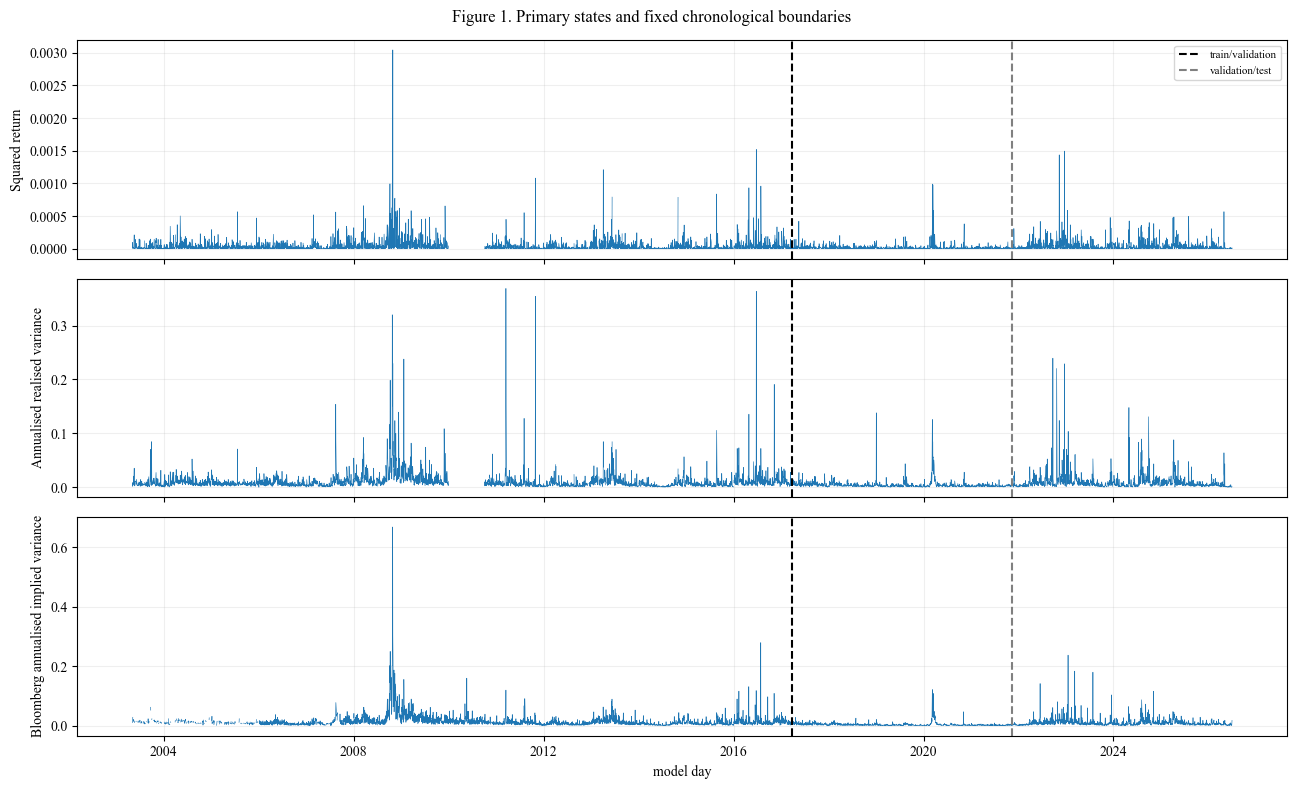

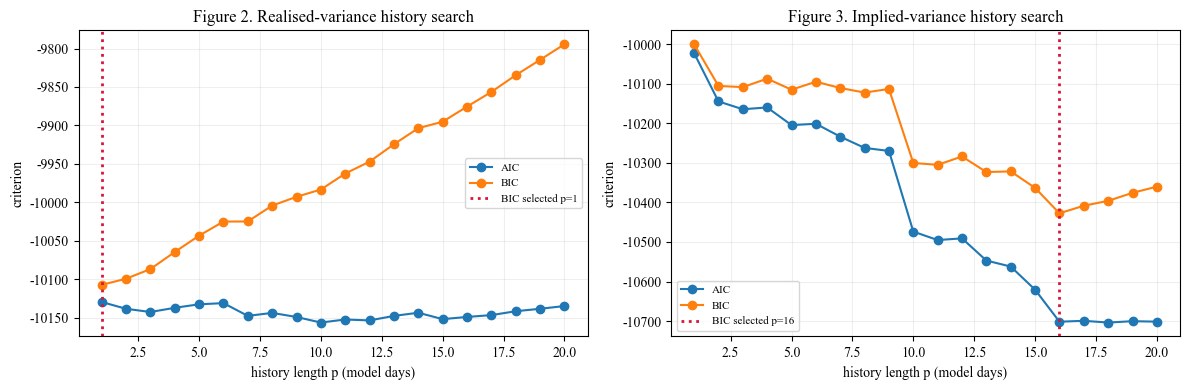

,target,history_order,AIC,BIC,BIC_manual,RSS,log_likelihood,adjusted_R2,n_observations,n_parameters,comparison_sample
0,realised_variance_ann_252,1,-10129.591749,-10107.268950,-10107.268950,0.650888,5068.795875,0.310335,1960,4,common_lag_20_training
1,realised_variance_ann_252,2,-10138.426383,-10099.361485,-10099.361485,0.645980,5076.213192,0.314484,1960,7,common_lag_20_training
2,realised_variance_ann_252,3,-10142.598585,-10086.791587,-10086.791587,0.642636,5081.299292,0.316983,1960,10,common_lag_20_training
3,realised_variance_ann_252,4,-10137.139577,-10064.590481,-10064.590481,0.642459,5081.569789,0.316120,1960,13,common_lag_20_training
4,realised_variance_ann_252,5,-10132.598101,-10043.306905,-10043.306905,0.641981,5082.299050,0.315574,1960,16,common_lag_20_training
5,realised_variance_ann_252,6,-10131.055366,-10025.022071,-10025.022071,0.640523,5084.527683,0.316073,1960,19,common_lag_20_training
6,realised_variance_ann_252,7,-10147.646326,-10024.870931,-10024.870931,0.633182,5095.823163,0.322864,1960,22,common_lag_20_training
7,realised_variance_ann_252,8,-10143.768349,-10004.250855,-10004.250855,0.632497,5096.884175,0.322548,1960,25,common_lag_20_training
8,realised_variance_ann_252,9,-10149.080705,-9992.821112,-9992.821112,0.628857,5102.540353,0.325401,1960,28,common_lag_20_training
9,realised_variance_ann_252,10,-10156.329576,-9983.327883,-9983.327883,0.624621,5109.164788,0.328904,1960,31,common_lag_20_training


C:\Users\Rajiv Nawal\AppData\Local\Temp\ipykernel_35052\177427029.py:51: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gcblocks=pd.DataFrame(gc_rows).groupby("split",group_keys=False).apply(holm).reset_index(drop=True)
C:\Users\Rajiv Nawal\AppData\Local\Temp\ipykernel_35052\177427029.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ownblocks=pd.DataFrame(own_rows).groupby("split",group_keys=False).apply(holm).res

,split,target,source,history_order,lag_order,n_observations,comparison_sample,same_row_index,restricted_predictors,unrestricted_predictors,...,unrestricted_condition_number,unrestricted_residual_variance,HAC_Wald_stat,HAC_p,HAC_maxlags,edge_id,holm_adjusted_p_value,holm_reject,HAC_support,retained_for_notebook17
0,train,realised_variance_ann_252,squared_return,1,1,3005,selected_order_specific,True,realised_variance_ann_252 + implied_variance_a...,squared_return + realised_variance_ann_252 + i...,...,12136.385634,0.000259,2.435139,1.187489e-01,8,squared_return_to_realised_variance,1.108631e-02,True,False,True
1,train,realised_variance_ann_252,implied_variance_ann,1,1,3005,selected_order_specific,True,squared_return + realised_variance_ann_252 his...,squared_return + realised_variance_ann_252 + i...,...,12136.385634,0.000259,72.927993,2.104530e-17,8,implied_variance_to_realised_variance,8.283738e-152,True,True,True
2,train,implied_variance_ann,squared_return,16,16,2099,selected_order_specific,True,realised_variance_ann_252 + implied_variance_a...,squared_return + realised_variance_ann_252 + i...,...,15533.845925,0.000251,0.921956,5.431224e-01,7,squared_return_to_implied_variance,5.872181e-18,True,False,True
3,train,implied_variance_ann,realised_variance_ann_252,16,16,2099,selected_order_specific,True,squared_return + implied_variance_ann histories,squared_return + realised_variance_ann_252 + i...,...,15533.845925,0.000251,0.631798,8.603765e-01,7,realised_variance_to_implied_variance,5.104989e-10,True,False,True
4,validation,realised_variance_ann_252,squared_return,1,1,1181,selected_order_specific,True,realised_variance_ann_252 + implied_variance_a...,squared_return + realised_variance_ann_252 + i...,...,22523.625121,0.000040,1.419185,2.337777e-01,6,squared_return_to_realised_variance,1.707928e-03,True,False,True
5,validation,realised_variance_ann_252,implied_variance_ann,1,1,1181,selected_order_specific,True,squared_return + realised_variance_ann_252 his...,squared_return + realised_variance_ann_252 + i...,...,22523.625121,0.000040,39.835096,3.906111e-10,6,implied_variance_to_realised_variance,1.069682e-38,True,True,True
6,validation,implied_variance_ann,squared_return,16,16,1055,selected_order_specific,True,realised_variance_ann_252 + implied_variance_a...,squared_return + realised_variance_ann_252 + i...,...,48347.084034,0.000018,3.979804,2.246580e-07,6,squared_return_to_implied_variance,8.228241e-08,True,True,True
7,validation,implied_variance_ann,realised_variance_ann_252,16,16,1055,selected_order_specific,True,squared_return + implied_variance_ann histories,squared_return + realised_variance_ann_252 + i...,...,48347.084034,0.000018,3.238344,1.662809e-05,6,realised_variance_to_implied_variance,1.030720e-04,True,True,True
8,test,realised_variance_ann_252,squared_return,1,1,1182,selected_order_specific,True,realised_variance_ann_252 + implied_variance_a...,squared_return + realised_variance_ann_252 + i...,...,13918.012917,0.000223,1.286739,2.568805e-01,6,squared_return_to_realised_variance,1.761403e-01,False,False,True
9,test,realised_variance_ann_252,implied_variance_ann,1,1,1182,selected_order_specific,True,squared_return + realised_variance_ann_252 his...,squared_return + realised_variance_ann_252 + i...,...,13918.012917,0.000223,38.658455,6.996668e-10,6,implied_variance_to_realised_variance,8.419159e-53,True,True,True


### Own-history persistence

,split,target,source,history_order,lag_order,n_observations,comparison_sample,same_row_index,restricted_predictors,unrestricted_predictors,...,restricted_condition_number,unrestricted_condition_number,unrestricted_residual_variance,HAC_Wald_stat,HAC_p,HAC_maxlags,edge_id,holm_adjusted_p_value,holm_reject,HAC_support
0,train,realised_variance_ann_252,realised_variance_ann_252,1,1,3005,selected_order_specific,True,squared_return + implied_variance_ann histories,squared_return + realised_variance_ann_252 + i...,...,10164.846650,12136.385634,0.000259,2.125518,1.449684e-01,8,realised_variance_own_history,1.174183e-04,True,False
1,train,implied_variance_ann,implied_variance_ann,16,16,2099,selected_order_specific,True,squared_return + realised_variance_ann_252 his...,squared_return + realised_variance_ann_252 + i...,...,15132.091162,15533.845925,0.000251,16.583182,4.378599e-44,7,implied_variance_own_history,7.551069e-154,True,True
2,validation,realised_variance_ann_252,realised_variance_ann_252,1,1,1181,selected_order_specific,True,squared_return + implied_variance_ann histories,squared_return + realised_variance_ann_252 + i...,...,20969.932861,22523.625121,0.000040,4.123394,4.251860e-02,6,realised_variance_own_history,6.627133e-05,True,True
3,validation,implied_variance_ann,implied_variance_ann,16,16,1055,selected_order_specific,True,squared_return + realised_variance_ann_252 his...,squared_return + realised_variance_ann_252 + i...,...,42435.960722,48347.084034,0.000018,11.572589,5.022140e-28,6,implied_variance_own_history,4.114351e-31,True,True
4,test,realised_variance_ann_252,realised_variance_ann_252,1,1,1182,selected_order_specific,True,squared_return + implied_variance_ann histories,squared_return + realised_variance_ann_252 + i...,...,11197.621054,13918.012917,0.000223,0.617356,4.321896e-01,6,realised_variance_own_history,1.752891e-01,False,False
5,test,implied_variance_ann,implied_variance_ann,16,16,1031,selected_order_specific,True,squared_return + realised_variance_ann_252 his...,squared_return + realised_variance_ann_252 + i...,...,17850.977694,18068.484130,0.000207,3.287717,1.267872e-05,6,implied_variance_own_history,1.950918e-05,True,True


### Training residual diagnostics

,target,selected_history_order,lag,Ljung_Box_stat,Ljung_Box_p_value
0,realised_variance_ann_252,1,5,2.124238,0.831701
1,realised_variance_ann_252,1,10,8.236031,0.605794
2,realised_variance_ann_252,1,20,29.818676,0.072846
3,implied_variance_ann,16,5,1.284576,0.936511
4,implied_variance_ann,16,10,8.588011,0.571597
5,implied_variance_ann,16,20,25.638243,0.178095


C:\Users\Rajiv Nawal\AppData\Local\Temp\ipykernel_35052\177427029.py:74: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  individual=pd.DataFrame(lags).groupby("edge_id",group_keys=False).apply(holm).reset_index(drop=True)


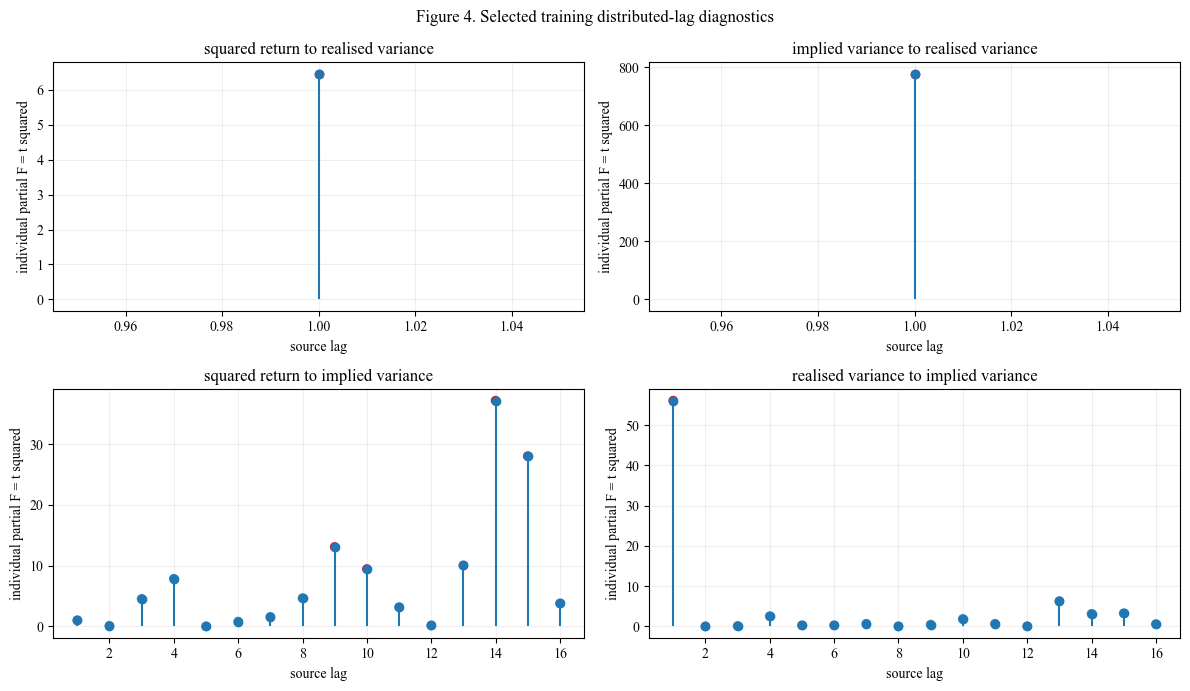

,edge_id,source,target,lag,coefficient,standard_error,t_statistic,partial_F_statistic,raw_p_value,holm_adjusted_p_value,holm_reject
0,squared_return_to_realised_variance,squared_return,realised_variance_ann_252,1,9.057614,3.563823,2.541544,6.459446,1.108631e-02,1.108631e-02,True
1,implied_variance_to_realised_variance,implied_variance_ann,realised_variance_ann_252,1,0.407520,0.014612,27.889884,777.845638,2.070935e-152,2.070935e-152,True
2,squared_return_to_implied_variance,squared_return,implied_variance_ann,1,-4.506575,4.456538,-1.011228,1.022582,3.120267e-01,1.000000e+00,False
3,squared_return_to_implied_variance,squared_return,implied_variance_ann,2,1.577272,4.565296,0.345492,0.119365,7.297602e-01,1.000000e+00,False
4,squared_return_to_implied_variance,squared_return,implied_variance_ann,3,-9.917226,4.658409,-2.128887,4.532160,3.338251e-02,3.102629e-01,False
5,squared_return_to_implied_variance,squared_return,implied_variance_ann,4,13.068506,4.664063,2.801957,7.850965,5.127082e-03,5.639791e-02,False
6,squared_return_to_implied_variance,squared_return,implied_variance_ann,5,0.440810,5.034500,0.087558,0.007666,9.302367e-01,1.000000e+00,False
7,squared_return_to_implied_variance,squared_return,implied_variance_ann,6,-4.499973,5.023437,-0.895796,0.802450,3.704671e-01,1.000000e+00,False
8,squared_return_to_implied_variance,squared_return,implied_variance_ann,7,6.305186,5.035346,1.252185,1.567968,2.106452e-01,1.000000e+00,False
9,squared_return_to_implied_variance,squared_return,implied_variance_ann,8,10.884090,5.043080,2.158223,4.657926,3.102629e-02,3.102629e-01,False


In [63]:

def contiguous_runs(mask):
    runs=[];start=None
    for i,ok in enumerate(np.asarray(mask,bool)):
        if ok and start is None:start=i
        if start is not None and (not ok or i==len(mask)-1):
            end=i if ok and i==len(mask)-1 else i-1;runs.append((start,end,end-start+1));start=None
    return runs

# Variable-specific availability runs on the intact training calendar.
train_idx=np.flatnonzero(panel.sample_split.eq("train"))
station_rows=[];station_blocks=[]
for state in STATES:
    mask=np.isfinite(panel.loc[train_idx,state].to_numpy(float));runs=contiguous_runs(mask);a,b,n=max(runs,key=lambda z:z[2]);long_idx=train_idx[a:b+1]
    for role,(aa,bb,nn) in [("longest", (a,b,n))]+[("substantial",(aa,bb,nn)) for aa,bb,nn in runs if nn>=MIN_STATIONARITY_BLOCK and (aa,bb,nn)!=(a,b,n)]:
        idx=train_idx[aa:bb+1];x=panel.loc[idx,state].to_numpy(float)
        adf_s,adf_p,*_=adfuller(x,regression="c",autolag="AIC")
        with warnings.catch_warnings():
            warnings.simplefilter("ignore");kpss_s,kpss_p,*_=kpss(x,regression="c",nlags="auto")
        if adf_p<ALPHA and kpss_p>=ALPHA:status="stationarity_supported"
        elif adf_p<ALPHA and kpss_p<ALPHA:status="non_unit_root_but_regime_instability"
        elif adf_p>=ALPHA and kpss_p<ALPHA:status="unit_root_concern"
        else:status="mixed"
        rec={"variable":state,"run_role":role,"run_start":panel.loc[idx[0],"model_day"],"run_end":panel.loc[idx[-1],"model_day"],"n_observations":len(idx),"ADF_statistic":adf_s,"ADF_p_value":adf_p,"KPSS_statistic":kpss_s,"KPSS_p_value":kpss_p,"stationarity_interpretation":status}
        station_blocks.append(rec)
        if role=="longest":station_rows.append(rec)
stationarity=pd.DataFrame(station_rows);stationarity_blocks=pd.DataFrame(station_blocks)
stationarity_map=stationarity.set_index("variable").stationarity_interpretation.to_dict()
display(stationarity);display(stationarity_blocks)

fig,axes=plt.subplots(3,1,figsize=(13,8),sharex=True)
for ax,state,label in zip(axes,STATES,["Squared return","Annualised realised variance","Bloomberg annualised implied variance"]):
    ax.plot(panel.model_day,panel[state],lw=.45);ax.axvline(panel.model_day.iloc[train_end],color="black",ls="--",label="train/validation");ax.axvline(panel.model_day.iloc[validation_end],color="grey",ls="--",label="validation/test");ax.set_ylabel(label);ax.grid(alpha=.2)
axes[0].legend(fontsize=8);axes[-1].set_xlabel("model day");fig.suptitle("Figure 1. Primary states and fixed chronological boundaries");fig.tight_layout();plt.show()

order_scan_df=pd.concat([order_scan(panel,"realised_variance_ann_252"),order_scan(panel,"implied_variance_ann")],ignore_index=True)
assert order_scan_df.groupby("target").size().eq(MAX_LAG).all() and order_scan_df.groupby("target").n_observations.nunique().eq(1).all()
n_star=int(order_scan_df.query("target=='realised_variance_ann_252'").sort_values("BIC").iloc[0].history_order)
m_star=int(order_scan_df.query("target=='implied_variance_ann'").sort_values("BIC").iloc[0].history_order)
order_warning={"realised_variance_ann_252":n_star==MAX_LAG,"implied_variance_ann":m_star==MAX_LAG}
fig,axs=plt.subplots(1,2,figsize=(12,4))
for ax,(target,title,selected) in zip(axs,[("realised_variance_ann_252","Figure 2. Realised-variance history search",n_star),("implied_variance_ann","Figure 3. Implied-variance history search",m_star)]):
    d=order_scan_df.query("target==@target");ax.plot(d.history_order,d.AIC,"o-",label="AIC");ax.plot(d.history_order,d.BIC,"o-",label="BIC");ax.axvline(selected,color="crimson",ls=":",lw=2,label=f"BIC selected p={selected}");ax.set(title=title,xlabel="history length p (model days)",ylabel="criterion");ax.legend(fontsize=8);ax.grid(alpha=.2)
fig.tight_layout();plt.show();display(order_scan_df)

edge_specs=[("squared_return_to_realised_variance","squared_return","realised_variance_ann_252",n_star),("implied_variance_to_realised_variance","implied_variance_ann","realised_variance_ann_252",n_star),("squared_return_to_implied_variance","squared_return","implied_variance_ann",m_star),("realised_variance_to_implied_variance","realised_variance_ann_252","implied_variance_ann",m_star)]
gc_rows=[];selected_fit={};selected_names={}
for split in ["train","validation","test"]:
    for edge,source,target,p in edge_specs:
        row,fit,names=gc_test(panel,target,source,p,split);row["edge_id"]=edge;gc_rows.append(row)
        if split=="train":selected_fit[target]=fit;selected_names[target]=names
gcblocks=pd.DataFrame(gc_rows).groupby("split",group_keys=False).apply(holm).reset_index(drop=True)
gcblocks["HAC_support"]=gcblocks.HAC_p<ALPHA
piv=gcblocks.pivot(index="edge_id",columns="split",values="holm_reject")
gcblocks["retained_for_notebook17"]=gcblocks.edge_id.map({e:bool(piv.loc[e,"train"] and piv.loc[e,"validation"]) for e,*_ in edge_specs})

own_rows=[]
for split in ["train","validation","test"]:
    for label,target,p in [("realised_variance_own_history","realised_variance_ann_252",n_star),("implied_variance_own_history","implied_variance_ann",m_star)]:
        row,_,_=gc_test(panel,target,target,p,split);row["edge_id"]=label;own_rows.append(row)
ownblocks=pd.DataFrame(own_rows).groupby("split",group_keys=False).apply(holm).reset_index(drop=True)
ownblocks["HAC_support"]=ownblocks.HAC_p<ALPHA

resid_rows=[]
for target,p in [("realised_variance_ann_252",n_star),("implied_variance_ann",m_star)]:
    fit=selected_fit[target];lb=acorr_ljungbox(fit.resid,lags=[5,10,20],return_df=True)
    for lag,row in lb.iterrows():resid_rows.append({"target":target,"selected_history_order":p,"lag":int(lag),"Ljung_Box_stat":float(row.lb_stat),"Ljung_Box_p_value":float(row.lb_pvalue)})
residuals=pd.DataFrame(resid_rows);display(gcblocks);display(Markdown("### Own-history persistence"));display(ownblocks);display(Markdown("### Training residual diagnostics"));display(residuals)

lags=[]
for edge,source,target,p in edge_specs:
    fit=selected_fit[target];names=selected_names[target];positions=[i for i,n in enumerate(names) if n in lagcols(source,p)]
    for j,pos in enumerate(positions,1):
        lags.append({"edge_id":edge,"source":source,"target":target,"lag":j,"coefficient":float(fit.params[pos]),"standard_error":float(fit.bse[pos]),"t_statistic":float(fit.tvalues[pos]),"partial_F_statistic":float(fit.tvalues[pos]**2),"raw_p_value":float(fit.pvalues[pos])})
individual=pd.DataFrame(lags).groupby("edge_id",group_keys=False).apply(holm).reset_index(drop=True)
fig,axs=plt.subplots(2,2,figsize=(12,7))
for ax,(edge,d) in zip(axs.flat,individual.groupby("edge_id",sort=False)):
    ax.stem(d.lag,d.partial_F_statistic,basefmt=" ");ax.scatter(d.lag,d.partial_F_statistic,c=np.where(d.holm_reject,"crimson","steelblue"));ax.set(title=edge.replace("_"," "),xlabel="source lag",ylabel="individual partial F = t squared");ax.grid(alpha=.2)
fig.suptitle("Figure 4. Selected training distributed-lag diagnostics");fig.tight_layout();plt.show();display(individual)


## RAW selected-order interpretation

The executed training-only AIC/BIC search selects

$$\boxed{n_{\mathrm{RAW}}^*=1,\qquad m_{\mathrm{RAW}}^*=16.}$$

The first selected order is realised-variance history depth and the second is implied-variance history depth. BIC is the primary criterion; AIC remains the secondary diagnostic. These are history lengths, not causal delays. RAW implied variance therefore requires substantially longer history than realised variance.

## 5. RAW direct four-direction TDMI

TDMI selection and inference are implemented directly for the four source-to-target relationships: squared return → realised variance; implied variance → realised variance; squared return → implied variance; and realised variance → implied variance. Each direction evaluates only positive source-leading lags 1–20. The target row determines TRAIN, VALIDATION, or TEST membership; the source is always an earlier intact-calendar row. Consequently a validation target may use genuinely preceding end-of-training information, but no target can be paired with a future source from a later split.

Mutual information and the directional lag convention are displayed explicitly in the primary TDMI section below. It is symmetric, but the explicit source-before-target construction supplies the lead-lag interpretation. A TRAIN TDMI peak is the corrected-significant lag with the largest TDMI value; it is strongest significant lead-lag dependence, not a causal or physical delay.

Both continuous series are quantile-binned. TRAIN-derived edges are frozen—with infinite outer edges—for VALIDATION and TEST. Ten bins and 1,000 circular-shift source surrogates are the primary inferential method. The five- and fifteen-bin searches are descriptive timing sensitivities and never alter the ten-bin TRAIN selection. Circular shifts preserve source serial structure better than independent shuffling, and Holm correction applies across each direction’s twenty positive lags.

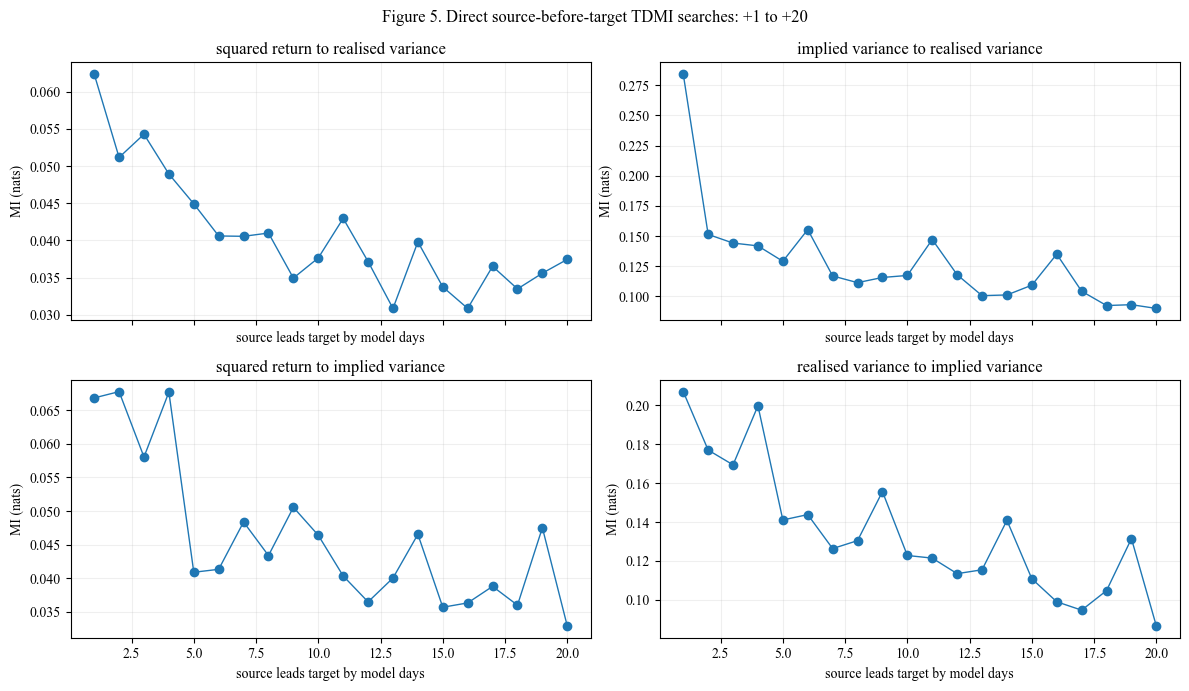

,edge_id,source,target,training_tdmi_support,training_tdmi_peak_lag,training_tdmi_value,training_tdmi_raw_p,training_tdmi_holm_p,tdmi_validation_value,tdmi_validation_p,tdmi_validation_support,tdmi_test_value,tdmi_test_p,tdmi_test_support,tdmi_peak_5_bins,tdmi_peak_10_bins,tdmi_peak_15_bins,tdmi_peak_bin_stability
0,squared_return_to_realised_variance,squared_return,realised_variance_ann_252,True,1,0.062371,0.000999,0.01998,0.083696,0.000999,True,0.107664,0.000999,True,1,1,1,stable
1,implied_variance_to_realised_variance,implied_variance_ann,realised_variance_ann_252,True,1,0.284269,0.000999,0.01998,0.234212,0.000999,True,0.294732,0.000999,True,1,1,1,stable
2,squared_return_to_implied_variance,squared_return,implied_variance_ann,True,2,0.067802,0.000999,0.01998,0.085739,0.000999,True,0.073001,0.000999,True,4,2,2,approximately_stable
3,realised_variance_to_implied_variance,realised_variance_ann_252,implied_variance_ann,True,1,0.207138,0.000999,0.01998,0.188604,0.000999,True,0.182921,0.000999,True,1,1,1,stable


In [64]:

def fixed_edges(values,bins):
    finite_values=np.asarray(values,float)
    finite_values=finite_values[np.isfinite(finite_values)]
    quantiles=np.linspace(0,1,bins+1)[1:-1]
    cuts=np.unique(np.quantile(finite_values,quantiles))
    if len(cuts)<1:
        raise ValueError("TDMI requires at least two distinct training regions.")
    return np.r_[-np.inf,cuts,np.inf]
def mi_value(x,y,ex,ey):
    # Discretise X and Y using TRAIN-frozen edges.
    x_bins=np.digitize(x,ex[1:-1],right=True)
    y_bins=np.digitize(y,ey[1:-1],right=True)
    joint_counts=np.zeros((x_bins.max()+1,y_bins.max()+1))
    np.add.at(joint_counts,(x_bins,y_bins),1)
    joint_probability=joint_counts/joint_counts.sum()
    x_marginal=joint_probability.sum(1,keepdims=True)
    y_marginal=joint_probability.sum(0,keepdims=True)
    marginal_product=x_marginal@y_marginal
    nonzero_cells=joint_probability>0
    return float(np.sum(joint_probability[nonzero_cells]*np.log(joint_probability[nonzero_cells]/marginal_product[nonzero_cells])))
def tdmi_direct(frame,source,target,lag,split,edges,source_override=None):
    # Positive lag only: source at t-k; target row itself defines split membership.
    assert 1<=lag<=MAX_LAG
    base=frame[source].to_numpy(float) if source_override is None else source_override
    source_lagged=np.roll(base,lag);target_current=frame[target].to_numpy(float)
    target_mask=frame.sample_split.eq(split).to_numpy(bool);target_mask[:lag]=False
    valid=target_mask&np.isfinite(source_lagged)&np.isfinite(target_current)
    target_positions=np.flatnonzero(valid);source_positions=target_positions-lag
    assert np.all(source_positions<target_positions)
    assert frame.loc[valid,"sample_split"].eq(split).all()
    if split=="train":assert not frame.loc[valid,"sample_split"].isin(["validation","test"]).any()
    if split=="validation":assert not frame.loc[valid,"sample_split"].eq("test").any()
    return (mi_value(source_lagged[valid],target_current[valid],edges[source],edges[target]),int(valid.sum())) if valid.sum()>=20 else (np.nan,int(valid.sum()))
def surrogate_p(frame,source,target,lag,split,edges,rng,B=TDMI_SURROGATES):
    observed,n=tdmi_direct(frame,source,target,lag,split,edges)
    positions=np.flatnonzero(frame.sample_split.eq(split));base=frame[source].to_numpy(float);segment=base[positions].copy()
    shifts=np.arange(MAX_LAG+1,max(MAX_LAG+2,len(segment)-MAX_LAG))
    null=np.empty(B)
    for i,shift in enumerate(rng.choice(shifts,size=B)):
        altered=base.copy();altered[positions]=np.roll(segment,int(shift))
        null[i]=tdmi_direct(frame,source,target,lag,split,edges,altered)[0]
    return observed,n,float((1+np.sum(null>=observed))/(1+B))
def tdmi_training_search(frame,source,target,bins,with_surrogates):
    edges={source:fixed_edges(frame.loc[frame.sample_split.eq("train")&np.isfinite(frame[source]),source],bins),target:fixed_edges(frame.loc[frame.sample_split.eq("train")&np.isfinite(frame[target]),target],bins)}
    rows=[];rng=np.random.default_rng(RANDOM_SEED+bins+len(source)+len(target))
    for lag in range(1,MAX_LAG+1):
        value,n=tdmi_direct(frame,source,target,lag,"train",edges)
        row={"source":source,"target":target,"split":"train","lag":lag,"bins":bins,"tdmi":value,"n_pairs":n,"raw_p":np.nan}
        if with_surrogates:
            value,n,pv=surrogate_p(frame,source,target,lag,"train",edges,rng);row.update(tdmi=value,n_pairs=n,raw_p=pv)
        rows.append(row)
    out=pd.DataFrame(rows)
    if with_surrogates:
        adjusted=holm(out.rename(columns={"raw_p":"raw_p_value"}))
        out["holm_p"]=adjusted.holm_adjusted_p_value;out["significant"]=adjusted.holm_reject
    else:
        out["holm_p"]=np.nan;out["significant"]=np.nan
    return out,edges

tdmi_specs=[
("squared_return_to_realised_variance","squared_return","realised_variance_ann_252"),
("implied_variance_to_realised_variance","implied_variance_ann","realised_variance_ann_252"),
("squared_return_to_implied_variance","squared_return","implied_variance_ann"),
("realised_variance_to_implied_variance","realised_variance_ann_252","implied_variance_ann")]
primary_curves=[];edge_maps={};primary_summary=[]
for edge,source,target in tdmi_specs:
    curve,edges=tdmi_training_search(panel,source,target,10,True);primary_curves.append(curve.assign(edge_id=edge,curve_role="primary_10_bin"));edge_maps[edge]=edges
    sig=curve[curve.significant.fillna(False)]
    peak=int(sig.sort_values("tdmi",ascending=False).iloc[0].lag) if len(sig) else np.nan
    peak_row=sig.sort_values("tdmi",ascending=False).iloc[0] if len(sig) else None
    primary_summary.append({"edge_id":edge,"source":source,"target":target,"training_tdmi_support":bool(len(sig)),"training_tdmi_peak_lag":peak,"training_tdmi_value":float(peak_row.tdmi) if peak_row is not None else np.nan,"training_tdmi_raw_p":float(peak_row.raw_p) if peak_row is not None else np.nan,"training_tdmi_holm_p":float(peak_row.holm_p) if peak_row is not None else np.nan})
tdmi_curves=pd.concat(primary_curves,ignore_index=True)
assert tdmi_curves.lag.between(1,MAX_LAG).all() and tdmi_curves.groupby("edge_id").size().eq(MAX_LAG).all()

# Training peak is frozen before direct validation/test evaluation; target split remains the membership rule.
tdmi_holdout_rows=[]
for rec in primary_summary:
    if np.isfinite(rec["training_tdmi_peak_lag"]):
        for split in ["validation","test"]:
            value,n,pv=surrogate_p(panel,rec["source"],rec["target"],int(rec["training_tdmi_peak_lag"]),split,edge_maps[rec["edge_id"]],np.random.default_rng(RANDOM_SEED+500+len(rec["edge_id"])))
            tdmi_holdout_rows.append({"edge_id":rec["edge_id"],"split":split,"tdmi_value":value,"tdmi_p":pv,"tdmi_support":pv<ALPHA,"n_pairs":n})
tdmi_holdout=pd.DataFrame(tdmi_holdout_rows)

# Complete direct training peak searches at 5/10/15 bins; 10-bin inference remains primary.
bin_curve_parts=[];bin_peak_rows=[]
for bins in [5,10,15]:
    for edge,source,target in tdmi_specs:
        curve,_=tdmi_training_search(panel,source,target,bins,bins==10)
        bin_curve_parts.append(curve.assign(edge_id=edge,curve_role="bin_sensitivity_descriptive" if bins!=10 else "bin_sensitivity_primary"))
        candidate=curve[curve.significant.fillna(False)] if bins==10 else curve
        peak=int(candidate.sort_values("tdmi",ascending=False).iloc[0].lag) if len(candidate) else np.nan
        bin_peak_rows.append({"edge_id":edge,"bins":bins,"peak_lag":peak,"peak_is_primary_significant":bool(bins==10 and len(candidate))})
bin_peaks=pd.DataFrame(bin_peak_rows)
bin_stability=[]
for edge,d in bin_peaks.groupby("edge_id"):
    vals=d.peak_lag.dropna().to_numpy(float)
    stability="sensitive_to_binning" if len(vals)<2 or np.ptp(vals)>2 else ("stable" if np.ptp(vals)==0 else "approximately_stable")
    bin_stability.append({"edge_id":edge,"tdmi_peak_5_bins":d.loc[d.bins.eq(5),"peak_lag"].iloc[0],"tdmi_peak_10_bins":d.loc[d.bins.eq(10),"peak_lag"].iloc[0],"tdmi_peak_15_bins":d.loc[d.bins.eq(15),"peak_lag"].iloc[0],"tdmi_peak_bin_stability":stability})
bin_stability=pd.DataFrame(bin_stability)

summary_base=pd.DataFrame(primary_summary)
for split in ["validation","test"]:
    d=tdmi_holdout[tdmi_holdout.split.eq(split)].set_index("edge_id") if len(tdmi_holdout) else pd.DataFrame()
    summary_base[f"tdmi_{split}_value"]=summary_base.edge_id.map(d.tdmi_value if len(d) else {})
    summary_base[f"tdmi_{split}_p"]=summary_base.edge_id.map(d.tdmi_p if len(d) else {})
    summary_base[f"tdmi_{split}_support"]=summary_base.edge_id.map(d.tdmi_support if len(d) else {}).fillna(False).astype(bool)
tdmi_summary=summary_base.merge(bin_stability,on="edge_id",how="left")

fig,axs=plt.subplots(2,2,figsize=(12,7),sharex=True)
for ax,(edge,d) in zip(axs.flat,tdmi_curves.groupby("edge_id",sort=False)):
    ax.plot(d.lag,d.tdmi,"o-",lw=1);ax.set(title=edge.replace("_"," "),xlabel="source leads target by model days",ylabel="MI (nats)");ax.grid(alpha=.2)
fig.suptitle("Figure 5. Direct source-before-target TDMI searches: +1 to +20");fig.tight_layout();plt.show();display(tdmi_summary)


## 6. RAW diagnostics and common return-state check

The full empirical system also contains Linus's spot-return observation equation. It has a different role from the two distributed-lag variance equations: it links the signed one-model-day return to the contemporaneous realised-volatility state, rather than introducing a new history-selection exercise.

The signed one-model-day return is stored as `within_session_log_return`. Define

$$
Q_t=r_t^2,
\qquad
R_t=252\,RV_t^{\mathrm{within}},
\qquad
I_t=\sigma_t^{2,\mathrm{imp,ann}}.
$$

In the implementation, the within-day realised-variance and implied-variance states are stored as `rv_within` and `iv_ann_var`. The empirical realised-volatility state remains annualised. Horizon scaling is carried by Linus's noise term:

$$
\boxed{
r_t=\mu+\sqrt{R_t}\epsilon_t,
\qquad
\epsilon_t\sim N(0,1/252).
}
$$

The equivalent standard-normal form does not redefine realised volatility. The Linus-style form above remains primary, and the factor 252 is the project’s model-day annualisation convention, not a Bloomberg day-count, weekend, expiry, or fixing-time claim.

The diagnostic standardises return using the fitted mean and realised-variance scale. Both numerator and denominator are constructed from the same intraday return path. Ignoring the small fitted mean for intuition,

$$
\widehat z_t
\approx
\frac{\sum_h r_{t,h}}
{\sqrt{\sum_h r_{t,h}^2}}.
$$

This is a self-normalised return statistic. Its empirical distribution reflects both the underlying return process and construction of the realised-variance denominator. The histogram, Q–Q plot, moments, and Jarque–Bera statistic are descriptive diagnostics of the empirical Equation (1) representation, rather than a direct statistical test of an independently observed latent Gaussian innovation. Exact normality of the proxy-implied standardised return is rejected descriptively, but this is not direct rejection of the latent Gaussian innovation assumption because the denominator is estimated from the same intraday return path.

The constant mean is a one-model-day conditional return mean and is not annualised. Notebook 16 fixes this parsimonious first representation, but does not set it to zero or add AR terms. The signed-return diagnostics show some weak serial dependence at selected horizons, but not enough within Exercise 1 to justify an additional autoregressive return-mean model absent from Linus's proposed Equation (1). The diagnostic uses finite signed returns and finite positive realised variance without requiring current implied variance; VALIDATION and TEST use the frozen TRAIN mean.

Observed realised variance spans the same model day as signed return, so these are in-sample state diagnostics, not tradable forecasts. Notebook 17 instead combines its Equation-(2) forecast with Equation (1). The empirical realised-variance state is an hourly proxy, not an exactly observed latent instantaneous variance.

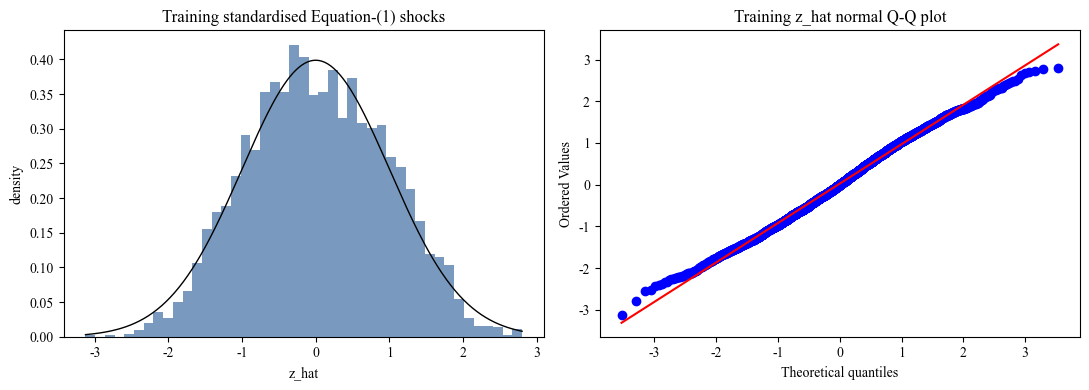

,split,n_obs,mu_train,mu_train_hac_se,mean_return,std_return,epsilon_hat_mean,epsilon_hat_variance,epsilon_target_variance,z_hat_mean,...,lb_return_10_p,lb_return_20_p,lb_z_5_p,lb_z_10_p,lb_z_20_p,lb_z2_5_p,lb_z2_10_p,lb_z2_20_p,jarque_bera_stat,jarque_bera_p
0,train,3372,0.000033,0.000104,0.000033,0.006445,0.001683,0.003553,0.003968,0.026717,...,0.181808,0.036650,0.668025,0.452311,0.297010,0.080068,0.116512,0.211724,31.119600,1.747691e-07
1,validation,1195,0.000033,0.000104,0.000060,0.004286,0.002531,0.003789,0.003968,0.040171,...,0.011710,0.062395,0.478352,0.763017,0.780608,0.047978,0.033904,0.193628,10.272066,5.880973e-03
2,test,1195,0.000033,0.000104,0.000333,0.006300,0.010680,0.004090,0.003968,0.169543,...,0.537051,0.291760,0.955139,0.566690,0.932022,0.038423,0.136733,0.088798,13.945682,9.369873e-04


In [65]:

# Compact Equation-(1) diagnostic: no return-target GC/TDMI or mean-model selection is introduced.
panel["equation1_eligible"]=(panel.rv_eligible.fillna(False).astype(bool)&np.isfinite(panel.within_session_log_return)&np.isfinite(panel.realised_variance_ann_252)&panel.realised_variance_ann_252.gt(0))
eq1_train=panel.loc[panel.sample_split.eq("train")&panel.equation1_eligible,"within_session_log_return"].to_numpy(float)
if len(eq1_train)<30: raise ValueError("Too few Equation-(1)-eligible training observations.")
mu_train=float(eq1_train.mean())
mean_fit=sm.OLS(eq1_train,np.ones((len(eq1_train),1))).fit()
mean_hac_lags=max(1,int(np.floor(4*(len(eq1_train)/100)**(2/9))))
mean_hac=mean_fit.get_robustcov_results(cov_type="HAC",maxlags=mean_hac_lags)
mu_train_hac_se=float(mean_hac.bse[0])

eq1_rows=[]
for split in ["train","validation","test"]:
    d=panel.loc[panel.sample_split.eq(split)&panel.equation1_eligible,["within_session_log_return","realised_variance_ann_252"]].copy()
    r=d.within_session_log_return.to_numpy(float);R=d.realised_variance_ann_252.to_numpy(float);er=r-mu_train
    epsilon_hat=er/np.sqrt(R);z_hat=np.sqrt(252)*epsilon_hat
    lb_r=acorr_ljungbox(er,lags=[5,10,20],return_df=True);lb_z=acorr_ljungbox(z_hat,lags=[5,10,20],return_df=True);lb_z2=acorr_ljungbox(z_hat**2,lags=[5,10,20],return_df=True)
    jb=stats.jarque_bera(z_hat)
    eq1_rows.append({"split":split,"n_obs":len(d),"mu_train":mu_train,"mu_train_hac_se":mu_train_hac_se,"mean_return":float(r.mean()),"std_return":float(r.std(ddof=1)),"epsilon_hat_mean":float(epsilon_hat.mean()),"epsilon_hat_variance":float(epsilon_hat.var(ddof=1)),"epsilon_target_variance":1/252,"z_hat_mean":float(z_hat.mean()),"z_hat_std":float(z_hat.std(ddof=1)),"z_hat_variance":float(z_hat.var(ddof=1)),"z_hat_skewness":float(stats.skew(z_hat,bias=False)),"z_hat_excess_kurtosis":float(stats.kurtosis(z_hat,fisher=True,bias=False)),"lb_return_5_p":float(lb_r.loc[5,"lb_pvalue"]),"lb_return_10_p":float(lb_r.loc[10,"lb_pvalue"]),"lb_return_20_p":float(lb_r.loc[20,"lb_pvalue"]),"lb_z_5_p":float(lb_z.loc[5,"lb_pvalue"]),"lb_z_10_p":float(lb_z.loc[10,"lb_pvalue"]),"lb_z_20_p":float(lb_z.loc[20,"lb_pvalue"]),"lb_z2_5_p":float(lb_z2.loc[5,"lb_pvalue"]),"lb_z2_10_p":float(lb_z2.loc[10,"lb_pvalue"]),"lb_z2_20_p":float(lb_z2.loc[20,"lb_pvalue"]),"jarque_bera_stat":float(jb.statistic),"jarque_bera_p":float(jb.pvalue)})
spot_diagnostics=pd.DataFrame(eq1_rows)
fig,axs=plt.subplots(1,2,figsize=(11,4))
train_z=(eq1_train-mu_train)/np.sqrt(panel.loc[panel.sample_split.eq("train")&panel.equation1_eligible,"realised_variance_ann_252"].to_numpy(float)/252)
axs[0].hist(train_z,bins=45,density=True,color="#4c78a8",alpha=.75);xx=np.linspace(train_z.min(),train_z.max(),300);axs[0].plot(xx,stats.norm.pdf(xx),color="black",lw=1);axs[0].set(title="Training standardised Equation-(1) shocks",xlabel="z_hat",ylabel="density")
stats.probplot(train_z,dist="norm",plot=axs[1]);axs[1].set_title("Training z_hat normal Q-Q plot");fig.tight_layout();plt.show();display(spot_diagnostics)


## 7. RAW benchmark interpretation and resulting equations

The retained-driver rule is unchanged: classical conditional GC must survive Holm correction in both training and validation. Test does not revise that decision. The final hand-off table separates selection from robust inference, TDMI agreement, and final-holdout persistence. A statistically significant relationship can still have small partial R²; the final interpretation therefore considers p-values, effect size, validation, test, HAC robustness, TDMI, and bin stability together.

The closure-gap realised-variance state is a genuine robustness check. It includes available reopening movement through 252 times rv_with_closure_gap but is not allowed to select a new order or TDMI peak.

# RAW benchmark equations and empirical interpretation

The empirical system now freezes all three equations. Equation (1) is the spot-return observation/distribution equation,

$$
\boxed{r_t=\mu+\sqrt{R_t}\epsilon_t,\qquad \epsilon_t\sim N(0,1/252),}
$$

The signed return is stored as `within_session_log_return`; the within-day realised-variance proxy is stored as `rv_within`. The annualised realised-volatility state and its one-model-day scaling are defined in the display equations below. This remains the Linus-style representation and does not redefine or deannualise realised volatility.

Equation (1) links contemporaneous realised volatility to the signed-return distribution, unlike the two distributed-lag variance equations. It retains a parsimonious constant one-model-day mean and is not forced into BIC, GC, or TDMI machinery for symmetry. The compact diagnostic adds no AR terms, return-target GC/TDMI, GARCH, jumps, or alternative shock distribution. Because return and the realised-variance proxy share the same intraday path, its distributional evidence is descriptive rather than a standalone test of a latent innovation. This is an in-sample state diagnostic; N17 supplies the forecasted variance state.

Equations (2) and (3) remain the empirically selected dynamic backgrounds; Equation (1) is the observation equation. The existing squared-return GC/TDMI analysis asks whether past return magnitude predicts future variance states, which is distinct from Equation (1)'s contemporaneous dispersion role. Volatility dependence does not automatically imply volatility should enter the signed-return conditional mean.

Linus's realised-variance background is written as

$$
\widetilde{\sigma}_i^2
=
\widetilde{\phi}_i+
\sum_{j=1}^{n}\left(
\widetilde{\alpha}_j r_{i-j}^2+
\widetilde{\beta}_j\widetilde{\sigma}_{i-j}^2+
\widetilde{\gamma}_j\sigma_{i\mid i-j}^2
\right)
+\widetilde{\nu}_i\eta_i,
$$

while the implied-variance background is

$$
\sigma_i^2
=
\phi_i+
\sum_{j=1}^{m}\left(
\alpha_j r_{i-j}^2+
\beta_j\widetilde{\sigma}_{i-j}^2+
\gamma_j\sigma_{i\mid i-j}^2
\right)
+\nu_i\zeta_i.
$$

The stochastic terms are therefore the complete products
The variance-equation innovations are composite scale-times-shock terms, not bare shocks or a generic epsilon. Linus permits the scales to be constant or time varying. This notation remains distinct from Equation (1)'s spot-return shock.

For the empirical regression, define the composite disturbances

$$
u_t^R\equiv\widetilde{\nu}_t\eta_t,
\qquad
u_t^I\equiv\nu_t\zeta_t.
$$

OLS observes only the realised composite residual in a fitted equation; it cannot separately identify an innovation scale and an innovation without extra distributional and scale-evolution assumptions. N16 therefore identifies conditional-history structure while the composite product remains in the regression residual. It does not introduce a stochastic-volatility decomposition. HAC/Newey–West likewise checks coefficient-block inference against heteroskedasticity and short-range residual autocorrelation rather than estimating an innovation scale.

Write the three observed empirical states as

$$
Q_t\equiv r_t^2,\qquad
R_t\equiv252\,RV_t^{\mathrm{within}},\qquad
I_t\equiv\left(\frac{q_t}{100}\right)^2.
$$

The return, within-day realised-variance, and implied-variance states are stored as `within_session_log_return`, `rv_within`, and `iv_ann_var`. They correspond to complete-session return, annualised realised variance under the 252-model-day convention, and Bloomberg annualised overnight/1D ATM implied variance. Linus explicitly instructed us to ignore Equation (5), so it is intentionally excluded. The observed implied-variance state is an empirical observable predictor and is not claimed to equal the unavailable conditional forward-implied-variance object.

Under this approved simplification, Linus's candidate system becomes

$$
R_t=
\widetilde{\phi}+
\sum_{j=1}^{n}
\left[
\widetilde{\alpha}_jQ_{t-j}+
\widetilde{\beta}_jR_{t-j}+
\widetilde{\gamma}_jI_{t-j}
\right]+u_t^R,
\qquad
u_t^R=\widetilde{\nu}_t\eta_t,
$$

and

$$
I_t=
\phi+
\sum_{j=1}^{m}
\left[
\alpha_jQ_{t-j}+
\beta_jR_{t-j}+
\gamma_jI_{t-j}
\right]+u_t^I,
\qquad
u_t^I=\nu_t\zeta_t.
$$

“Construct the causal structure” is used narrowly here. Notebook 16 does not discover an unrestricted structural causal graph or prove interventionist causality. Within Linus's two candidate variance background equations, it tests the Q → R, I → R, Q → I, and R → I history blocks for predictive/dependence information; own-history persistence is assessed separately. It does not create a third distributed-lag equation with Q as target, because Linus's return equation has a different role.

Conditional Granger causality determines whether an entire source-history block adds incremental **linear predictive information** after the other histories in the relevant target equation are controlled for. For example, I → R tests whether the implied-variance history jointly improves prediction of R beyond R and Q histories. Conditional GC is therefore the criterion for retaining the corresponding coefficient block in the parametric background. TDMI is complementary pairwise nonlinear lead-lag evidence over positive lags 1–20. The direct implementation tests both directions by reversing source and target; this keeps the target index visible and prevents split-boundary leakage.

Linus leaves the history orders generic. TRAIN-only BIC searches orders 1–20 separately for the two equations; AIC is secondary. The executed result is

$$
\boxed{n^*=1,\qquad m^*=16.}
$$

These are history lengths, not causal delays. Conditional on the three candidate histories, realised variance requires only one model day of history by BIC, whereas implied variance has substantially longer selected persistence of sixteen model days.

For the **RAW-IV benchmark**, the predefined classical TRAIN-plus-VALIDATION GC rule retains all four candidate cross-variable blocks. The evidence is not equally strong: implied variance → realised variance is strongest and most stable, while the other retained blocks are less robust across HAC inference and/or the untouched holdout. TDMI supplies complementary timing evidence and does not override the parametric GC retention rule.

The resulting **RAW-IV benchmark** equations are therefore

$$
\boxed{
R_t=
\widetilde{\phi}+
\widetilde{\alpha}_1Q_{t-1}+
\widetilde{\beta}_1R_{t-1}+
\widetilde{\gamma}_1I_{t-1}
+u_t^R,
\qquad
u_t^R=\widetilde{\nu}_t\eta_t.
}
$$

Today's annualised realised variance has one model day of squared-return, realised-variance, and implied-variance history, plus the unresolved composite realised-variance innovation. It is not a claim that Notebook 16 has calibrated final forecasting coefficients.

The corresponding RAW implied-variance benchmark equation is

$$
\boxed{
I_t=
\phi+
\sum_{j=1}^{16}
\left[
\alpha_jQ_{t-j}+
\beta_jR_{t-j}+
\gamma_jI_{t-j}
\right]
+u_t^I,
\qquad
u_t^I=\nu_t\zeta_t.
}
$$

Today's annualised implied variance consequently uses sixteen model days of each candidate history plus Linus's composite implied-variance innovation.

Under RAW IV, the realised order is 1, the implied order is 16, and all four cross-variable blocks satisfy the predefined TRAIN-plus-VALIDATION rule. This is the **pre-normalisation benchmark**, not the final primary hand-off. The observed squared Bloomberg overnight/1D ATM IV state is an empirical observable substitute, not the unavailable Equation-(5) forward object.

Notebook 16 is event-unaware: event dates remain in the sample, but event indicators and weights are not in these regressions. It has not estimated event weights, calibrated forecasting backgrounds, proved structural causality, or separately identified residual innovation scales and shocks. Linus explicitly instructed us to ignore Equation (5). N16 operationalises dependence-structure and history-order selection; unexplained innovations remain composite residual terms.

In [66]:

closure_states=["squared_return","realised_variance_with_closure_ann_252","implied_variance_ann"];panel["_closure_eligible"]=panel.structure_eligible&np.isfinite(panel.realised_variance_with_closure_ann_252)
closure_specs=[("squared_return_to_realised_variance","squared_return","realised_variance_with_closure_ann_252",n_star),("implied_variance_to_realised_variance","implied_variance_ann","realised_variance_with_closure_ann_252",n_star),("squared_return_to_implied_variance","squared_return","implied_variance_ann",m_star),("realised_variance_to_implied_variance","realised_variance_with_closure_ann_252","implied_variance_ann",m_star)]
cg=[]
for edge,source,target,p in closure_specs:
    r,_,_=gc_test(panel,target,source,p,"train",closure_states);r["edge_id"]=edge;cg.append(r)
closure_gc=holm(pd.DataFrame(cg));closure_gc["HAC_support"]=closure_gc.HAC_p<ALPHA
primary_train=gcblocks.query("split=='train'")[["edge_id","holm_reject"]].rename(columns={"holm_reject":"primary_classical_support"})
closure_gc=closure_gc.merge(primary_train,on="edge_id");closure_gc["closure_gap_training_robust"]=closure_gc.holm_reject.eq(closure_gc.primary_classical_support)

# System qualification includes every state entering each conditional regression.
def sysq(statuses):
    vals=set(statuses.values())
    if vals=={"stationarity_supported"}:return "stationarity_supported_across_system"
    if "unit_root_concern" in vals:return "unit_root_concern_present"
    if "non_unit_root_but_regime_instability" in vals and vals.issubset({"stationarity_supported","non_unit_root_but_regime_instability"}):return "no_clear_unit_root_but_regime_instability_present"
    return "mixed_stationarity_evidence"
system_stationarity_qualification=sysq(stationarity_map)
def gr(edge,split):return gcblocks[(gcblocks.edge_id==edge)&(gcblocks.split==split)].iloc[0]

spec=[]
for edge,source,target,p in edge_specs:
    tr,va,te=gr(edge,"train"),gr(edge,"validation"),gr(edge,"test");td=tdmi_summary[tdmi_summary.edge_id==edge].iloc[0];cl=closure_gc[closure_gc.edge_id==edge].iloc[0]
    retained=bool(tr.holm_reject and va.holm_reject);testok=bool(te.holm_reject);hac_tv=bool(tr.HAC_support and va.HAC_support)
    evidence="not_retained" if not retained else ("retained_but_not_holdout_stable" if not testok else ("classical_only_or_robustness_sensitive" if not hac_tv else ("very_strong_and_stable" if td.training_tdmi_support else "retained_with_no_TDMI_peak")))
    spec.append({"source":source,"target":target,"selected_target_history_order":p,"retained_from_train_validation":retained,"train_classical_support":bool(tr.holm_reject),"train_classical_raw_p":tr.raw_p_value,"train_classical_holm_p":tr.holm_adjusted_p_value,"train_partial_R2":tr.partial_R2,"validation_classical_support":bool(va.holm_reject),"validation_classical_raw_p":va.raw_p_value,"validation_classical_holm_p":va.holm_adjusted_p_value,"validation_partial_R2":va.partial_R2,"test_classical_support":testok,"test_classical_raw_p":te.raw_p_value,"test_classical_holm_p":te.holm_adjusted_p_value,"test_partial_R2":te.partial_R2,"hac_support_train":bool(tr.HAC_support),"hac_support_validation":bool(va.HAC_support),"hac_support_test":bool(te.HAC_support),"train_validation_hac_robust":hac_tv,"holdout_stable":testok,"holdout_hac_robust":bool(testok and te.HAC_support),"training_tdmi_peak_lag":td.training_tdmi_peak_lag,"training_tdmi_value":td.training_tdmi_value,"training_tdmi_raw_p":td.training_tdmi_raw_p,"training_tdmi_holm_p":td.training_tdmi_holm_p,"tdmi_training_support":bool(td.training_tdmi_support),"tdmi_validation_value":td.tdmi_validation_value,"tdmi_validation_p":td.tdmi_validation_p,"tdmi_validation_support":bool(td.tdmi_validation_support),"tdmi_test_value":td.tdmi_test_value,"tdmi_test_p":td.tdmi_test_p,"tdmi_test_support":bool(td.tdmi_test_support),"tdmi_peak_5_bins":td.tdmi_peak_5_bins,"tdmi_peak_10_bins":td.tdmi_peak_10_bins,"tdmi_peak_15_bins":td.tdmi_peak_15_bins,"tdmi_peak_bin_stability":td.tdmi_peak_bin_stability,"source_stationarity_interpretation":stationarity_map[source],"target_stationarity_interpretation":stationarity_map[target],"system_stationarity_qualification":system_stationarity_qualification,"closure_gap_training_robust":bool(cl.closure_gap_training_robust),"history_order_boundary_warning":order_warning[target],"equation5_used":False,"evidence_strength":evidence})
model_spec=pd.DataFrame(spec)

trows=[]
for target,p in [("realised_variance_ann_252",n_star),("implied_variance_ann",m_star)]:
    z=order_scan_df[(order_scan_df.target==target)&(order_scan_df.history_order==p)].iloc[0];own=ownblocks[(ownblocks.target==target)&(ownblocks.split=="train")].iloc[0];lb=residuals[residuals.target==target].set_index("lag").Ljung_Box_p_value
    trows.append({"target":target,"selected_history_order":p,"AIC":z.AIC,"BIC":z.BIC,"order_boundary_warning":order_warning[target],"own_history_classical_support_train":bool(own.holm_reject),"own_history_HAC_support_train":bool(own.HAC_support),"residual_LB5_p":lb.get(5,np.nan),"residual_LB10_p":lb.get(10,np.nan),"residual_LB20_p":lb.get(20,np.nan)})
target_summary=pd.DataFrame(trows)
# Target-equation sample sizes are explicit; both source-block tests share a target/order sample.
selected_sample_counts=(gcblocks[gcblocks.test_type.eq("cross_variable") if "test_type" in gcblocks.columns else gcblocks.edge_id.notna()]
    .groupby(["target","split"],as_index=False)["n_observations"].first()
    .pivot(index="target",columns="split",values="n_observations").reset_index()
    .rename(columns={"train":"selected_n_train","validation":"selected_n_validation","test":"selected_n_test"}))
target_summary=target_summary.merge(selected_sample_counts,on="target",how="left")
sensitivity=pd.concat([bin_stability.assign(sensitivity="TDMI_bin_peak"),closure_gc[["edge_id","closure_gap_training_robust"]].assign(sensitivity="closure_gap_training"),model_spec[["source","target","train_validation_hac_robust","holdout_hac_robust"]].assign(sensitivity="HAC_inference")],ignore_index=True,sort=False)
all_curves=pd.concat([tdmi_curves,*bin_curve_parts],ignore_index=True,sort=False)
# Full three-equation machine-readable handoff; the existing two-target GC table remains intact.
system_specification=pd.DataFrame([
 {"equation":"spot_return","target":"within_session_log_return","mean_structure":"constant","mean_parameter":"mu","volatility_state":"realised_variance_ann_252","volatility_link":"sqrt","delta_t":"1/252","shock":"epsilon","shock_variance":"1/252","forecast_role":"observation_distribution"},
 {"equation":"realised_variance","target":"realised_variance_ann_252","history_order":n_star,"innovation":"u_R = nu_tilde * eta","forecast_role":"dynamic_background"},
 {"equation":"implied_variance","target":"implied_variance_ann","history_order":m_star,"innovation":"u_I = nu * zeta","forecast_role":"dynamic_background"}])
exports={"16_empirical_analysis_panel.csv":panel[["model_day","sample_split","structure_eligible"]+STATES+["realised_variance_with_closure_ann_252"]],"16_stationarity_diagnostics.csv":stationarity_blocks,"16_gc_order_scan.csv":order_scan_df,"16_gc_block_tests.csv":pd.concat([gcblocks.assign(test_type="cross_variable"),ownblocks.assign(test_type="own_history")],ignore_index=True),"16_gc_individual_lag_diagnostics.csv":individual,"16_residual_diagnostics.csv":residuals,"16_tdmi_curves.csv":all_curves,"16_tdmi_summary.csv":tdmi_summary,"16_closure_gap_sensitivity.csv":closure_gc,"16_model_specification.csv":model_spec,"16_target_model_summary.csv":target_summary,"16_sensitivity_summary.csv":sensitivity,"16_spot_return_equation_diagnostics.csv":spot_diagnostics,"16_system_specification.csv":system_specification}
for name,frame in exports.items():
    frame=frame.copy();frame.insert(0,"RUN_ID",RUN_ID);exports[name]=frame;frame.to_csv(PROCESSED_DIR/name,index=False)
ids=[]
for name,frame in exports.items():
    load=pd.read_csv(PROCESSED_DIR/name);assert len(load)==len(frame) and load.RUN_ID.nunique()==1 and load.RUN_ID.iloc[0]==RUN_ID;ids.append(load.RUN_ID.iloc[0])
assert len(set(ids))==1 and MAX_LAG==20 and TDMI_SURROGATES>=1000 and tdmi_curves.lag.between(1,20).all() and not model_spec.equation5_used.any()
assert np.isclose(panel.loc[panel.rv_within.notna(),"realised_variance_ann_252"],252*panel.loc[panel.rv_within.notna(),"rv_within"]).all()
assert (spot_diagnostics.epsilon_target_variance==1/252).all()
assert all(model_spec.retained_from_train_validation.eq(model_spec.train_classical_support&model_spec.validation_classical_support));display(model_spec);display(target_summary);display(closure_gc)
retained=model_spec.loc[model_spec.retained_from_train_validation,"source"].str.cat(model_spec.loc[model_spec.retained_from_train_validation,"target"],sep=" -> ").tolist()
failed=model_spec.loc[model_spec.retained_from_train_validation&~model_spec.holdout_stable,"source"].str.cat(model_spec.loc[model_spec.retained_from_train_validation&~model_spec.holdout_stable,"target"],sep=" -> ").tolist()
import inspect
assert "structure_eligible" not in inspect.getsource(gc_valid_rows)
assert order_scan_df.groupby("target").n_observations.nunique().eq(1).all()
assert (target_summary.selected_n_train >= order_scan_df.groupby("target").n_observations.first().reindex(target_summary.target).to_numpy()).all()
freeze_checks={
    "Fresh kernel run":"PASS",
    "Three-equation empirical system documented":"PASS",
    "Equation (1) included":"PASS",
    "Equation (1) annualisation convention consistent":"PASS",
    "epsilon variance = 1/252":"PASS",
    "No double scaling of realised volatility":"PASS",
    "Constant-mu primary specification documented":"PASS",
    "Spot-return diagnostics completed":"PASS",
    "Equation (2) GC/TDMI structure unchanged":"PASS",
    "Equation (3) GC/TDMI structure unchanged":"PASS",
    "Selected realised-variance order":f"PASS ({n_star})",
    "Selected implied-variance order":f"PASS ({m_star})",
    "No jump process":"PASS",
    "Single RUN_ID across outputs":"PASS" if len(set(ids))==1 else "FAIL",
    "GC uses target-specific samples":"PASS",
    "Order scan uses common lag-20 target-specific sample":"PASS",
    "Selected-order GC refitted on maximal valid sample":"PASS",
    "TDMI direct-direction logic unchanged":"PASS",
    "Equation (5) unused":"PASS" if not model_spec.equation5_used.any() else "FAIL",
    "No event predictors used":"PASS",
    "Notebook 14 unchanged":"PASS (frozen; not modified by this notebook)",
    "Notebook 15 corrected canonical panel":"PASS (reloaded from the executed (8) construction notebook)"}
freeze_table=pd.DataFrame(freeze_checks.items(),columns=["freeze_check","status"]);display(Markdown("# Notebook 16 freeze check"));display(freeze_table)
assert all(str(v).startswith("PASS") for v in freeze_checks.values())
print("NOTEBOOK 16 CORRECTED-PANEL RUN: PASS")



,source,target,selected_target_history_order,retained_from_train_validation,train_classical_support,train_classical_raw_p,train_classical_holm_p,train_partial_R2,validation_classical_support,validation_classical_raw_p,...,tdmi_peak_10_bins,tdmi_peak_15_bins,tdmi_peak_bin_stability,source_stationarity_interpretation,target_stationarity_interpretation,system_stationarity_qualification,closure_gap_training_robust,history_order_boundary_warning,equation5_used,evidence_strength
0,squared_return,realised_variance_ann_252,1,True,True,1.108631e-02,1.108631e-02,0.002148,True,1.707928e-03,...,1,1,stable,mixed,stationarity_supported,mixed_stationarity_evidence,True,False,False,retained_but_not_holdout_stable
1,implied_variance_ann,realised_variance_ann_252,1,True,True,2.070935e-152,8.283738e-152,0.205842,True,2.674205e-39,...,1,1,stable,non_unit_root_but_regime_instability,stationarity_supported,mixed_stationarity_evidence,True,False,False,very_strong_and_stable
2,squared_return,implied_variance_ann,16,True,True,1.957394e-18,5.872181e-18,0.057736,True,2.742747e-08,...,2,2,approximately_stable,mixed,non_unit_root_but_regime_instability,mixed_stationarity_evidence,True,False,False,retained_but_not_holdout_stable
3,realised_variance_ann_252,implied_variance_ann,16,True,True,2.552494e-10,5.104989e-10,0.037663,True,5.153600e-05,...,1,1,stable,stationarity_supported,non_unit_root_but_regime_instability,mixed_stationarity_evidence,True,False,False,retained_but_not_holdout_stable


,target,selected_history_order,AIC,BIC,order_boundary_warning,own_history_classical_support_train,own_history_HAC_support_train,residual_LB5_p,residual_LB10_p,residual_LB20_p,selected_n_test,selected_n_train,selected_n_validation
0,realised_variance_ann_252,1,-10129.591749,-10107.26895,False,True,False,0.831701,0.605794,0.072846,1182,3005,1181
1,implied_variance_ann,16,-10701.631994,-10427.63077,False,True,True,0.936511,0.571597,0.178095,1031,2099,1055


,split,target,source,history_order,lag_order,n_observations,comparison_sample,same_row_index,restricted_predictors,unrestricted_predictors,...,unrestricted_residual_variance,HAC_Wald_stat,HAC_p,HAC_maxlags,edge_id,holm_adjusted_p_value,holm_reject,HAC_support,primary_classical_support,closure_gap_training_robust
0,train,realised_variance_with_closure_ann_252,squared_return,1,1,3002,selected_order_specific,True,realised_variance_with_closure_ann_252 + impli...,squared_return + realised_variance_with_closur...,...,0.000266,2.688382,1.011874e-01,8,squared_return_to_realised_variance,8.917537e-03,True,False,True,True
1,train,realised_variance_with_closure_ann_252,implied_variance_ann,1,1,3002,selected_order_specific,True,squared_return + realised_variance_with_closur...,squared_return + realised_variance_with_closur...,...,0.000266,70.845775,5.900459e-17,8,implied_variance_to_realised_variance,3.327170e-144,True,True,True,True
2,train,implied_variance_ann,squared_return,16,16,2098,selected_order_specific,True,realised_variance_with_closure_ann_252 + impli...,squared_return + realised_variance_with_closur...,...,0.000251,0.887582,5.837721e-01,7,squared_return_to_implied_variance,1.729457e-17,True,False,True,True
3,train,implied_variance_ann,realised_variance_with_closure_ann_252,16,16,2098,selected_order_specific,True,squared_return + implied_variance_ann histories,squared_return + realised_variance_with_closur...,...,0.000251,0.552076,9.196859e-01,7,realised_variance_to_implied_variance,3.746519e-10,True,False,True,True


# Notebook 16 freeze check

,freeze_check,status
0,Fresh kernel run,PASS
1,Three-equation empirical system documented,PASS
2,Equation (1) included,PASS
3,Equation (1) annualisation convention consistent,PASS
4,epsilon variance = 1/252,PASS
5,No double scaling of realised volatility,PASS
6,Constant-mu primary specification documented,PASS
7,Spot-return diagnostics completed,PASS
8,Equation (2) GC/TDMI structure unchanged,PASS
9,Equation (3) GC/TDMI structure unchanged,PASS


NOTEBOOK 16 CORRECTED-PANEL RUN: PASS


# Part B - Weekday-normalised implied-variance primary specification

$$I_{t}^{\mathrm{NORM}}=\texttt{iv_model_var}=I_{t}^{\mathrm{RAW}}/s_{\mathrm{weekday}(t)}.$$

The weekday scale factor is frozen from Notebook 15 and dimensionless. This is the revised primary state. From this point onward, I denotes the weekday-normalised implied-variance state unless the RAW benchmark is explicitly identified.

## Primary WEEKDAY_NORM: what BIC and AIC select

This independent branch is the authoritative primary specification. For each volatility target, the candidate history order runs from 1 to 20 and is compared on the same strict lag-20 TRAIN support. Thus information-criterion differences cannot be caused by changing sample size. BIC is primary and AIC is secondary.

$$
\mathrm{AIC}=-2\ell(\widehat{\theta})+2k,
$$

$$
\mathrm{BIC}=-2\ell(\widehat{\theta})+k\log N.
$$

Here N is the common TRAIN comparison-sample size and k is the number of estimated regression parameters, including the intercept. The code manually checks that the library BIC agrees with this calculation. The selected order is a target-history depth, not a causal delay. The executed primary result is

$$
n^*=1, \qquad m^*=12.
$$

In [67]:
# Independent weekday-normalised-IV branch; RAW_IV above remains the reproducibility benchmark.
RAW_IV_SPECIFICATION = 'RAW_IV'
PRIMARY_IV_SPECIFICATION = 'WEEKDAY_NORM_IV'
PRIMARY_IV_COLUMN = 'iv_model_var'
raw_selected_n, raw_selected_m = int(n_star), int(m_star)
raw_benchmark_reproduced = (raw_selected_n, raw_selected_m) == (1, 16)
assert raw_benchmark_reproduced, f'RAW_IV benchmark changed: {(raw_selected_n, raw_selected_m)}'
assert panel.iv_model_var.notna().eq(panel.iv_ann_var.notna()).all()
assert np.allclose(panel.loc[panel.iv_model_var.notna(), 'iv_model_var'], panel.loc[panel.iv_model_var.notna(), 'iv_weekday_norm_var'])
assert not np.allclose(panel.loc[panel.iv_model_var.notna(), 'iv_model_var'], panel.loc[panel.iv_model_var.notna(), 'iv_ann_var'])
assert set(STATES).isdisjoint({'event_date', 'event_weight', 'event_dummy'})
weekday_norm = panel.copy()
weekday_norm['implied_variance_ann'] = weekday_norm[PRIMARY_IV_COLUMN]
weekday_norm['structure_eligible'] = (weekday_norm.rv_eligible.astype(bool) & weekday_norm[STATES].notna().all(axis=1) & np.isfinite(weekday_norm[STATES]).all(axis=1))
for lag in range(1, MAX_LAG + 1): weekday_norm[f'implied_variance_ann_lag{lag}'] = weekday_norm.implied_variance_ann.shift(lag)
assert weekday_norm.structure_eligible.equals(panel.structure_eligible)
assert weekday_norm.model_day.is_monotonic_increasing and weekday_norm.model_day.is_unique
print(f'Comparative Exercise 1: {PRIMARY_IV_SPECIFICATION} is event-unaware and uses the frozen chronology/splits; RAW_IV BIC benchmark n={raw_selected_n}, m={raw_selected_m}.')
norm_order_scan=pd.concat([order_scan(weekday_norm, 'realised_variance_ann_252'), order_scan(weekday_norm, 'implied_variance_ann')], ignore_index=True)
assert norm_order_scan.groupby('target').size().eq(MAX_LAG).all() and norm_order_scan.groupby('target').n_observations.nunique().eq(1).all()
weekday_norm_n=int(norm_order_scan.query("target=='realised_variance_ann_252'").sort_values('BIC').iloc[0].history_order)
weekday_norm_m=int(norm_order_scan.query("target=='implied_variance_ann'").sort_values('BIC').iloc[0].history_order)
norm_order_warning={'realised_variance_ann_252': weekday_norm_n==MAX_LAG, 'implied_variance_ann': weekday_norm_m==MAX_LAG}


Comparative Exercise 1: WEEKDAY_NORM_IV is event-unaware and uses the frozen chronology/splits; RAW_IV BIC benchmark n=1, m=16.


In [68]:
norm_edge_specs=[('squared_return_to_realised_variance','squared_return','realised_variance_ann_252',weekday_norm_n), ('implied_variance_to_realised_variance','implied_variance_ann','realised_variance_ann_252',weekday_norm_n), ('squared_return_to_implied_variance','squared_return','implied_variance_ann',weekday_norm_m), ('realised_variance_to_implied_variance','realised_variance_ann_252','implied_variance_ann',weekday_norm_m)]
norm_gc_rows=[]
for split in ['train','validation','test']:
    for edge,source,target,p in norm_edge_specs:
        row,_,_=gc_test(weekday_norm,target,source,p,split);row['edge_id']=edge;norm_gc_rows.append(row)
norm_gcblocks=pd.DataFrame(norm_gc_rows).groupby('split', group_keys=False).apply(holm).reset_index(drop=True)
norm_gcblocks['HAC_support']=norm_gcblocks.HAC_p<ALPHA
norm_piv=norm_gcblocks.pivot(index='edge_id',columns='split',values='holm_reject')
norm_gcblocks['retained_for_notebook17']=norm_gcblocks.edge_id.map({e:bool(norm_piv.loc[e,'train'] and norm_piv.loc[e,'validation']) for e,*_ in norm_edge_specs})


C:\Users\Rajiv Nawal\AppData\Local\Temp\ipykernel_35052\2188689708.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  norm_gcblocks=pd.DataFrame(norm_gc_rows).groupby('split', group_keys=False).apply(holm).reset_index(drop=True)


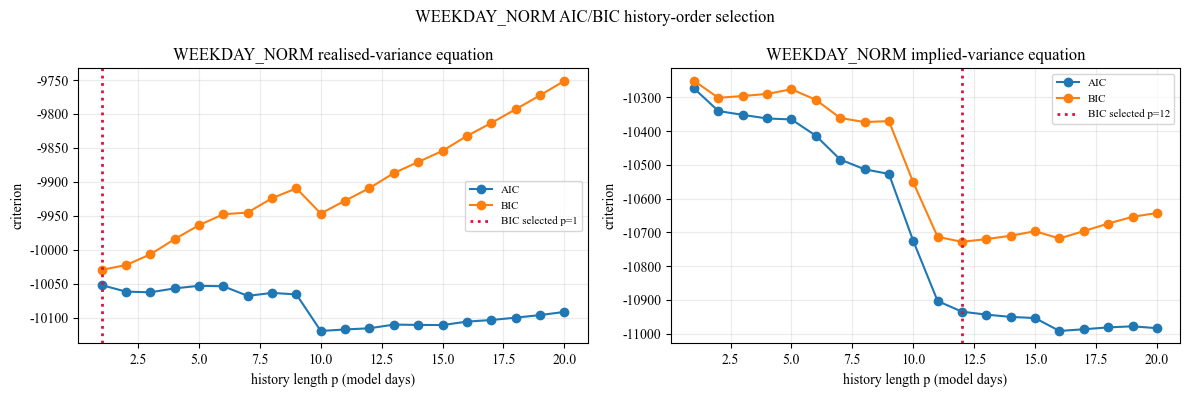

In [69]:
fig,axs=plt.subplots(1,2,figsize=(12,4))
for ax,(target,label,selected) in zip(axs,[('realised_variance_ann_252','realised-variance equation',weekday_norm_n),('implied_variance_ann','implied-variance equation',weekday_norm_m)]):
    d=norm_order_scan[norm_order_scan.target.eq(target)];ax.plot(d.history_order,d.AIC,'o-',label='AIC');ax.plot(d.history_order,d.BIC,'o-',label='BIC');ax.axvline(selected,color='crimson',ls=':',lw=2,label=f'BIC selected p={selected}');ax.set(title=f'WEEKDAY_NORM {label}',xlabel='history length p (model days)',ylabel='criterion');ax.grid(alpha=.25);ax.legend(fontsize=8)
fig.suptitle('WEEKDAY_NORM AIC/BIC history-order selection');fig.tight_layout();plt.show()


## WEEKDAY_NORM selected-order interpretation

The executed training-only AIC/BIC search selects

$$\boxed{n_{\mathrm{NORM}}^*=1,\qquad m_{\mathrm{NORM}}^*=12.}$$

Realised history remains one model day, while implied history falls from RAW order 16 to WEEKDAY_NORM order 12. This cautiously suggests that deterministic weekday structure accounted for part of the RAW history requirement, while substantial implied-variance persistence remains. Order 12 is a history length, not a 12-day causal delay.

In [70]:
norm_gc_compact=norm_gcblocks[['edge_id','split','history_order','classical_F','raw_p_value','holm_adjusted_p_value','holm_reject','partial_R2','HAC_support','retained_for_notebook17']].copy()
display(norm_gc_compact)
norm_retained=norm_gcblocks.loc[norm_gcblocks.retained_for_notebook17,['edge_id']].drop_duplicates().edge_id.str.replace('_to_',' → ').str.replace('_',' ').tolist()


,edge_id,split,history_order,classical_F,raw_p_value,holm_adjusted_p_value,holm_reject,partial_R2,HAC_support,retained_for_notebook17
0,squared_return_to_realised_variance,train,1,9.910784,1.659261e-03,1.659261e-03,True,0.003292,False,False
1,implied_variance_to_realised_variance,train,1,618.180823,3.084728e-124,1.233891e-123,True,0.170807,True,True
2,squared_return_to_implied_variance,train,12,6.634762,8.393768e-12,2.518130e-11,True,0.035095,False,True
3,realised_variance_to_implied_variance,train,12,6.495228,1.704622e-11,3.409244e-11,True,0.034382,False,True
4,squared_return_to_realised_variance,validation,1,3.052035,8.089687e-02,8.089687e-02,False,0.002586,False,False
5,implied_variance_to_realised_variance,validation,1,228.828260,2.252186e-47,9.008744e-47,True,0.162771,True,True
6,squared_return_to_implied_variance,validation,12,3.262608,1.214668e-04,2.429336e-04,True,0.035947,True,True
7,realised_variance_to_implied_variance,validation,12,3.857836,8.400528e-06,2.520158e-05,True,0.042228,True,True
8,squared_return_to_realised_variance,test,1,4.414376,3.584934e-02,7.169868e-02,False,0.003733,False,False
9,implied_variance_to_realised_variance,test,1,295.919561,2.437757e-59,9.751028e-59,True,0.200770,True,True


## Conditional Granger construction: primary WEEKDAY_NORM branch

For target Y and a tested source-history block, the restricted and unrestricted nested regressions are

$$
Y=X_R\beta_R+\varepsilon_R,
$$

$$
Y=X_U\beta_U+\varepsilon_U.
$$

The unrestricted predictor set adds the tested source-history block to the restricted set. The block-zero null is

$$
H_0:\beta_{\mathrm{source},1}=\cdots=\beta_{\mathrm{source},q}=0.
$$

The implementation calculates the nested statistic directly, then verifies agreement with the library comparison:

$$
F=\frac{(RSS_R-RSS_U)/q}{RSS_U/df_U},
$$

$$
p=P(F_{q,df_U}\geq F_{\mathrm{obs}}),
$$

$$
R_{\mathrm{partial}}^2=\frac{RSS_R-RSS_U}{RSS_R}=\frac{qF}{qF+df_U}.
$$

RSS_R and RSS_U are restricted and unrestricted residual sums of squares; q is the number of coefficients in the tested source block; and df_U is the unrestricted residual degrees of freedom. F measures scale-adjusted residual reduction, p measures evidence against the block-zero null, and partial R² measures incremental effect size. A large F can be valid with a large sample and substantial residual reduction; significance alone does not establish economically large predictive content.

### The four primary comparisons

For Q → R and I → R, the common unrestricted realised-variance model is

$$
R_t=c+\beta_1R_{t-1}+\alpha_1Q_{t-1}+\gamma_1I_{t-1}+\varepsilon_t^R.
$$

Q → R removes the Q lag; I → R removes the I lag. Hence q equals 1 for either realised-target test. For Q → I and R → I, the common unrestricted implied-variance model is

$$
I_t=c+\sum_{j=1}^{12}[a_jI_{t-j}+b_jQ_{t-j}+g_jR_{t-j}]+\varepsilon_t^I.
$$

Q → I removes the twelve Q coefficients; R → I removes the twelve R coefficients. Thus q equals 12 for the implied-target tests. The code records source, target, order, predictor lists, q, N, both RSS values, df_U, manual and library F, p-value, partial R², Holm-adjusted p-value, HAC p-value, and retain/drop status.

Within each split, Holm adjusts the four cross-variable GC hypotheses. Final retention is fixed solely by classical conditional GC evidence:

```text
retain = Holm reject in TRAIN AND Holm reject in VALIDATION
```

TEST never selects structure. Newey–West/HAC Wald inference is reported as a robustness diagnostic for residual heteroskedasticity and autocorrelation; it does not replace the frozen classical-GC rule.

### Explicit restricted and unrestricted primary GC comparisons

For Q → R, the restricted baseline is

$$
R_t=c+\beta_1R_{t-1}+\gamma_1I_{t-1}+\varepsilon_t^R,
$$

and the unrestricted model is

$$
R_t=c+\beta_1R_{t-1}+\alpha_1Q_{t-1}+\gamma_1I_{t-1}+\varepsilon_t^R.
$$

Q → R tests whether lagged Q adds incremental linear predictive information after lagged R and I are controlled for. For I → R, the restricted baseline is

$$
R_t=c+\beta_1R_{t-1}+\alpha_1Q_{t-1}+\varepsilon_t^R,
$$

with the same unrestricted realised-variance equation above. I → R therefore tests lagged I conditional on lagged R and Q.

For Q → I, the restricted baseline is

$$
I_t=c+\sum_{j=1}^{12}[a_jI_{t-j}+g_jR_{t-j}]+\varepsilon_t^I,
$$

and the unrestricted model is

$$
I_t=c+\sum_{j=1}^{12}[a_jI_{t-j}+b_jQ_{t-j}+g_jR_{t-j}]+\varepsilon_t^I.
$$

For R → I, the restricted baseline is

$$
I_t=c+\sum_{j=1}^{12}[a_jI_{t-j}+b_jQ_{t-j}]+\varepsilon_t^I,
$$

with the same unrestricted implied-variance equation above. The Q → I null is

$$
b_1=\cdots=b_{12}=0,
$$

and the R → I null is

$$
g_1=\cdots=g_{12}=0.
$$

Thus q equals 1 for realised-target tests and 12 for implied-target tests.

The implied-target Q → I and R → I blocks satisfy the frozen classical conditional-GC TRAIN/VALIDATION retention rule, but their TRAIN HAC inference is weaker. They are therefore specification-sensitive predictive relationships, not universally robust causal effects. HAC remains a robustness diagnostic and does not replace the pre-defined classical retention rule.


C:\Users\Rajiv Nawal\AppData\Local\Temp\ipykernel_35052\133987741.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(holm)


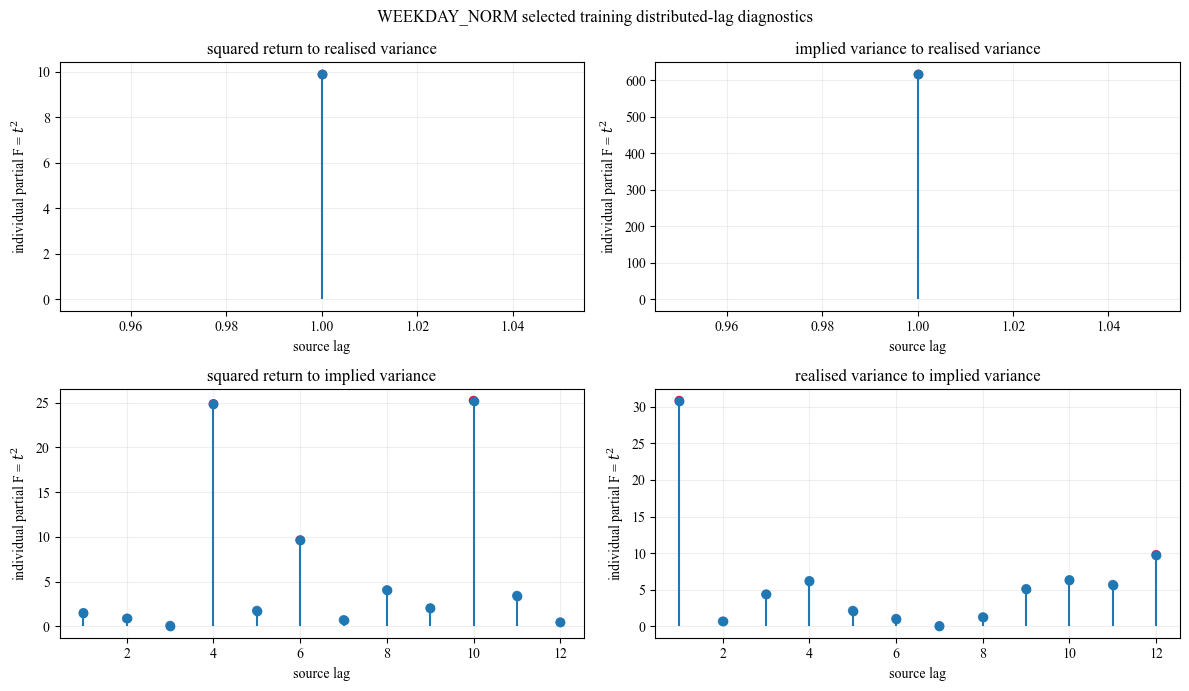

,edge_id,source,target,lag,coefficient,standard_error,t_statistic,partial_F_statistic,raw_p_value,holm_adjusted_p_value,holm_reject
0,squared_return_to_realised_variance,squared_return,realised_variance_ann_252,1,11.452431,3.637841,3.148140,9.910784,1.659261e-03,1.659261e-03,True
1,implied_variance_to_realised_variance,implied_variance_ann,realised_variance_ann_252,1,0.381248,0.015334,24.863242,618.180823,3.084728e-124,3.084728e-124,True
2,squared_return_to_implied_variance,squared_return,implied_variance_ann,1,-4.876813,3.949931,-1.234658,1.524379,2.170905e-01,1.000000e+00,False
3,squared_return_to_implied_variance,squared_return,implied_variance_ann,2,3.797463,4.035026,0.941125,0.885716,3.467447e-01,1.000000e+00,False
4,squared_return_to_implied_variance,squared_return,implied_variance_ann,3,1.282548,4.141854,0.309656,0.095887,7.568523e-01,1.000000e+00,False
5,squared_return_to_implied_variance,squared_return,implied_variance_ann,4,20.665618,4.145421,4.985167,24.851890,6.676774e-07,7.344451e-06,True
6,squared_return_to_implied_variance,squared_return,implied_variance_ann,5,-6.066378,4.556123,-1.331478,1.772834,1.831704e-01,1.000000e+00,False
7,squared_return_to_implied_variance,squared_return,implied_variance_ann,6,-14.106726,4.543185,-3.105030,9.641210,1.926958e-03,1.926958e-02,True
8,squared_return_to_implied_variance,squared_return,implied_variance_ann,7,3.869336,4.546244,0.851106,0.724382,3.948035e-01,1.000000e+00,False
9,squared_return_to_implied_variance,squared_return,implied_variance_ann,8,9.260110,4.589417,2.017709,4.071151,4.374334e-02,3.936900e-01,False


In [71]:
# ============================================================
# WEEKDAY_NORM individual distributed-lag GC diagnostics
# Mirrors RAW Figure 4 using the weekday-normalised IV state
# ============================================================

norm_selected_fit = {}
norm_selected_names = {}

# Refit the selected WEEKDAY_NORM equations on TRAIN so that
# individual lag coefficients / t-statistics can be inspected.
for edge, source, target, p in norm_edge_specs:
    _, fit, names = gc_test(
        weekday_norm,
        target,
        source,
        p,
        "train"
    )
    norm_selected_fit[target] = fit
    norm_selected_names[target] = names


# Collect the individual source-lag diagnostics.
norm_lag_rows = []

for edge, source, target, p in norm_edge_specs:

    fit = norm_selected_fit[target]
    names = norm_selected_names[target]

    # Locate the coefficients belonging to the source block being tested.
    positions = [
        i for i, name in enumerate(names)
        if name in lagcols(source, p)
    ]

    for lag, pos in enumerate(positions, 1):
        norm_lag_rows.append({
            "edge_id": edge,
            "source": source,
            "target": target,
            "lag": lag,
            "coefficient": float(fit.params[pos]),
            "standard_error": float(fit.bse[pos]),
            "t_statistic": float(fit.tvalues[pos]),

            # For one coefficient, partial F = t^2
            "partial_F_statistic": float(fit.tvalues[pos] ** 2),

            "raw_p_value": float(fit.pvalues[pos])
        })


norm_individual = pd.DataFrame(norm_lag_rows)

# Holm correction is applied separately within each source -> target block,
# exactly as in the RAW-IV diagnostics.
norm_individual = (
    norm_individual
    .groupby("edge_id", group_keys=False)
    .apply(holm)
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Plot: equivalent of RAW Figure 4
# ------------------------------------------------------------

fig, axs = plt.subplots(2, 2, figsize=(12, 7))

for ax, (edge, d) in zip(
    axs.flat,
    norm_individual.groupby("edge_id", sort=False)
):
    ax.stem(
        d["lag"],
        d["partial_F_statistic"],
        basefmt=" "
    )

    ax.scatter(
        d["lag"],
        d["partial_F_statistic"],
        c=np.where(
            d["holm_reject"],
            "crimson",
            "steelblue"
        )
    )

    ax.set(
        title=edge.replace("_", " "),
        xlabel="source lag",
        ylabel=r"individual partial F = $t^2$"
    )

    ax.grid(alpha=0.2)


fig.suptitle(
    "WEEKDAY_NORM selected training distributed-lag diagnostics"
)

fig.tight_layout()
plt.show()


# Display the numerical values underneath the figure.
display(norm_individual)

## TDMI mathematics and lag convention

TDMI answers a different, pairwise question from conditional GC. Mutual information is

$$
I(X;Y)=\sum_{x,y}p(x,y)\log\left(\frac{p(x,y)}{p(x)p(y)}\right).
$$

The directional convention used here is

$$
\mathrm{TDMI}_{X\rightarrow Y}(k)=I(X_{t-k};Y_t), \qquad k=1,\ldots,20.
$$

Positive k means the named source precedes the named target. TRAIN-derived quantile-bin edges are frozen; the primary estimator uses 10 bins, positive source-leading lags 1–20, within-split circular-shift source surrogates, and Holm-corrected lag-level p-values. The TRAIN peak is frozen before VALIDATION and TEST. Five- and fifteen-bin versions are sensitivity diagnostics. TDMI remains pairwise, while GC asks whether a source history adds incremental linear predictive information conditional on the other included histories.

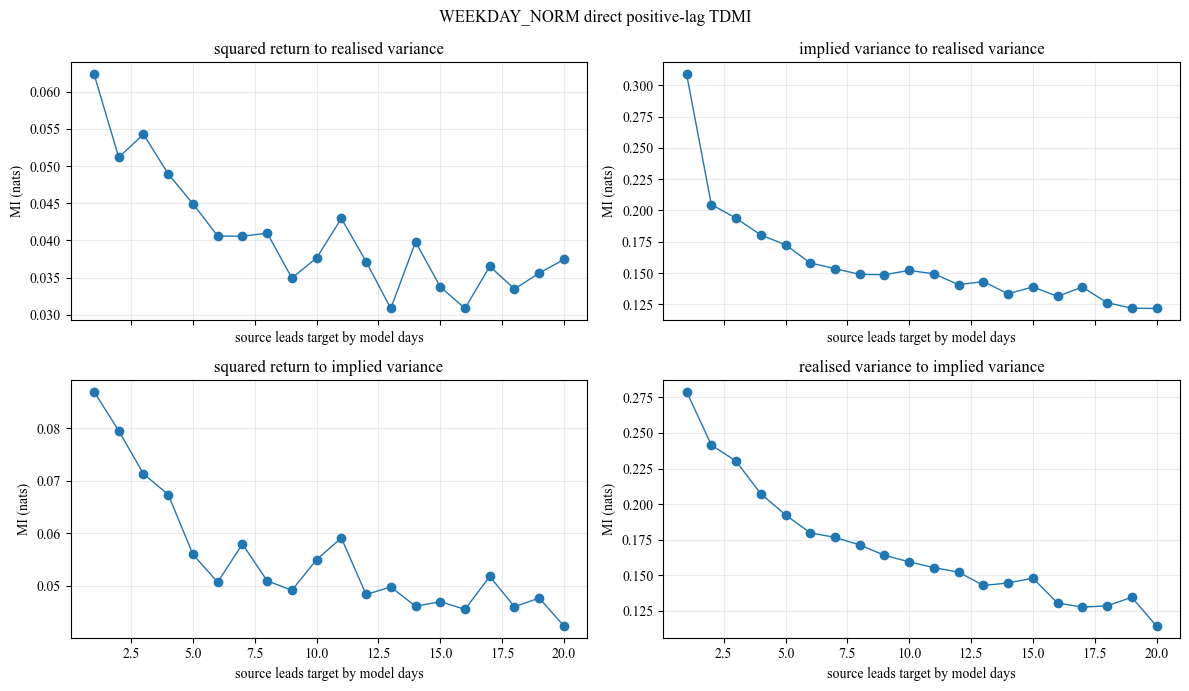

,edge_id,training_tdmi_peak_lag,training_tdmi_value,training_tdmi_holm_p,training_tdmi_support,tdmi_validation_support,tdmi_test_support,tdmi_peak_bin_stability
0,squared_return_to_realised_variance,1,0.062371,0.01998,True,True,True,stable
1,implied_variance_to_realised_variance,1,0.308911,0.01998,True,True,True,stable
2,squared_return_to_implied_variance,1,0.086976,0.01998,True,True,True,stable
3,realised_variance_to_implied_variance,1,0.279067,0.01998,True,True,True,stable


In [72]:
norm_tdmi_specs=[(e,s,t) for e,s,t,_ in norm_edge_specs]
norm_tdmi_parts=[]; norm_tdmi_records=[]; norm_edge_maps={}
for edge,source,target in norm_tdmi_specs:
    curve,edges=tdmi_training_search(weekday_norm,source,target,10,True);norm_tdmi_parts.append(curve.assign(edge_id=edge,bins=10));norm_edge_maps[edge]=edges
    sig=curve[curve.significant.fillna(False)]; peak_row=sig.sort_values('tdmi',ascending=False).iloc[0] if len(sig) else None
    norm_tdmi_records.append({'edge_id':edge,'source':source,'target':target,'training_tdmi_support':bool(len(sig)),'training_tdmi_peak_lag':int(peak_row.lag) if peak_row is not None else np.nan,'training_tdmi_value':float(peak_row.tdmi) if peak_row is not None else np.nan,'training_tdmi_raw_p':float(peak_row.raw_p) if peak_row is not None else np.nan,'training_tdmi_holm_p':float(peak_row.holm_p) if peak_row is not None else np.nan})
norm_tdmi_curves=pd.concat(norm_tdmi_parts,ignore_index=True); assert norm_tdmi_curves.groupby('edge_id').size().eq(MAX_LAG).all()
norm_holdout=[]
for rec in norm_tdmi_records:
    if np.isfinite(rec['training_tdmi_peak_lag']):
        for split in ['validation','test']:
            value,n,pv=surrogate_p(weekday_norm,rec['source'],rec['target'],int(rec['training_tdmi_peak_lag']),split,norm_edge_maps[rec['edge_id']],np.random.default_rng(RANDOM_SEED+500+len(rec['edge_id'])))
            norm_holdout.append({'edge_id':rec['edge_id'],'split':split,'tdmi_value':value,'tdmi_p':pv,'tdmi_support':pv<ALPHA,'n_pairs':n})
norm_holdout=pd.DataFrame(norm_holdout)
norm_tdmi_summary=pd.DataFrame(norm_tdmi_records)
for split in ['validation','test']:
    d=norm_holdout[norm_holdout.split.eq(split)].set_index('edge_id') if len(norm_holdout) else pd.DataFrame()
    norm_tdmi_summary[f'tdmi_{split}_value']=norm_tdmi_summary.edge_id.map(d.tdmi_value if len(d) else {})
    norm_tdmi_summary[f'tdmi_{split}_p']=norm_tdmi_summary.edge_id.map(d.tdmi_p if len(d) else {})
    norm_tdmi_summary[f'tdmi_{split}_support']=norm_tdmi_summary.edge_id.map(d.tdmi_support if len(d) else {}).fillna(False).astype(bool)
# Five- and fifteen-bin curves are descriptive timing checks; ten-bin Holm inference remains primary.
norm_bin_rows=[]
for bins in [5,15]:
    for edge,source,target in norm_tdmi_specs:
        curve,_=tdmi_training_search(weekday_norm,source,target,bins,False); peak=int(curve.sort_values('tdmi',ascending=False).iloc[0].lag)
        norm_bin_rows.append({'edge_id':edge,'bins':bins,'peak_lag':peak})
norm_bin_peaks=pd.DataFrame(norm_bin_rows)
for bins in [5,10,15]:
    lookup=(norm_bin_peaks[norm_bin_peaks.bins.eq(bins)].set_index('edge_id').peak_lag if bins!=10 else norm_tdmi_summary.set_index('edge_id').training_tdmi_peak_lag)
    norm_tdmi_summary[f'tdmi_peak_{bins}_bins']=norm_tdmi_summary.edge_id.map(lookup)
norm_tdmi_summary['tdmi_peak_bin_stability']=norm_tdmi_summary.apply(lambda r: 'stable' if len(set(pd.Series([r.tdmi_peak_5_bins,r.tdmi_peak_10_bins,r.tdmi_peak_15_bins]).dropna()))==1 else 'approximately_stable_or_sensitive',axis=1)
fig,axs=plt.subplots(2,2,figsize=(12,7),sharex=True)
for ax,(edge,d) in zip(axs.flat,norm_tdmi_curves.groupby('edge_id',sort=False)):
    ax.plot(d.lag,d.tdmi,'o-',lw=1);ax.set(title=edge.replace('_to_',' to ').replace('_',' '),xlabel='source leads target by model days',ylabel='MI (nats)');ax.grid(alpha=.25)
fig.suptitle('WEEKDAY_NORM direct positive-lag TDMI');fig.tight_layout();plt.show()
display(norm_tdmi_summary[['edge_id','training_tdmi_peak_lag','training_tdmi_value','training_tdmi_holm_p','training_tdmi_support','tdmi_validation_support','tdmi_test_support','tdmi_peak_bin_stability']])


## WEEKDAY_NORM TDMI interpretation

Normalised peaks are all positive lag 1. The notable change is Q → I, from positive lag 2 to positive lag 1; these are not structural causal delays.

## WEEKDAY_NORM closure-gap robustness

In [73]:
closure_states=['squared_return','realised_variance_with_closure_ann_252','implied_variance_ann']
weekday_norm['_closure_eligible']=weekday_norm.structure_eligible & np.isfinite(weekday_norm.realised_variance_with_closure_ann_252)
norm_closure_specs=[('squared_return_to_realised_variance','squared_return','realised_variance_with_closure_ann_252',weekday_norm_n),('implied_variance_to_realised_variance','implied_variance_ann','realised_variance_with_closure_ann_252',weekday_norm_n),('squared_return_to_implied_variance','squared_return','implied_variance_ann',weekday_norm_m),('realised_variance_to_implied_variance','realised_variance_with_closure_ann_252','implied_variance_ann',weekday_norm_m)]
norm_closure_rows=[]
for edge,source,target,p in norm_closure_specs:
    row,_,_=gc_test(weekday_norm,target,source,p,'train',closure_states);row['edge_id']=edge;norm_closure_rows.append(row)
norm_closure_gc=holm(pd.DataFrame(norm_closure_rows)); norm_closure_gc['HAC_support']=norm_closure_gc.HAC_p<ALPHA
norm_primary_train=norm_gcblocks.query("split=='train'")[['edge_id','holm_reject']].rename(columns={'holm_reject':'primary_classical_support'})
norm_closure_gc=norm_closure_gc.merge(norm_primary_train,on='edge_id');norm_closure_gc['closure_gap_training_robust']=norm_closure_gc.holm_reject.eq(norm_closure_gc.primary_classical_support)


## WEEKDAY_NORM stationarity diagnostics and primary equations

$$\boxed{R_t=\widetilde\phi+\widetilde\beta_1R_{t-1}+\widetilde\gamma_1I_{t-1}^{NORM}+u_t^R}$$

$$\boxed{I_t^{NORM}=\phi+\sum_{j=1}^{12}[\alpha_jQ_{t-j}+\beta_jR_{t-j}+\gamma_jI_{t-j}^{NORM}]+u_t^I}$$

These are the primary equations passed to Notebook 17.

In [74]:
norm_station_rows=[]
for state in STATES:
    idx=np.flatnonzero(weekday_norm.sample_split.eq('train') & np.isfinite(weekday_norm[state])); runs=contiguous_runs(np.isin(np.arange(len(weekday_norm)),idx)); a,b,_=max(runs,key=lambda z:z[2]); x=weekday_norm.loc[a:b,state].to_numpy(float)
    adf_s,adf_p,*_=adfuller(x,regression='c',autolag='AIC')
    with warnings.catch_warnings(): warnings.simplefilter('ignore'); kpss_s,kpss_p,*_=kpss(x,regression='c',nlags='auto')
    status='stationarity_supported' if adf_p<ALPHA and kpss_p>=ALPHA else ('non_unit_root_but_regime_instability' if adf_p<ALPHA and kpss_p<ALPHA else ('unit_root_concern' if adf_p>=ALPHA and kpss_p<ALPHA else 'mixed'))
    norm_station_rows.append({'variable':state,'run_start':weekday_norm.loc[a,'model_day'],'run_end':weekday_norm.loc[b,'model_day'],'n_observations':len(x),'ADF_statistic':adf_s,'ADF_p_value':adf_p,'KPSS_statistic':kpss_s,'KPSS_p_value':kpss_p,'stationarity_interpretation':status})
norm_stationarity=pd.DataFrame(norm_station_rows)
raw_stationarity=stationarity.copy(); raw_stationarity['iv_specification']=RAW_IV_SPECIFICATION; norm_stationarity['iv_specification']=PRIMARY_IV_SPECIFICATION
stationarity_comparison=pd.concat([raw_stationarity,norm_stationarity],ignore_index=True)
print('Stationarity diagnostics rerun for all three states under the weekday-normalised-IV branch; non-IV states are intentionally unchanged.')


Stationarity diagnostics rerun for all three states under the weekday-normalised-IV branch; non-IV states are intentionally unchanged.


# Part C — Direct comparison and final hand-off

,iv_specification,iv_column,selected_n,selected_m,selected_realised_order,selected_implied_order,retain_Q_to_R,retain_I_to_R,retain_Q_to_I,retain_R_to_I,...,gc_alpha,holm_correction,realised_state_definition,implied_state_definition,normalisation_estimation_window,event_unaware,eventless,equation_5_implemented,forecasting_performed,raw_benchmark_orders
0,WEEKDAY_NORM_IV,iv_model_var,1,12,1,12,False,True,True,True,...,0.05,True,252 * rv_within,iv_model_var: squared Bloomberg overnight/1D A...,ALL_TRAIN,True,False,False,False,"n=1, m=16"


,edge_id,retained_train_validation_RAW_IV,retained_train_validation_WEEKDAY_NORM_IV,train_partial_R2_RAW_IV,train_partial_R2_WEEKDAY_NORM_IV,validation_partial_R2_RAW_IV,validation_partial_R2_WEEKDAY_NORM_IV,training_tdmi_peak_lag_RAW_IV,training_tdmi_peak_lag_WEEKDAY_NORM_IV,training_tdmi_support_RAW_IV,training_tdmi_support_WEEKDAY_NORM_IV,tdmi_validation_support_RAW_IV,tdmi_validation_support_WEEKDAY_NORM_IV,tdmi_test_support_RAW_IV,tdmi_test_support_WEEKDAY_NORM_IV,retention_changed,tdmi_peak_changed
0,implied_variance_to_realised_variance,True,True,0.205842,0.170807,0.136029,0.162771,1,1,True,True,True,True,True,True,False,False
1,realised_variance_to_implied_variance,True,True,0.037663,0.034382,0.046068,0.042228,1,1,True,True,True,True,True,True,False,False
2,squared_return_to_implied_variance,True,True,0.057736,0.035095,0.064449,0.035947,2,1,True,True,True,True,True,True,False,True
3,squared_return_to_realised_variance,True,False,0.002148,0.003292,0.008329,0.002586,1,1,True,True,True,True,True,True,True,False


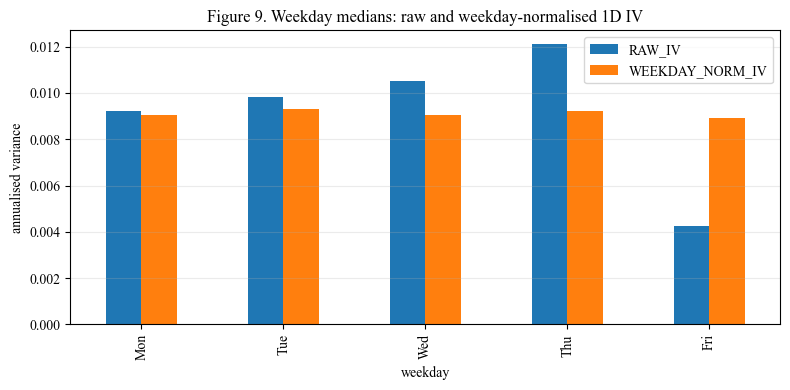

,target,RAW order,WEEKDAY_NORM order,change
0,realised variance,1,1,0
1,implied variance,16,12,-4


,edge_id,retained_train_validation_RAW_IV,retained_train_validation_WEEKDAY_NORM_IV,train_partial_R2_RAW_IV,train_partial_R2_WEEKDAY_NORM_IV,validation_partial_R2_RAW_IV,validation_partial_R2_WEEKDAY_NORM_IV,retention_changed
0,implied_variance_to_realised_variance,True,True,0.205842,0.170807,0.136029,0.162771,False
1,realised_variance_to_implied_variance,True,True,0.037663,0.034382,0.046068,0.042228,False
2,squared_return_to_implied_variance,True,True,0.057736,0.035095,0.064449,0.035947,False
3,squared_return_to_realised_variance,True,False,0.002148,0.003292,0.008329,0.002586,True


,edge_id,training_tdmi_peak_lag_RAW_IV,training_tdmi_peak_lag_WEEKDAY_NORM_IV,training_tdmi_value_RAW_IV,training_tdmi_value_WEEKDAY_NORM_IV,training_tdmi_support_RAW_IV,training_tdmi_support_WEEKDAY_NORM_IV
0,implied_variance_to_realised_variance,1,1,0.284269,0.308911,True,True
1,realised_variance_to_implied_variance,1,1,0.207138,0.279067,True,True
2,squared_return_to_implied_variance,2,1,0.067802,0.086976,True,True
3,squared_return_to_realised_variance,1,1,0.062371,0.062371,True,True


raw_iv_analysis_completed                                                          True
weekday_norm_iv_analysis_completed                                                 True
raw_selected_n                                                                        1
raw_selected_m                                                                       16
weekday_norm_selected_n                                                               1
weekday_norm_selected_m                                                              12
raw_retained_blocks                   [squared_return_to_realised_variance, implied_...
weekday_norm_retained_blocks          [implied_variance_to_realised_variance, square...
primary_iv_specification                                                WEEKDAY_NORM_IV
primary_iv_column                                                          iv_model_var
event_unaware                                                                      True
eventless                       

NOTEBOOK 16 COMPARATIVE RUN: PASS | primary=WEEKDAY_NORM_IV | raw benchmark reproduced=True | exports=10


In [75]:
raw_orders=order_scan_df.assign(iv_specification=RAW_IV_SPECIFICATION); norm_orders=norm_order_scan.assign(iv_specification=PRIMARY_IV_SPECIFICATION)
bic_order_selection_comparison=pd.concat([raw_orders,norm_orders],ignore_index=True)
def tidy_gc(blocks,spec):
    d=blocks.pivot(index='edge_id',columns='split',values=['raw_p_value','holm_adjusted_p_value','holm_reject','partial_R2','HAC_support']).reset_index(); d.columns=['edge_id']+[f'{b}_{a}' for a,b in d.columns[1:]]
    d['iv_specification']=spec;d['retained_train_validation']=d.train_holm_reject & d.validation_holm_reject;return d
gc_results_raw_vs_weekday_norm=pd.concat([tidy_gc(gcblocks,RAW_IV_SPECIFICATION),tidy_gc(norm_gcblocks,PRIMARY_IV_SPECIFICATION)],ignore_index=True)
tdmi_results_raw_vs_weekday_norm=pd.concat([tdmi_summary.assign(iv_specification=RAW_IV_SPECIFICATION),norm_tdmi_summary.assign(iv_specification=PRIMARY_IV_SPECIFICATION)],ignore_index=True)
closure_gap_raw_vs_weekday_norm=pd.concat([closure_gc.assign(iv_specification=RAW_IV_SPECIFICATION),norm_closure_gc.assign(iv_specification=PRIMARY_IV_SPECIFICATION)],ignore_index=True)
gc_wide=gc_results_raw_vs_weekday_norm.pivot(index='edge_id',columns='iv_specification',values=['retained_train_validation','train_partial_R2','validation_partial_R2']).reset_index();gc_wide.columns=['edge_id']+[f'{a}_{b}' for a,b in gc_wide.columns[1:]]
tdmi_wide=tdmi_results_raw_vs_weekday_norm.pivot(index='edge_id',columns='iv_specification',values=['training_tdmi_peak_lag','training_tdmi_support','tdmi_validation_support','tdmi_test_support']).reset_index();tdmi_wide.columns=['edge_id']+[f'{a}_{b}' for a,b in tdmi_wide.columns[1:]]
dependence_structure_comparison=gc_wide.merge(tdmi_wide,on='edge_id',how='outer')
dependence_structure_comparison['retention_changed']=dependence_structure_comparison[f'retained_train_validation_{RAW_IV_SPECIFICATION}'].ne(dependence_structure_comparison[f'retained_train_validation_{PRIMARY_IV_SPECIFICATION}'])
dependence_structure_comparison['tdmi_peak_changed']=dependence_structure_comparison[f'training_tdmi_peak_lag_{RAW_IV_SPECIFICATION}'].ne(dependence_structure_comparison[f'training_tdmi_peak_lag_{PRIMARY_IV_SPECIFICATION}'])
norm_retention=norm_gcblocks.groupby('edge_id').retained_for_notebook17.first().to_dict()
primary_specification=pd.DataFrame([{'iv_specification':PRIMARY_IV_SPECIFICATION,'iv_column':PRIMARY_IV_COLUMN,'selected_n':weekday_norm_n,'selected_m':weekday_norm_m,'selected_realised_order':weekday_norm_n,'selected_implied_order':weekday_norm_m,'retain_Q_to_R':bool(norm_retention['squared_return_to_realised_variance']),'retain_I_to_R':bool(norm_retention['implied_variance_to_realised_variance']),'retain_Q_to_I':bool(norm_retention['squared_return_to_implied_variance']),'retain_R_to_I':bool(norm_retention['realised_variance_to_implied_variance']),'lag_convention':'positive source-leading-target model-day lags','bic_candidate_range':'1..20','gc_alpha':ALPHA,'holm_correction':True,'realised_state_definition':'252 * rv_within','implied_state_definition':'iv_model_var: squared Bloomberg overnight/1D ATM IV after frozen weekday normalisation','normalisation_estimation_window':'ALL_TRAIN','event_unaware':True,'eventless':False,'equation_5_implemented':False,'forecasting_performed':False,'raw_benchmark_orders':f'n={raw_selected_n}, m={raw_selected_m}'}])
display(primary_specification);display(dependence_structure_comparison)
fig,ax=plt.subplots(figsize=(8,4)); med=panel.assign(weekday=panel.model_day.dt.day_name().str[:3]).groupby('weekday')[['iv_ann_var','iv_model_var']].median().reindex(['Mon','Tue','Wed','Thu','Fri']);med.plot(kind='bar',ax=ax);ax.set(title='Figure 9. Weekday medians: raw and weekday-normalised 1D IV',xlabel='weekday',ylabel='annualised variance');ax.legend(['RAW_IV','WEEKDAY_NORM_IV']);ax.grid(axis='y',alpha=.25);fig.tight_layout();plt.show()
order_comparison=pd.DataFrame([{'target':'realised variance','RAW order':raw_selected_n,'WEEKDAY_NORM order':weekday_norm_n,'change':weekday_norm_n-raw_selected_n},{'target':'implied variance','RAW order':raw_selected_m,'WEEKDAY_NORM order':weekday_norm_m,'change':weekday_norm_m-raw_selected_m}])
gc_comparison_compact=dependence_structure_comparison[['edge_id',f'retained_train_validation_{RAW_IV_SPECIFICATION}',f'retained_train_validation_{PRIMARY_IV_SPECIFICATION}',f'train_partial_R2_{RAW_IV_SPECIFICATION}',f'train_partial_R2_{PRIMARY_IV_SPECIFICATION}',f'validation_partial_R2_{RAW_IV_SPECIFICATION}',f'validation_partial_R2_{PRIMARY_IV_SPECIFICATION}','retention_changed']].copy()
tdmi_comparison_compact=tdmi_results_raw_vs_weekday_norm.pivot(index='edge_id',columns='iv_specification',values=['training_tdmi_peak_lag','training_tdmi_value','training_tdmi_support']).reset_index();tdmi_comparison_compact.columns=['edge_id']+[f'{a}_{b}' for a,b in tdmi_comparison_compact.columns[1:]]
display(order_comparison);display(gc_comparison_compact);display(tdmi_comparison_compact)
comparative_exports={'16_bic_order_selection_comparison.csv':bic_order_selection_comparison,'16_order_selection_raw_vs_weekday_norm.csv':bic_order_selection_comparison,'16_gc_results_raw_vs_weekday_norm.csv':gc_results_raw_vs_weekday_norm,'16_tdmi_results_raw_vs_weekday_norm.csv':tdmi_results_raw_vs_weekday_norm,'16_dependence_structure_comparison.csv':dependence_structure_comparison,'16_primary_specification.csv':primary_specification,'16_model_specification.csv':primary_specification,'16_stationarity_raw_vs_weekday_norm.csv':stationarity_comparison,'16_closure_gap_raw_vs_weekday_norm.csv':closure_gap_raw_vs_weekday_norm,'16_tdmi_raw_vs_weekday_norm.csv':pd.concat([tdmi_curves.assign(iv_specification=RAW_IV_SPECIFICATION),norm_tdmi_curves.assign(iv_specification=PRIMARY_IV_SPECIFICATION)],ignore_index=True)}
for name,frame in comparative_exports.items():
    out=frame.copy();out.insert(0,'RUN_ID',RUN_ID);out.to_csv(PROCESSED_DIR/name,index=False);assert len(pd.read_csv(PROCESSED_DIR/name))==len(out)
assert primary_specification.iv_specification.iloc[0]==PRIMARY_IV_SPECIFICATION and primary_specification.event_unaware.iloc[0] and not primary_specification.eventless.iloc[0]
assert all((pd.read_csv(PROCESSED_DIR/name).RUN_ID==RUN_ID).all() for name in comparative_exports)
# Unambiguous output contract: explicitly retain RAW evidence, but make every generic file primary or clearly two-specification.
def contract_frame(frame, specification, column, benchmark):
    out=frame.copy();out['iv_specification']=specification;out['iv_column']=column;out['benchmark_only']=benchmark;out['primary_specification']=not benchmark;return out
raw_system=contract_frame(system_specification,RAW_IV_SPECIFICATION,'iv_ann_var',True)
primary_system=contract_frame(pd.DataFrame([{'equation':'realised_variance','target':'realised_variance_ann_252','selected_order':weekday_norm_n,'retained_predictor_blocks':'I_to_R'},{'equation':'implied_variance','target':'implied_variance_ann','selected_order':weekday_norm_m,'retained_predictor_blocks':'Q_to_I; R_to_I'}]),PRIMARY_IV_SPECIFICATION,PRIMARY_IV_COLUMN,False)
raw_target=contract_frame(target_summary,RAW_IV_SPECIFICATION,'iv_ann_var',True)
norm_target=contract_frame(pd.DataFrame([{'target':'realised_variance_ann_252','selected_history_order':weekday_norm_n,'retained_predictor_blocks':'I_to_R'},{'target':'implied_variance_ann','selected_history_order':weekday_norm_m,'retained_predictor_blocks':'Q_to_I; R_to_I'}]),PRIMARY_IV_SPECIFICATION,PRIMARY_IV_COLUMN,False)
raw_gc_detail=contract_frame(pd.concat([gcblocks.assign(test_type='cross_variable'),ownblocks.assign(test_type='own_history')],ignore_index=True),RAW_IV_SPECIFICATION,'iv_ann_var',True)
norm_gc_detail=contract_frame(norm_gcblocks.assign(test_type='cross_variable'),PRIMARY_IV_SPECIFICATION,PRIMARY_IV_COLUMN,False)
primary_panel=panel.assign(date=panel.model_day,iv_raw_var=panel.iv_ann_var,iv_model_var=panel.iv_model_var,primary_iv_specification=PRIMARY_IV_SPECIFICATION)[['date','model_day','sample_split','structure_eligible','squared_return','realised_variance_ann_252','iv_raw_var','iv_ann_var','iv_model_var','iv_weekday_norm_var','realised_variance_with_closure_ann_252']]
raw_individual=contract_frame(individual,RAW_IV_SPECIFICATION,'iv_ann_var',True);raw_residuals=contract_frame(residuals,RAW_IV_SPECIFICATION,'iv_ann_var',True);raw_sensitivity=contract_frame(sensitivity,RAW_IV_SPECIFICATION,'iv_ann_var',True);common_spot=contract_frame(spot_diagnostics,'COMMON_Q_R',None,False)
contract_exports={'16_system_specification_raw.csv':raw_system,'16_system_specification.csv':primary_system,'16_target_model_summary_raw.csv':raw_target,'16_target_model_summary.csv':pd.concat([raw_target,norm_target],ignore_index=True,sort=False),'16_gc_block_tests_raw.csv':raw_gc_detail,'16_gc_block_tests.csv':pd.concat([raw_gc_detail,norm_gc_detail],ignore_index=True,sort=False),'16_empirical_analysis_panel.csv':primary_panel,'16_gc_order_scan.csv':pd.concat([contract_frame(order_scan_df,RAW_IV_SPECIFICATION,'iv_ann_var',True),contract_frame(norm_order_scan,PRIMARY_IV_SPECIFICATION,PRIMARY_IV_COLUMN,False)],ignore_index=True),'16_tdmi_summary.csv':pd.concat([contract_frame(tdmi_summary,RAW_IV_SPECIFICATION,'iv_ann_var',True),contract_frame(norm_tdmi_summary,PRIMARY_IV_SPECIFICATION,PRIMARY_IV_COLUMN,False)],ignore_index=True,sort=False),'16_tdmi_curves.csv':pd.concat([contract_frame(tdmi_curves,RAW_IV_SPECIFICATION,'iv_ann_var',True),contract_frame(norm_tdmi_curves,PRIMARY_IV_SPECIFICATION,PRIMARY_IV_COLUMN,False)],ignore_index=True,sort=False),'16_stationarity_diagnostics.csv':stationarity_comparison,'16_closure_gap_sensitivity.csv':closure_gap_raw_vs_weekday_norm,'16_gc_individual_lag_diagnostics_raw.csv':raw_individual,'16_gc_individual_lag_diagnostics.csv':raw_individual,'16_residual_diagnostics_raw.csv':raw_residuals,'16_residual_diagnostics.csv':raw_residuals,'16_sensitivity_summary_raw.csv':raw_sensitivity,'16_sensitivity_summary.csv':raw_sensitivity,'16_spot_return_equation_diagnostics.csv':common_spot}
for name,frame in contract_exports.items():
    out=frame.copy();out.insert(0,'RUN_ID',RUN_ID);out.to_csv(PROCESSED_DIR/name,index=False)
primary_disk=pd.read_csv(PROCESSED_DIR/'16_primary_specification.csv').iloc[0];system_disk=pd.read_csv(PROCESSED_DIR/'16_system_specification.csv')
assert primary_disk.iv_specification==PRIMARY_IV_SPECIFICATION and primary_disk.iv_column==PRIMARY_IV_COLUMN
assert int(primary_disk.selected_realised_order)==weekday_norm_n and int(primary_disk.selected_implied_order)==weekday_norm_m
assert bool(primary_disk.retain_Q_to_R)==bool(norm_retention['squared_return_to_realised_variance']) and bool(primary_disk.retain_I_to_R)==bool(norm_retention['implied_variance_to_realised_variance']) and bool(primary_disk.retain_Q_to_I)==bool(norm_retention['squared_return_to_implied_variance']) and bool(primary_disk.retain_R_to_I)==bool(norm_retention['realised_variance_to_implied_variance'] )
assert set(system_disk.iv_specification)=={PRIMARY_IV_SPECIFICATION} and set(system_disk.iv_column)=={PRIMARY_IV_COLUMN}
assert {'iv_raw_var','iv_ann_var','iv_model_var','sample_split','structure_eligible'}.issubset(pd.read_csv(PROCESSED_DIR/'16_empirical_analysis_panel.csv').columns)
output_contract_unambiguous=True
machine_status={'raw_iv_analysis_completed':True,'weekday_norm_iv_analysis_completed':True,'raw_selected_n':raw_selected_n,'raw_selected_m':raw_selected_m,'weekday_norm_selected_n':weekday_norm_n,'weekday_norm_selected_m':weekday_norm_m,'raw_retained_blocks':gcblocks.loc[gcblocks.retained_for_notebook17,'edge_id'].drop_duplicates().tolist(),'weekday_norm_retained_blocks':norm_gcblocks.loc[norm_gcblocks.retained_for_notebook17,'edge_id'].drop_duplicates().tolist(),'primary_iv_specification':PRIMARY_IV_SPECIFICATION,'primary_iv_column':PRIMARY_IV_COLUMN,'event_unaware':True,'eventless':False,'output_contract_unambiguous':output_contract_unambiguous,'notebook_16_ready_to_freeze':output_contract_unambiguous,'notebook_17_requires_rerun':False}
display(pd.Series(machine_status,name='Notebook 16 final status'))
print(f'NOTEBOOK 16 COMPARATIVE RUN: PASS | primary={PRIMARY_IV_SPECIFICATION} | raw benchmark reproduced={raw_benchmark_reproduced} | exports={len(comparative_exports)}')


## Authoritative primary hand-off

`16_primary_specification.csv` is authoritative. Notebook 17 must consume `iv_model_var`, realised-history order 1, implied-history order 12, and the retained I → R, Q → I, and R → I blocks. RAW outputs remain labelled benchmarks.

# Part D — Methodological audit: primary WEEKDAY_NORM specification

The following audit is deliberately explicit. The primary conditional-GC derivation above defines the restricted and unrestricted equations, block-zero null, nested F statistic, p-value, and partial R² identity used by the code.

Granger causality here asks whether adding the past of one variable materially improves linear prediction of the target after the histories already present in the equation are controlled for. It is a predictive/Granger relation, not a structural causal effect. A large F is not automatically a bug; an extremely small tail probability may underflow in display; and statistical significance is not economic importance, hence the accompanying partial R².

Most importantly, the contemporaneous Q–R relationship differs from whether lagged Q adds incremental predictive information for future R after past R and I are controlled for. Block GC determines whether a source history provides incremental predictive information. Individual-lag diagnostics indicate where within that history the fitted linear signal is concentrated. TDMI is instead a pairwise nonlinear delayed-dependence diagnostic.

## Part D1 — Restricted versus unrestricted GC model table

This table exposes the exact nested-comparison ingredients: source and target, selected order, restricted and unrestricted predictor histories, q, sample size, RSS values, degrees of freedom, manual and library F statistics, p-values, partial R², Holm adjustment, HAC robustness, and frozen retain/drop status.


In [76]:
# Part D1 — Restricted versus unrestricted GC model table.
# Run after Parts A-C; this audit works only with the primary WEEKDAY_NORM branch.
PRIMARY_GC=norm_gcblocks.copy(); PRIMARY_GC['iv_specification']=PRIMARY_IV_SPECIFICATION
assert PRIMARY_GC.same_row_index.all() and np.allclose(PRIMARY_GC.F_manual,PRIMARY_GC.F_library,rtol=1e-10,atol=1e-10)
assert np.allclose(PRIMARY_GC.partial_R2,PRIMARY_GC.partial_R2_identity,rtol=1e-10,atol=1e-12)
assert PRIMARY_GC.groupby(['target','split']).n_observations.nunique().eq(1).all(), 'Both source blocks for a target must share the selected-order sample.'

short={'squared_return':'Q','realised_variance_ann_252':'R','implied_variance_ann':'I'}
primary_comparisons=PRIMARY_GC.copy()
primary_comparisons['source_label']=primary_comparisons.source.map(short); primary_comparisons['target_label']=primary_comparisons.target.map(short)
primary_comparisons['retain_flag']=primary_comparisons.retained_for_notebook17
primary_comparisons['selection_role']=np.where(primary_comparisons.split.eq('test'),'NOT USED FOR SELECTION','TRAIN/VALIDATION SELECTION EVIDENCE')
model_cols=['source_label','target_label','source','target','split','lag_order','restricted_predictors','unrestricted_predictors','restrictions_q','n_observations','unrestricted_parameter_count','df_unrestricted','same_row_index','rss_restricted','rss_unrestricted','F_manual','F_library','p_value','log10_p_value','p_underflow_flag','p_display','partial_R2','holm_adjusted_p_value','holm_reject','HAC_Wald_stat','HAC_p','retain_flag','selection_role']
gc_model_comparisons=primary_comparisons[model_cols].rename(columns={'holm_adjusted_p_value':'holm_p_value'})
display(gc_model_comparisons.loc[gc_model_comparisons['split'].eq('train'), ['source_label','target_label','lag_order','restricted_predictors','unrestricted_predictors','F_manual','p_value','partial_R2','holm_p_value','HAC_p','retain_flag']])


,source_label,target_label,lag_order,restricted_predictors,unrestricted_predictors,F_manual,p_value,partial_R2,holm_p_value,HAC_p,retain_flag
0,Q,R,1,realised_variance_ann_252 + implied_variance_a...,squared_return + realised_variance_ann_252 + i...,9.910784,1.659261e-03,0.003292,1.659261e-03,6.149383e-02,False
1,I,R,1,squared_return + realised_variance_ann_252 his...,squared_return + realised_variance_ann_252 + i...,618.180823,3.084728e-124,0.170807,1.233891e-123,8.805200e-12,True
2,Q,I,12,realised_variance_ann_252 + implied_variance_a...,squared_return + realised_variance_ann_252 + i...,6.634762,8.393768e-12,0.035095,2.518130e-11,7.039994e-01,True
3,R,I,12,squared_return + implied_variance_ann histories,squared_return + realised_variance_ann_252 + i...,6.495228,1.704622e-11,0.034382,3.409244e-11,8.496388e-01,True


## Part D2 — Large-F reconstruction and audit

The large primary TRAIN statistic is I → R, not Q → R. The audit independently checks identical restricted/unrestricted rows, both RSS values, q, unrestricted residual degrees of freedom, full rank, non-identical source and target, duplicate rows, and the manual-F and partial-R² identities. Its conclusion is descriptive: a very small finite tail probability and a large F can be valid evidence of a large incremental predictive effect.


In [77]:
# The suspicious large-F register covers every executed empirical branch, but does not let RAW_IV alter the primary decision.
all_gc=pd.concat([gcblocks.assign(iv_specification=RAW_IV_SPECIFICATION),PRIMARY_GC],ignore_index=True,sort=False)
gc_large_f_audit=all_gc.loc[all_gc.classical_F.gt(100)].copy()
gc_large_f_audit['source_label']=gc_large_f_audit.source.map(short); gc_large_f_audit['target_label']=gc_large_f_audit.target.map(short)
gc_large_f_audit['duplicate_model_day_rows']=panel.model_day.duplicated().sum()
gc_large_f_audit['duplicate_dataframe_rows']=panel.duplicated().sum()
gc_large_f_audit['source_equals_target']=gc_large_f_audit.source.eq(gc_large_f_audit.target)
gc_large_f_audit['lag_columns_only']=True
gc_large_f_audit['large_F_status']=np.where((np.allclose(gc_large_f_audit.F_manual,gc_large_f_audit.F_library,rtol=1e-10,atol=1e-10))&(gc_large_f_audit.unrestricted_rank.eq(gc_large_f_audit.unrestricted_parameter_count))&(~gc_large_f_audit.source_equals_target),'VALID_LARGE_INCREMENTAL_EFFECT','UNRESOLVED')
assert not gc_large_f_audit.empty and gc_large_f_audit.large_F_status.eq('VALID_LARGE_INCREMENTAL_EFFECT').all()
display(gc_large_f_audit)


,split,target,source,history_order,lag_order,n_observations,comparison_sample,same_row_index,restricted_predictors,unrestricted_predictors,...,HAC_support,retained_for_notebook17,iv_specification,source_label,target_label,duplicate_model_day_rows,duplicate_dataframe_rows,source_equals_target,lag_columns_only,large_F_status
1,train,realised_variance_ann_252,implied_variance_ann,1,1,3005,selected_order_specific,True,squared_return + realised_variance_ann_252 his...,squared_return + realised_variance_ann_252 + i...,...,True,True,RAW_IV,I,R,0,0,False,True,VALID_LARGE_INCREMENTAL_EFFECT
5,validation,realised_variance_ann_252,implied_variance_ann,1,1,1181,selected_order_specific,True,squared_return + realised_variance_ann_252 his...,squared_return + realised_variance_ann_252 + i...,...,True,True,RAW_IV,I,R,0,0,False,True,VALID_LARGE_INCREMENTAL_EFFECT
9,test,realised_variance_ann_252,implied_variance_ann,1,1,1182,selected_order_specific,True,squared_return + realised_variance_ann_252 his...,squared_return + realised_variance_ann_252 + i...,...,True,True,RAW_IV,I,R,0,0,False,True,VALID_LARGE_INCREMENTAL_EFFECT
13,train,realised_variance_ann_252,implied_variance_ann,1,1,3005,selected_order_specific,True,squared_return + realised_variance_ann_252 his...,squared_return + realised_variance_ann_252 + i...,...,True,True,WEEKDAY_NORM_IV,I,R,0,0,False,True,VALID_LARGE_INCREMENTAL_EFFECT
17,validation,realised_variance_ann_252,implied_variance_ann,1,1,1181,selected_order_specific,True,squared_return + realised_variance_ann_252 his...,squared_return + realised_variance_ann_252 + i...,...,True,True,WEEKDAY_NORM_IV,I,R,0,0,False,True,VALID_LARGE_INCREMENTAL_EFFECT
21,test,realised_variance_ann_252,implied_variance_ann,1,1,1182,selected_order_specific,True,squared_return + realised_variance_ann_252 his...,squared_return + realised_variance_ann_252 + i...,...,True,True,WEEKDAY_NORM_IV,I,R,0,0,False,True,VALID_LARGE_INCREMENTAL_EFFECT


## Part D3 — Q and R contemporaneous-versus-lagged sanity check

Q and R are contemporaneously related because both are derived from the same model-day price path. That is not the GC question. The GC comparison asks whether lagged Q adds stable incremental linear predictive information for future R after lagged R and I are controlled for. The executed TRAIN effect is small in partial-R² terms, and the frozen VALIDATION result does not survive the rule; Q → R is therefore dropped without suggesting that Q and R are unrelated.


In [78]:
# Q-to-R sanity audit: association today is reported separately from incremental lagged prediction.
q_sanity=[]
for split in ['train','validation']:
    contemporaneous=weekday_norm.loc[weekday_norm.sample_split.eq(split),['squared_return','realised_variance_ann_252']].dropna()
    qlag=weekday_norm.squared_return.shift(1); lagged=weekday_norm.loc[weekday_norm.sample_split.eq(split)&qlag.notna()&weekday_norm.realised_variance_ann_252.notna(),['realised_variance_ann_252']].copy(); lagged['Q_lag1']=qlag.loc[lagged.index]
    block=PRIMARY_GC[(PRIMARY_GC.source.eq('squared_return'))&(PRIMARY_GC.target.eq('realised_variance_ann_252'))&(PRIMARY_GC.split.eq(split))].iloc[0]
    fitted=norm_selected_fit['realised_variance_ann_252'] if split=='train' else gc_test(weekday_norm,'realised_variance_ann_252','squared_return',weekday_norm_n,split)[1]
    names=norm_selected_names['realised_variance_ann_252'] if split=='train' else gc_test(weekday_norm,'realised_variance_ann_252','squared_return',weekday_norm_n,split)[2]
    qpos=[i for i,name in enumerate(names) if name.startswith('squared_return_lag')]
    q_sanity.append({'split':split,'pearson_Qt_Rt':float(stats.pearsonr(contemporaneous.squared_return,contemporaneous.realised_variance_ann_252).statistic),'spearman_Qt_Rt':float(stats.spearmanr(contemporaneous.squared_return,contemporaneous.realised_variance_ann_252).statistic),'pearson_Qtminus1_Rt':float(stats.pearsonr(lagged.Q_lag1,lagged.realised_variance_ann_252).statistic),'gc_F':block.F_manual,'gc_p_value':block.p_value,'gc_holm_p_value':block.holm_adjusted_p_value,'gc_partial_R2':block.partial_R2,'gc_hac_p':block.HAC_p,'gc_retain':bool(block.retained_for_notebook17),'Q_block_coefficients':'; '.join(f'{names[i]}={fitted.params[i]:.8g} (p={fitted.pvalues[i]:.4g})' for i in qpos)})
q_to_r_sanity_audit=pd.DataFrame(q_sanity)
Q_TO_R_DECISION='RETAIN' if bool(PRIMARY_GC[(PRIMARY_GC.source.eq('squared_return'))&(PRIMARY_GC.target.eq('realised_variance_ann_252'))].retained_for_notebook17.iloc[0]) else 'DROP'
display(q_to_r_sanity_audit)


,split,pearson_Qt_Rt,spearman_Qt_Rt,pearson_Qtminus1_Rt,gc_F,gc_p_value,gc_holm_p_value,gc_partial_R2,gc_hac_p,gc_retain,Q_block_coefficients
0,train,0.625023,0.534407,0.289822,9.910784,0.001659,0.001659,0.003292,0.061494,False,squared_return_lag1=11.452431 (p=0.001659)
1,validation,0.568650,0.441412,0.388195,3.052035,0.080897,0.080897,0.002586,0.566117,False,squared_return_lag1=7.1937857 (p=0.0809)


## Part D4 — Source × target predictive matrix

Rows are possible source histories Q, R, and I; columns are the two operational volatility targets R and I. Q is deliberately not a target. Off-diagonal cells are TRAIN block-GC evidence and show F, Holm-adjusted p-value, partial R², retain/drop status, and target order. The diagonal is labelled OWN HISTORY / PERSISTENCE rather than a GC relationship.


,source,target,cell_label,block_F,holm_p_value,partial_R2,retain_drop,target_lag_order
0,Q,R,F=9.91; Holm p=0.00166; partial R2=0.00329; DROP,9.910784,1.659261e-03,0.003292,DROP,1
1,Q,I,F=6.63; Holm p=2.52e-11; partial R2=0.0351; RE...,6.634762,2.518130e-11,0.035095,RETAIN,12
2,R,R,OWN HISTORY / PERSISTENCE,NaN,NaN,NaN,OWN HISTORY / PERSISTENCE,1
3,R,I,F=6.5; Holm p=3.41e-11; partial R2=0.0344; RETAIN,6.495228,3.409244e-11,0.034382,RETAIN,12
4,I,R,F=618; Holm p=1.23e-123; partial R2=0.171; RETAIN,618.180823,1.233891e-123,0.170807,RETAIN,1
5,I,I,OWN HISTORY / PERSISTENCE,NaN,NaN,NaN,OWN HISTORY / PERSISTENCE,12


Saved dissertation figure:
  PDF: c:\Users\Rajiv Nawal\OneDrive\Documents\GITREPOS\HSBC-AN-RN\CODEWORK\Linus' Task Re-Do\plots\dissertation\fig_5_1_empirical_predictive_structure.pdf
  PNG: c:\Users\Rajiv Nawal\OneDrive\Documents\GITREPOS\HSBC-AN-RN\CODEWORK\Linus' Task Re-Do\plots\dissertation\fig_5_1_empirical_predictive_structure.png


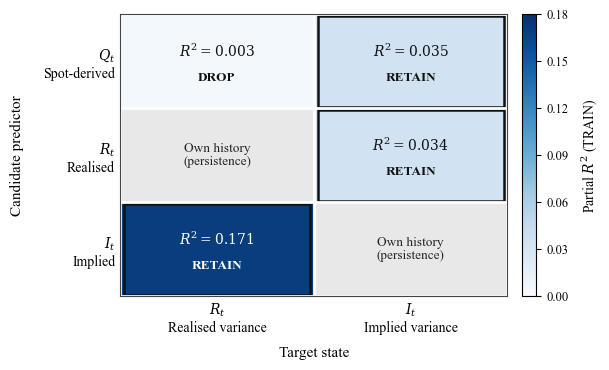

In [79]:
matrix_rows=[]
for source in STATES:
    for target in ['realised_variance_ann_252','implied_variance_ann']:
        if source==target:
            matrix_rows.append({'source':short[source],'target':short[target],'cell_label':'OWN HISTORY / PERSISTENCE','block_F':np.nan,'holm_p_value':np.nan,'partial_R2':np.nan,'retain_drop':'OWN HISTORY / PERSISTENCE','target_lag_order':weekday_norm_n if target=='realised_variance_ann_252' else weekday_norm_m})
        else:
            d=PRIMARY_GC[(PRIMARY_GC.source.eq(source))&(PRIMARY_GC.target.eq(target))&(PRIMARY_GC.split.eq('train'))].iloc[0]
            matrix_rows.append({'source':short[source],'target':short[target],'cell_label':f'F={d.F_manual:.3g}; Holm p={d.holm_adjusted_p_value:.3g}; partial R2={d.partial_R2:.3g}; '+('RETAIN' if d.retained_for_notebook17 else 'DROP'),'block_F':d.F_manual,'holm_p_value':d.holm_adjusted_p_value,'partial_R2':d.partial_R2,'retain_drop':'RETAIN' if d.retained_for_notebook17 else 'DROP','target_lag_order':d.lag_order})
gc_predictive_matrix=pd.DataFrame(matrix_rows)
display(gc_predictive_matrix)

# ------------------------------------------------------------
# Dissertation-quality predictive-structure matrix
# Presentation only: uses the already-computed GC results above.
# ------------------------------------------------------------

# ------------------------------------------------------------
# Dissertation-quality predictive-structure matrix
# Presentation only: uses the already-computed GC results.
# ------------------------------------------------------------

from matplotlib.patches import Rectangle

def show_predictive_matrix(save=True):
    """
    Display the primary TRAIN Granger-predictive structure.

    Colour represents TRAIN partial R^2.
    Retained cross-state relationships are outlined.
    Own-history cells are shown separately as persistence.

    Presentation only:
    no GC statistics or RETAIN/DROP decisions are recomputed.
    """

    sources = ["Q", "R", "I"]
    targets = ["R", "I"]

    # --------------------------------------------------------
    # 1. Build the 3 x 2 matrix from existing D4 results
    # --------------------------------------------------------

    image = np.full((3, 2), np.nan)

    for i, source in enumerate(sources):
        for j, target in enumerate(targets):

            z = gc_predictive_matrix[
                (gc_predictive_matrix["source"] == source)
                & (gc_predictive_matrix["target"] == target)
            ].iloc[0]

            image[i, j] = z["partial_R2"]

    # --------------------------------------------------------
    # 2. Figure setup
    # Sized close to final dissertation text width
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(6.3, 3.8))

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # Clean single-hue sequential palette
    cmap = plt.colormaps["Blues"].copy()

    # Neutral grey for own-history / persistence cells
    cmap.set_bad("#E8E8E8")

    # Fixed scale for a clean, interpretable colour bar
    vmin = 0.0
    vmax = 0.18

    im = ax.imshow(
        np.ma.masked_invalid(image),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
        interpolation="nearest",
    )

    # --------------------------------------------------------
    # 3. Axis labels
    # --------------------------------------------------------

    ax.set_xticks([0, 1])
    ax.set_xticklabels(
        [
            "$R_t$\nRealised variance",
            "$I_t$\nImplied variance",
        ],
        fontsize=10,
    )

    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(
        [
            "$Q_t$\nSpot-derived",
            "$R_t$\nRealised",
            "$I_t$\nImplied",
        ],
        fontsize=10,
    )

    ax.set_xlabel(
        "Target state",
        fontsize=11,
        labelpad=8,
    )

    ax.set_ylabel("Candidate predictor", fontsize=11, labelpad=14)

    # --------------------------------------------------------
    # 4. Separate matrix cells cleanly
    # --------------------------------------------------------

    ax.set_xticks(np.arange(-0.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 3, 1), minor=True)

    ax.grid(
        which="minor",
        color="white",
        linewidth=2.0,
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False,
    )

    ax.tick_params(
        axis="both",
        which="major",
        length=0,
    )

    # --------------------------------------------------------
    # 5. Cell annotations
    #
    # Only partial R^2 and RETAIN/DROP are shown.
    # F-statistics remain available in the underlying D4 table.
    # --------------------------------------------------------

    for i, source in enumerate(sources):
        for j, target in enumerate(targets):

            z = gc_predictive_matrix[
                (gc_predictive_matrix["source"] == source)
                & (gc_predictive_matrix["target"] == target)
            ].iloc[0]

            # Own-history / persistence cell
            if pd.isna(z["partial_R2"]):

                ax.text(
                    j,
                    i,
                    "Own history\n(persistence)",
                    ha="center",
                    va="center",
                    fontsize=9.5,
                    color="#222222",
                )

                continue

            value = float(z["partial_R2"])
            status = str(z["retain_drop"])

            # Dark cells need white text for readability
            text_colour = "white" if value >= 0.09 else "#111111"

            # Partial R^2 value
            ax.text(
                j,
                i - 0.11,
                rf"$R^2={value:.3f}$",
                ha="center",
                va="center",
                fontsize=10,
                color=text_colour,
            )

            # RETAIN / DROP decision
            ax.text(
                j,
                i + 0.18,
                status,
                ha="center",
                va="center",
                fontsize=9.5,
                fontweight="bold",
                color=text_colour,
            )

            # Outline retained cross-state relationships
            if status == "RETAIN":

                ax.add_patch(
                    Rectangle(
                        (j - 0.48, i - 0.48),
                        0.96,
                        0.96,
                        fill=False,
                        edgecolor="#111111",
                        linewidth=1.8,
                    )
                )

    # --------------------------------------------------------
    # 6. Colour bar
    # --------------------------------------------------------

    cbar = fig.colorbar(
        im,
        ax=ax,
        fraction=0.047,
        pad=0.035,
    )

    cbar.set_label(
        r"Partial $R^2$ (TRAIN)",
        fontsize=10,
        labelpad=8,
    )

    cbar.set_ticks(
        [0.00, 0.03, 0.06, 0.09, 0.12, 0.15, 0.18]
    )

    cbar.ax.tick_params(
        labelsize=9
    )

    # --------------------------------------------------------
    # 7. Clean frame
    # --------------------------------------------------------

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_color("#444444")

    # No internal title:
    # the dissertation caption will provide the figure title.
    fig.tight_layout()

    fig.subplots_adjust(left=0.22)

    # --------------------------------------------------------
    # 8. Save thesis-ready copies
    # --------------------------------------------------------

    if save:

        out_dir = PROJECT_DIR / "plots" / "dissertation"
        out_dir.mkdir(parents=True, exist_ok=True)

        pdf_path = (
            out_dir
            / "fig_5_1_empirical_predictive_structure.pdf"
        )

        png_path = (
            out_dir
            / "fig_5_1_empirical_predictive_structure.png"
        )

        fig.savefig(
            pdf_path,
            bbox_inches="tight",
        )

        fig.savefig(
            png_path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )

        print("Saved dissertation figure:")
        print(f"  PDF: {pdf_path}")
        print(f"  PNG: {png_path}")

    plt.show()


show_predictive_matrix()

## Part D5 — Source × target × lag GC diagnostics

The two heatmaps represent the source × target × lag object without an unhelpful 3D surface. For R, the selected order is 1; for I, it is 12. Rows are source histories Q, R, and I; columns are source lags. The block test determines whether an entire source history is retained. Individual coefficients and t statistics only show where within a fitted history the linear contribution is concentrated; they do not replace the block-GC decision.


,source,target,source_variable,target_variable,lag,coefficient,standard_error,t_stat,raw_p,hac_p,sign,selected_target_order,diagnostic_role
0,Q,R,squared_return,realised_variance_ann_252,1,11.452431,3.637841,3.148140,1.659261e-03,6.149383e-02,positive,1,CROSS-VARIABLE DIAGNOSTIC
1,R,R,realised_variance_ann_252,realised_variance_ann_252,1,0.073308,0.022430,3.268253,1.094336e-03,2.584922e-01,positive,1,OWN HISTORY / PERSISTENCE
2,I,R,implied_variance_ann,realised_variance_ann_252,1,0.381248,0.015334,24.863242,3.084728e-124,8.805200e-12,positive,1,CROSS-VARIABLE DIAGNOSTIC
3,Q,I,squared_return,implied_variance_ann,1,-4.876813,3.949931,-1.234658,2.170905e-01,4.947971e-01,negative,12,CROSS-VARIABLE DIAGNOSTIC
4,Q,I,squared_return,implied_variance_ann,2,3.797463,4.035026,0.941125,3.467447e-01,5.977653e-01,positive,12,CROSS-VARIABLE DIAGNOSTIC
5,Q,I,squared_return,implied_variance_ann,3,1.282548,4.141854,0.309656,7.568523e-01,9.287876e-01,positive,12,CROSS-VARIABLE DIAGNOSTIC
6,Q,I,squared_return,implied_variance_ann,4,20.665618,4.145421,4.985167,6.676774e-07,2.380167e-01,positive,12,CROSS-VARIABLE DIAGNOSTIC
7,Q,I,squared_return,implied_variance_ann,5,-6.066378,4.556123,-1.331478,1.831704e-01,2.496129e-01,negative,12,CROSS-VARIABLE DIAGNOSTIC
8,Q,I,squared_return,implied_variance_ann,6,-14.106726,4.543185,-3.105030,1.926958e-03,1.231793e-01,negative,12,CROSS-VARIABLE DIAGNOSTIC
9,Q,I,squared_return,implied_variance_ann,7,3.869336,4.546244,0.851106,3.948035e-01,4.287869e-01,positive,12,CROSS-VARIABLE DIAGNOSTIC


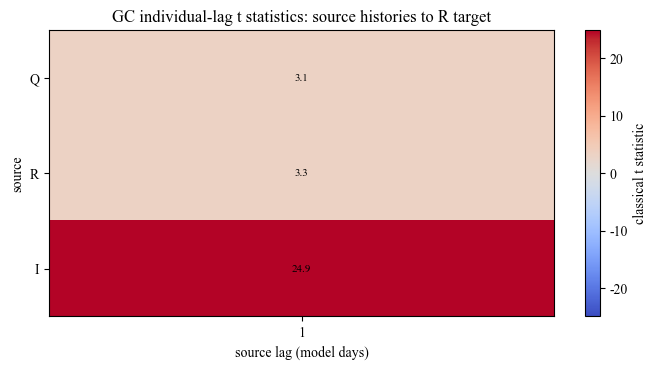

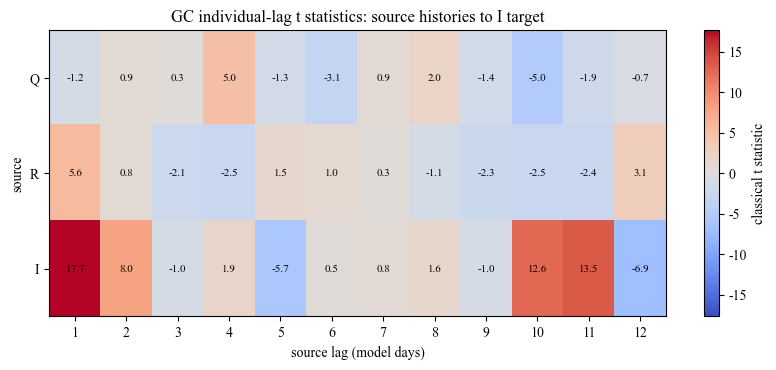

In [80]:
# Individual-lag diagnostics are extracted from the full unrestricted selected-order equation, including own history.
lag_rows=[]
for target,p in [('realised_variance_ann_252',weekday_norm_n),('implied_variance_ann',weekday_norm_m)]:
    fit=norm_selected_fit[target]; names=norm_selected_names[target]; hac=fit.get_robustcov_results(cov_type='HAC',maxlags=max(1,int(np.floor(4*(fit.nobs/100)**(2/9)))))
    for source in STATES:
        for lag,name in enumerate(lagcols(source,p),1):
            pos=names.index(name); lag_rows.append({'source':short[source],'target':short[target],'source_variable':source,'target_variable':target,'lag':lag,'coefficient':float(fit.params[pos]),'standard_error':float(fit.bse[pos]),'t_stat':float(fit.tvalues[pos]),'raw_p':float(fit.pvalues[pos]),'hac_p':float(hac.pvalues[pos]),'sign':'positive' if fit.params[pos]>0 else ('negative' if fit.params[pos]<0 else 'zero'),'selected_target_order':p,'diagnostic_role':'OWN HISTORY / PERSISTENCE' if source==target else 'CROSS-VARIABLE DIAGNOSTIC'})
gc_source_target_lag_diagnostics=pd.DataFrame(lag_rows)
display(gc_source_target_lag_diagnostics)

def show_lag_heatmap(target):
    """Display classical individual-lag t statistics for one canonical target label."""
    d=gc_source_target_lag_diagnostics.loc[gc_source_target_lag_diagnostics['target'].eq(target)].copy()
    if d.empty:
        available=gc_source_target_lag_diagnostics['target'].dropna().unique().tolist()
        raise ValueError(f'No GC lag diagnostics found for target={target!r}. Available targets: {available}')
    p=int(d['selected_target_order'].iloc[0]); image=np.full((3,p),np.nan)
    for i,source in enumerate(['Q','R','I']):
        z=d[d.source.eq(source)].sort_values('lag'); image[i,:len(z)]=z.t_stat.to_numpy()
    fig,ax=plt.subplots(figsize=(max(7,p*.7),3.8)); im=ax.imshow(image,aspect='auto',cmap='coolwarm',vmin=-np.nanmax(np.abs(image)),vmax=np.nanmax(np.abs(image)))
    ax.set(yticks=range(3),yticklabels=['Q','R','I'],xticks=range(p),xticklabels=range(1,p+1),xlabel='source lag (model days)',ylabel='source',title=f'GC individual-lag t statistics: source histories to {target} target')
    for i in range(3):
        for j in range(p):
            if np.isfinite(image[i,j]): ax.text(j,i,f'{image[i,j]:.1f}',ha='center',va='center',fontsize=8)
    fig.colorbar(im,ax=ax,label='classical t statistic'); fig.tight_layout(); plt.show()
show_lag_heatmap('R'); show_lag_heatmap('I')


## Part D6 — TDMI source × target × lag diagnostics

TDMI is pairwise nonlinear delayed-dependence evidence, not a restricted/unrestricted regression. Its reference is the circular-shift surrogate/null distribution. The matrix below records positive source-leading lags, TRAIN-frozen peaks, and the existing significance outputs; it does not alter GC retention.


,source,target,split,lag,bins,mutual_information,n_pairs,surrogate_p,holm_p,significant,edge_id,peak_flag,lag_convention
0,Q,R,train,1,10,0.062371,3319,0.000999,0.019980,True,squared_return_to_realised_variance,True,"positive lag k = source at t-k, target at t"
1,Q,R,train,2,10,0.051158,3316,0.000999,0.019980,True,squared_return_to_realised_variance,False,"positive lag k = source at t-k, target at t"
2,Q,R,train,3,10,0.054276,3312,0.000999,0.019980,True,squared_return_to_realised_variance,False,"positive lag k = source at t-k, target at t"
3,Q,R,train,4,10,0.048927,3308,0.000999,0.019980,True,squared_return_to_realised_variance,False,"positive lag k = source at t-k, target at t"
4,Q,R,train,5,10,0.044919,3309,0.000999,0.019980,True,squared_return_to_realised_variance,False,"positive lag k = source at t-k, target at t"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,R,I,train,16,10,0.130515,3042,0.006993,0.023976,True,realised_variance_to_implied_variance,False,"positive lag k = source at t-k, target at t"
76,R,I,train,17,10,0.127672,3043,0.008991,0.023976,True,realised_variance_to_implied_variance,False,"positive lag k = source at t-k, target at t"
77,R,I,train,18,10,0.128557,3045,0.005994,0.023976,True,realised_variance_to_implied_variance,False,"positive lag k = source at t-k, target at t"
78,R,I,train,19,10,0.134599,3045,0.003996,0.019980,True,realised_variance_to_implied_variance,False,"positive lag k = source at t-k, target at t"


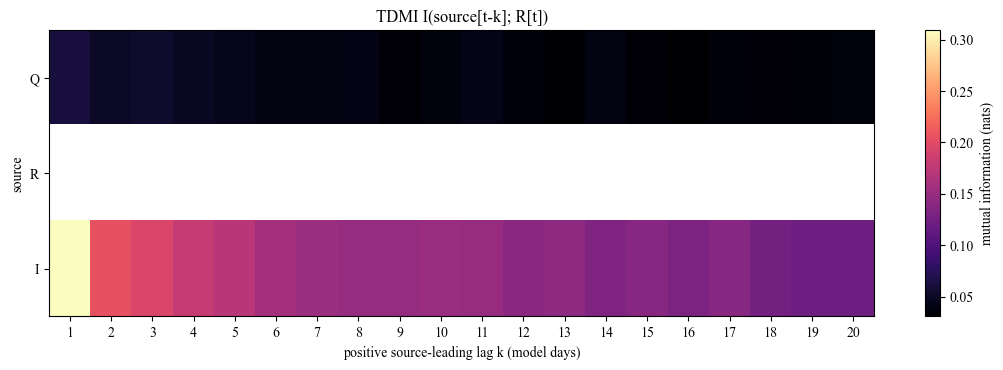

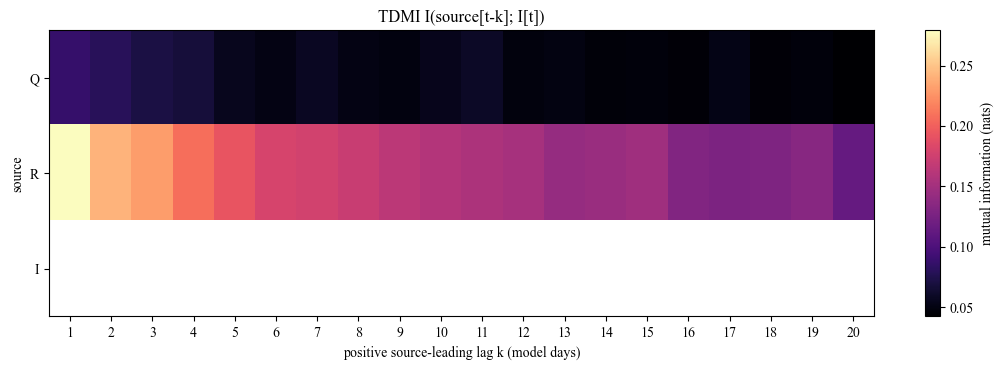

In [81]:
# TDMI direction is positive source-leading-target: I(X[t-k];Y[t]), k>=1. Its output remains a pairwise diagnostic.
assert norm_tdmi_curves.lag.between(1,MAX_LAG).all() and norm_tdmi_curves.source.ne(norm_tdmi_curves.target).all()
tdmi_source_target_lag_matrix=norm_tdmi_curves.rename(columns={'tdmi':'mutual_information','raw_p':'surrogate_p'}).copy()
tdmi_source_target_lag_matrix['source']=tdmi_source_target_lag_matrix.source.map(short); tdmi_source_target_lag_matrix['target']=tdmi_source_target_lag_matrix.target.map(short)
peak_lookup=norm_tdmi_summary.set_index('edge_id').training_tdmi_peak_lag.to_dict()
tdmi_source_target_lag_matrix['peak_flag']=tdmi_source_target_lag_matrix.apply(lambda r: bool(r.lag==peak_lookup.get(r.edge_id,np.nan)),axis=1)
tdmi_source_target_lag_matrix['lag_convention']='positive lag k = source at t-k, target at t'
def show_tdmi_heatmap(target):
    """Display pairwise TDMI over positive source-leading lags for one target."""
    d=tdmi_source_target_lag_matrix.loc[tdmi_source_target_lag_matrix.target.eq(target)].copy()
    if d.empty:
        available=tdmi_source_target_lag_matrix['target'].dropna().unique().tolist()
        raise ValueError(f'No TDMI lag diagnostics found for target={target!r}. Available targets: {available}')
    sources=['Q','R','I']; image=np.full((3,MAX_LAG),np.nan)
    for i,source in enumerate(sources):
        z=d[d.source.eq(source)].sort_values('lag'); image[i,z.lag.to_numpy(int)-1]=z.mutual_information
    fig,ax=plt.subplots(figsize=(11,3.8)); im=ax.imshow(np.ma.masked_invalid(image),aspect='auto',cmap='magma'); ax.set(yticks=range(3),yticklabels=sources,xticks=range(MAX_LAG),xticklabels=range(1,MAX_LAG+1),xlabel='positive source-leading lag k (model days)',ylabel='source',title=f'TDMI I(source[t-k]; {target}[t])')
    fig.colorbar(im,ax=ax,label='mutual information (nats)'); fig.tight_layout(); plt.show()
display(tdmi_source_target_lag_matrix)
show_tdmi_heatmap('R'); show_tdmi_heatmap('I')


## Part D7 — Synthetic GC implementation unit test

This small synthetic example tests the manual nested-F implementation only. It is never mixed with the empirical evidence, does not select a model, and does not modify the N16 result.


In [82]:
# Fast synthetic implementation test; it is never mixed with the empirical evidence.
rng=np.random.default_rng(RANDOM_SEED); T=1800; x=rng.normal(size=T); z=rng.normal(size=T); y=np.zeros(T)
for t in range(1,T): y[t]=.45*y[t-1]+.55*x[t-1]+rng.normal(scale=.7)
unit=pd.DataFrame({'y':y,'x':x,'z':z}); unit['y_lag1']=unit.y.shift(1); unit['x_lag1']=unit.x.shift(1); unit['z_lag1']=unit.z.shift(1); unit=unit.dropna(); yu=unit.y.to_numpy(); Xu=sm.add_constant(unit[['y_lag1','x_lag1','z_lag1']].to_numpy()); Xx=Xu[:,[0,1,3]]; Xz=Xu[:,[0,1,2]]; U=sm.OLS(yu,Xu).fit(); RX=sm.OLS(yu,Xx).fit(); RZ=sm.OLS(yu,Xz).fit(); F_x=((RX.ssr-U.ssr)/(1))/(U.ssr/U.df_resid); F_z=((RZ.ssr-U.ssr)/(1))/(U.ssr/U.df_resid); F_x_library=U.compare_f_test(RX)[0]; F_z_library=U.compare_f_test(RZ)[0]
synthetic_gc_unit_test=pd.DataFrame([{'label':'IMPLEMENTATION UNIT TEST ONLY: X block','F_manual':F_x,'F_library':F_x_library,'p_value':stats.f.sf(F_x,1,U.df_resid),'same_rows':len(unit)==len(yu)},{'label':'IMPLEMENTATION UNIT TEST ONLY: Z block','F_manual':F_z,'F_library':F_z_library,'p_value':stats.f.sf(F_z,1,U.df_resid),'same_rows':len(unit)==len(yu)}])
assert np.isclose(F_x,F_x_library,rtol=1e-10) and np.isclose(F_z,F_z_library,rtol=1e-10) and stats.f.sf(F_x,1,U.df_resid)<.001 and stats.f.sf(F_z,1,U.df_resid)>.05
display(synthetic_gc_unit_test)


,label,F_manual,F_library,p_value,same_rows
0,IMPLEMENTATION UNIT TEST ONLY: X block,1140.793182,1140.793182,5.235709e-194,True
1,IMPLEMENTATION UNIT TEST ONLY: Z block,0.008013,0.008013,9.286815e-01,True


## Part D8 — Final structure audit, exports, and N17 hand-off

The authoritative WEEKDAY_NORM primary structure passed to N17 is

$$
R_t=c+\beta_1R_{t-1}+\gamma_1I_{t-1}+\varepsilon_t^R.
$$

Q history is excluded because its incremental block effect is small in TRAIN and fails VALIDATION. The implied-variance equation is

$$
I_t=c+\sum_{j=1}^{12}[a_jI_{t-j}+b_jQ_{t-j}+g_jR_{t-j}]+\varepsilon_t^I.
$$

* I → R: RETAIN
* Q → R: DROP
* Q → I: RETAIN
* R → I: RETAIN

BIC selects history depth; conditional GC selects incremental linear source histories; TDMI supplies supporting pairwise nonlinear delayed-dependence evidence. These are Granger-predictive and dependence results, not structural economic causal claims. The primary-specification CSV remains the authoritative downstream N17 contract; RAW IV remains a benchmark.


In [83]:
final_rows=[]
for edge,source,target,p in norm_edge_specs:
    tr=PRIMARY_GC[(PRIMARY_GC.source.eq(source))&(PRIMARY_GC.target.eq(target))&(PRIMARY_GC.split.eq('train'))].iloc[0]; va=PRIMARY_GC[(PRIMARY_GC.source.eq(source))&(PRIMARY_GC.target.eq(target))&(PRIMARY_GC.split.eq('validation'))].iloc[0]; te=PRIMARY_GC[(PRIMARY_GC.source.eq(source))&(PRIMARY_GC.target.eq(target))&(PRIMARY_GC.split.eq('test'))].iloc[0]; td=norm_tdmi_summary[norm_tdmi_summary.edge_id.eq(edge)].iloc[0]; retain=bool(tr.holm_reject and va.holm_reject); reason='Retained: block GC survives Holm in both TRAIN and VALIDATION.' if retain else 'Dropped: Q history is contemporaneously related to R but fails the pre-specified Holm-corrected TRAIN/VALIDATION block-GC retention rule.' if edge=='squared_return_to_realised_variance' else 'Dropped: block GC fails the pre-specified Holm-corrected TRAIN/VALIDATION retention rule.'
    final_rows.append({'source':short[source],'target':short[target],'selected_order':p,'F_train':tr.F_manual,'p_train':tr.p_value,'p_holm_train':tr.holm_adjusted_p_value,'partial_R2_train':tr.partial_R2,'F_validation':va.F_manual,'p_validation':va.p_value,'p_holm_validation':va.holm_adjusted_p_value,'partial_R2_validation':va.partial_R2,'F_test_NOT_USED_FOR_SELECTION':te.F_manual,'p_test_NOT_USED_FOR_SELECTION':te.p_value,'HAC_train':tr.HAC_p,'HAC_validation':va.HAC_p,'TDMI_peak_train':td.training_tdmi_peak_lag,'TDMI_support':bool(td.training_tdmi_support),'final_retain':retain,'reason':reason})
final_predictive_structure_audit=pd.DataFrame(final_rows)
expected=(weekday_norm_n==1 and weekday_norm_m==12 and Q_TO_R_DECISION=='DROP' and bool(final_predictive_structure_audit.query("source=='I' and target=='R'").final_retain.iloc[0]) and bool(final_predictive_structure_audit.query("source=='Q' and target=='I'").final_retain.iloc[0]) and bool(final_predictive_structure_audit.query("source=='R' and target=='I'").final_retain.iloc[0]))
STRUCTURE_CHANGED=not expected; DOWNSTREAM_STATUS='NO DOWNSTREAM RECOMPUTATION REQUIRED DUE TO N16 STRUCTURE CHANGE' if not STRUCTURE_CHANGED else 'N16 STRUCTURE CHANGE REQUIRES DOWNSTREAM RECOMPUTATION.'
audit_exports={'16_gc_large_f_audit.csv':gc_large_f_audit,'16_gc_model_comparisons.csv':gc_model_comparisons,'16_q_to_r_sanity_audit.csv':q_to_r_sanity_audit,'16_gc_predictive_matrix.csv':gc_predictive_matrix,'16_gc_source_target_lag_diagnostics.csv':gc_source_target_lag_diagnostics,'16_tdmi_source_target_lag_matrix.csv':tdmi_source_target_lag_matrix,'16_final_predictive_structure_audit.csv':final_predictive_structure_audit}
for name,frame in audit_exports.items(): out=frame.copy(); out.insert(0,'RUN_ID',RUN_ID); out.to_csv(PROCESSED_DIR/name,index=False); assert len(pd.read_csv(PROCESSED_DIR/name))==len(out)
large_primary=gc_large_f_audit[gc_large_f_audit.iv_specification.eq(PRIMARY_IV_SPECIFICATION)].sort_values('classical_F',ascending=False).iloc[0]
print('N16 METHODOLOGICAL AUDIT\n---------------------------------------------')
print('Manual F-test implementation verified: YES')
print('Restricted/unrestricted same rows: YES')
print(f"Large-F source/target: {large_primary.source_label} -> {large_primary.target_label} ({large_primary.split})")
print(f"Large-F value: {large_primary.F_manual:.6f}; partial R2: {large_primary.partial_R2:.6f}; status: {large_primary.large_F_status}")
print(f"Extreme-p reporting corrected: YES; Final n: {weekday_norm_n}; Final m: {weekday_norm_m}; Q -> R decision: {Q_TO_R_DECISION}")
print('I -> R decision: '+('RETAIN' if bool(final_predictive_structure_audit.query("source=='I' and target=='R'").final_retain.iloc[0]) else 'DROP'))
print('Q -> I decision: '+('RETAIN' if bool(final_predictive_structure_audit.query("source=='Q' and target=='I'").final_retain.iloc[0]) else 'DROP'))
print('R -> I decision: '+('RETAIN' if bool(final_predictive_structure_audit.query("source=='R' and target=='I'").final_retain.iloc[0]) else 'DROP'))
print('GC predictive matrix created: YES; GC lag diagnostics created: YES; TDMI direction audit: PASS; TDMI lag outputs created: YES')
print(f'Test used for selection: NO; Structure changed: {STRUCTURE_CHANGED}; N16 audit requires downstream recomputation: {STRUCTURE_CHANGED}')
display(final_predictive_structure_audit); display(q_to_r_sanity_audit); display(synthetic_gc_unit_test)


N16 METHODOLOGICAL AUDIT
---------------------------------------------
Manual F-test implementation verified: YES
Restricted/unrestricted same rows: YES
Large-F source/target: I -> R (train)
Large-F value: 618.180823; partial R2: 0.170807; status: VALID_LARGE_INCREMENTAL_EFFECT
Extreme-p reporting corrected: YES; Final n: 1; Final m: 12; Q -> R decision: DROP
I -> R decision: RETAIN
Q -> I decision: RETAIN
R -> I decision: RETAIN
GC predictive matrix created: YES; GC lag diagnostics created: YES; TDMI direction audit: PASS; TDMI lag outputs created: YES
Test used for selection: NO; Structure changed: False; N16 audit requires downstream recomputation: False


,source,target,selected_order,F_train,p_train,p_holm_train,partial_R2_train,F_validation,p_validation,p_holm_validation,partial_R2_validation,F_test_NOT_USED_FOR_SELECTION,p_test_NOT_USED_FOR_SELECTION,HAC_train,HAC_validation,TDMI_peak_train,TDMI_support,final_retain,reason
0,Q,R,1,9.910784,1.659261e-03,1.659261e-03,0.003292,3.052035,8.089687e-02,8.089687e-02,0.002586,4.414376,3.584934e-02,6.149383e-02,0.566117,1,True,False,Dropped: Q history is contemporaneously relate...
1,I,R,1,618.180823,3.084728e-124,1.233891e-123,0.170807,228.828260,2.252186e-47,9.008744e-47,0.162771,295.919561,2.437757e-59,8.805200e-12,0.000011,1,True,True,Retained: block GC survives Holm in both TRAIN...
2,Q,I,12,6.634762,8.393768e-12,2.518130e-11,0.035095,3.262608,1.214668e-04,2.429336e-04,0.035947,2.508260,2.979883e-03,7.039994e-01,0.000037,1,True,True,Retained: block GC survives Holm in both TRAIN...
3,R,I,12,6.495228,1.704622e-11,3.409244e-11,0.034382,3.857836,8.400528e-06,2.520158e-05,0.042228,0.597650,8.453867e-01,8.496388e-01,0.003196,1,True,True,Retained: block GC survives Holm in both TRAIN...


,split,pearson_Qt_Rt,spearman_Qt_Rt,pearson_Qtminus1_Rt,gc_F,gc_p_value,gc_holm_p_value,gc_partial_R2,gc_hac_p,gc_retain,Q_block_coefficients
0,train,0.625023,0.534407,0.289822,9.910784,0.001659,0.001659,0.003292,0.061494,False,squared_return_lag1=11.452431 (p=0.001659)
1,validation,0.568650,0.441412,0.388195,3.052035,0.080897,0.080897,0.002586,0.566117,False,squared_return_lag1=7.1937857 (p=0.0809)


,label,F_manual,F_library,p_value,same_rows
0,IMPLEMENTATION UNIT TEST ONLY: X block,1140.793182,1140.793182,5.235709e-194,True
1,IMPLEMENTATION UNIT TEST ONLY: Z block,0.008013,0.008013,9.286815e-01,True


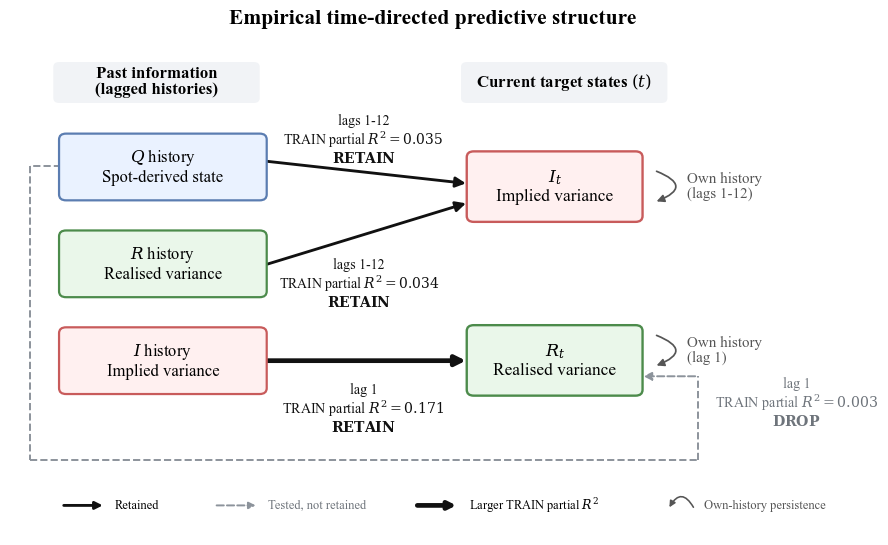

THESIS FIGURE 5.1 EXPORTED
PDF: c:\Users\Rajiv Nawal\OneDrive\Documents\GITREPOS\HSBC-AN-RN\CODEWORK\Linus' Task Re-Do\plots\empirical_work\fig_5_1_empirical_predictive_structure.pdf
PNG: c:\Users\Rajiv Nawal\OneDrive\Documents\GITREPOS\HSBC-AN-RN\CODEWORK\Linus' Task Re-Do\plots\empirical_work\fig_5_1_empirical_predictive_structure.png
Scientific calculations changed: NO


In [2]:
# ============================================================
# THESIS FIGURE 5.1
# Empirical time-directed predictive structure
#
# Plotting/export only.
# No models are fitted and no statistical results are changed.
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


# ------------------------------------------------------------
# Project / export directory
# ------------------------------------------------------------

PROJECT_ROOT = (
    Path(PROJECT_DIR)
    if "PROJECT_DIR" in globals()
    else Path.cwd()
)

THESIS_PLOTS = PROJECT_ROOT / "plots" / "empirical_work"
THESIS_PLOTS.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Audited N16 cross-state results
#
# R target:
#   I -> R retained
#   Q -> R dropped
#   selected history order p = 1
#
# I target:
#   Q -> I retained
#   R -> I retained
#   selected history order p = 12
#
# Values shown on arrows are TRAIN partial R^2.
# ------------------------------------------------------------

R2_I_to_R = 0.1710
R2_Q_to_R = 0.0033
R2_Q_to_I = 0.0351
R2_R_to_I = 0.0344


# ------------------------------------------------------------
# Thesis-style typography
# ------------------------------------------------------------

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "axes.unicode_minus": False,
})


# ------------------------------------------------------------
# Figure setup
#
# Compact canvas + horizontal legend.
# The PDF export remains vector-sharp in LaTeX.
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8.8, 5.5))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.set_xlim(0, 13.4)
ax.set_ylim(0, 9.2)

ax.axis("off")

fig.suptitle(
    "Empirical time-directed predictive structure",
    fontsize=15.5,
    fontweight="bold",
    y=0.975
)


# ------------------------------------------------------------
# Colour palette
# ------------------------------------------------------------

Q_FILL = "#EAF2FF"
Q_EDGE = "#5B7DB1"

R_FILL = "#EAF7EA"
R_EDGE = "#4C8B4B"

I_FILL = "#FFF0F0"
I_EDGE = "#C85B5B"

HEADER_FILL = "#F1F3F6"

RETAINED = "#111111"
DROPPED = "#8C939B"
PERSISTENCE = "#555555"


# ------------------------------------------------------------
# Helper: rounded state box
# ------------------------------------------------------------

def add_box(
    x,
    y,
    w,
    h,
    text,
    facecolor,
    edgecolor,
    fontsize=12.0,
    linewidth=1.6
):
    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.03,rounding_size=0.11",
        facecolor=facecolor,
        edgecolor=edgecolor,
        linewidth=linewidth,
        zorder=4
    )

    ax.add_patch(patch)

    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        linespacing=1.15,
        zorder=5
    )


# ------------------------------------------------------------
# Helper: section heading
# ------------------------------------------------------------

def add_header(
    x,
    y,
    w,
    h,
    text
):
    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.02,rounding_size=0.09",
        facecolor=HEADER_FILL,
        edgecolor="none",
        zorder=1
    )

    ax.add_patch(patch)

    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=12.2,
        fontweight="bold",
        linespacing=1.05,
        zorder=2
    )


# ------------------------------------------------------------
# Helper: directed edge
# ------------------------------------------------------------

def draw_arrow(
    start,
    end,
    color=RETAINED,
    linewidth=2.0,
    linestyle="-",
    mutation_scale=15,
    zorder=2,
    rad=0.0
):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=mutation_scale,
        linewidth=linewidth,
        linestyle=linestyle,
        color=color,
        connectionstyle=f"arc3,rad={rad}",
        shrinkA=2,
        shrinkB=2,
        zorder=zorder
    )

    ax.add_patch(arrow)


# ------------------------------------------------------------
# Helper: relationship annotation
# ------------------------------------------------------------

def add_relationship_label(
    x,
    y,
    lag_text,
    r2_value,
    decision,
    color="#111111",
    fontsize=10.0
):
    decision_tex = (
        r"$\mathbf{RETAIN}$"
        if decision == "RETAIN"
        else r"$\mathbf{DROP}$"
    )

    ax.text(
        x,
        y,
        (
            f"{lag_text}\n"
            rf"TRAIN partial $R^2={r2_value:.3f}$"
            "\n"
            f"{decision_tex}"
        ),
        ha="center",
        va="center",
        fontsize=fontsize,
        color=color,
        linespacing=1.10,
        zorder=6
    )


# ============================================================
# HEADINGS
# ============================================================

add_header(
    0.70,
    8.05,
    3.20,
    0.72,
    "Past information\n(lagged histories)"
)

add_header(
    7.10,
    8.05,
    3.20,
    0.72,
    r"Current target states $(t)$"
)


# ============================================================
# PAST INFORMATION
# ============================================================

add_box(
    0.80,
    6.25,
    3.20,
    1.18,
    (
        r"$Q$ history"
        "\nSpot-derived state"
    ),
    Q_FILL,
    Q_EDGE
)

add_box(
    0.80,
    4.45,
    3.20,
    1.18,
    (
        r"$R$ history"
        "\nRealised variance"
    ),
    R_FILL,
    R_EDGE
)

add_box(
    0.80,
    2.65,
    3.20,
    1.18,
    (
        r"$I$ history"
        "\nImplied variance"
    ),
    I_FILL,
    I_EDGE
)


# ============================================================
# CURRENT TARGET STATES
# ============================================================

add_box(
    7.20,
    5.85,
    2.70,
    1.25,
    (
        r"$I_t$"
        "\nImplied variance"
    ),
    I_FILL,
    I_EDGE,
    fontsize=12.5,
    linewidth=1.7
)

add_box(
    7.20,
    2.62,
    2.70,
    1.25,
    (
        r"$R_t$"
        "\nRealised variance"
    ),
    R_FILL,
    R_EDGE,
    fontsize=12.5,
    linewidth=1.7
)


# ============================================================
# RETAINED CROSS-STATE RELATIONSHIPS
# ============================================================

# ------------------------------------------------------------
# Q -> I
# ------------------------------------------------------------

draw_arrow(
    start=(4.00, 6.95),
    end=(7.20, 6.53),
    linewidth=2.05,
    zorder=3
)

add_relationship_label(
    5.55,
    7.35,
    "lags 1-12",
    R2_Q_to_I,
    "RETAIN",
    fontsize=10.0
)


# ------------------------------------------------------------
# R -> I
# ------------------------------------------------------------

draw_arrow(
    start=(4.00, 5.02),
    end=(7.20, 6.18),
    linewidth=2.05,
    zorder=3
)

add_relationship_label(
    5.48,
    4.67,
    "lags 1-12",
    R2_R_to_I,
    "RETAIN",
    fontsize=10.0
)


# ------------------------------------------------------------
# I -> R
#
# Dominant retained cross-state relationship.
# ------------------------------------------------------------

draw_arrow(
    start=(4.00, 3.24),
    end=(7.20, 3.24),
    linewidth=3.4,
    zorder=3
)

add_relationship_label(
    5.55,
    2.35,
    "lag 1",
    R2_I_to_R,
    "RETAIN",
    fontsize=10.2
)


# ============================================================
# DROPPED Q -> R RELATIONSHIP
#
# Routed around the outside of the retained network.
# ============================================================

# Leave Q-history box from the left
ax.plot(
    [0.80, 0.32],
    [6.85, 6.85],
    linestyle="--",
    linewidth=1.40,
    color=DROPPED,
    zorder=1
)

# Down the outside left edge
ax.plot(
    [0.32, 0.32],
    [6.85, 1.40],
    linestyle="--",
    linewidth=1.40,
    color=DROPPED,
    zorder=1
)

# Across underneath the predictive network
ax.plot(
    [0.32, 10.80],
    [1.40, 1.40],
    linestyle="--",
    linewidth=1.40,
    color=DROPPED,
    zorder=1
)

# Up on the right
ax.plot(
    [10.80, 10.80],
    [1.40, 2.95],
    linestyle="--",
    linewidth=1.40,
    color=DROPPED,
    zorder=1
)

# Enter R_t from the right
draw_arrow(
    start=(10.80, 2.95),
    end=(9.90, 2.95),
    color=DROPPED,
    linewidth=1.40,
    linestyle="--",
    mutation_scale=12,
    zorder=2
)


# Dropped relationship label:
# clearly to the RIGHT of the vertical dashed line
add_relationship_label(
    12.35,
    2.45,
    "lag 1",
    R2_Q_to_R,
    "DROP",
    color="#6E747B",
    fontsize=10.2
)


# ============================================================
# OWN-HISTORY PERSISTENCE
# ============================================================

def add_side_loop(
    x,
    y,
    label
):
    loop = FancyArrowPatch(
        (x, y + 0.28),
        (x, y - 0.28),
        arrowstyle="-|>",
        mutation_scale=11,
        linewidth=1.25,
        color=PERSISTENCE,
        connectionstyle="arc3,rad=-1.25",
        shrinkA=0,
        shrinkB=0,
        zorder=2
    )

    ax.add_patch(loop)

    ax.text(
        x + 0.47,
        y,
        label,
        ha="left",
        va="center",
        fontsize=10.8,
        color=PERSISTENCE,
        linespacing=1.02,
        zorder=3
    )


# I own history
add_side_loop(
    10.15,
    6.48,
    "Own history\n(lags 1-12)"
)

# R own history
add_side_loop(
    10.15,
    3.43,
    "Own history\n(lag 1)"
)


# ============================================================
# HORIZONTAL LEGEND
#
# The legend is deliberately shallow and runs across the
# bottom so that it does not shrink the predictive network.
# ============================================================

legend_y = 0.55


# ------------------------------------------------------------
# 1. Retained relationship
# ------------------------------------------------------------

draw_arrow(
    start=(0.80, legend_y),
    end=(1.50, legend_y),
    linewidth=2.05,
    mutation_scale=11,
    zorder=3
)

ax.text(
    1.65,
    legend_y,
    "Retained",
    ha="left",
    va="center",
    fontsize=9.0
)


# ------------------------------------------------------------
# 2. Tested but not retained
# ------------------------------------------------------------

draw_arrow(
    start=(3.20, legend_y),
    end=(3.90, legend_y),
    color=DROPPED,
    linewidth=1.40,
    linestyle="--",
    mutation_scale=10,
    zorder=3
)

ax.text(
    4.05,
    legend_y,
    "Tested, not retained",
    ha="left",
    va="center",
    fontsize=9.0,
    color="#6E747B"
)


# ------------------------------------------------------------
# 3. Larger TRAIN partial R^2
# ------------------------------------------------------------

draw_arrow(
    start=(6.35, legend_y),
    end=(7.05, legend_y),
    linewidth=3.4,
    mutation_scale=11,
    zorder=3
)

ax.text(
    7.20,
    legend_y,
    r"Larger TRAIN partial $R^2$",
    ha="left",
    va="center",
    fontsize=9.0
)


# ------------------------------------------------------------
# 4. Own-history persistence
# ------------------------------------------------------------

legend_loop = FancyArrowPatch(
    (10.75, legend_y - 0.08),
    (10.33, legend_y - 0.08),
    arrowstyle="-|>",
    mutation_scale=9,
    linewidth=1.15,
    color=PERSISTENCE,
    connectionstyle="arc3,rad=0.95",
    zorder=3
)

ax.add_patch(legend_loop)

ax.text(
    10.90,
    legend_y,
    "Own-history persistence",
    ha="left",
    va="center",
    fontsize=9.0,
    color=PERSISTENCE
)


# ============================================================
# FINAL LAYOUT
# ============================================================

fig.subplots_adjust(
    left=0.02,
    right=0.99,
    top=0.92,
    bottom=0.02
)


# ============================================================
# EXPORT
#
# PDF = thesis version, fully vector.
# PNG = high-resolution preview / backup.
# ============================================================

pdf_path = (
    THESIS_PLOTS /
    "fig_5_1_empirical_predictive_structure.pdf"
)

png_path = (
    THESIS_PLOTS /
    "fig_5_1_empirical_predictive_structure.png"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    pad_inches=0.05
)

fig.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.show()

print("THESIS FIGURE 5.1 EXPORTED")
print("PDF:", pdf_path)
print("PNG:", png_path)
print("Scientific calculations changed: NO")